# Predicción de la calificación de reseñas en español con un encoder Transformer

## 1. El problema

Dado el texto de una reseña en español, predecimos cuántas estrellas le corresponden, de 1 a 5. Sirve para detectar reseñas cuyo texto y nota no coinciden, ordenar opiniones sin calificar y resumir la valoración de un producto.

**Las cinco clases tienen orden.** Confundir 4 con 5 estrellas es un error leve; confundir 1 con 5 no lo es. Accuracy y F1 tratan ambos casos igual, así que condicionan las métricas que elegimos y la forma de leer la matriz de confusión.

**Dos formas de mirar una secuencia.** Una red recurrente lee palabra por palabra y arrastra un estado; conectar una negación con el adjetivo que niega exige que la información sobreviva a todos los pasos intermedios. La atención compara todas las posiciones a la vez, sin importar la distancia, pero pierde el orden y hay que inyectarlo con una codificación posicional.

### Pregunta de investigación

> ¿Cuánto aporta la **atención** frente al resto de piezas del bloque codificador —red densa por posición, residuales, codificación posicional, forma de resumir la secuencia— y frente al volumen de datos?

Responderla exige un diseño concreto: comparar el Transformer contra un modelo sin bloques no aísla la atención, porque al quitar los bloques desaparecen todas sus piezas a la vez. Hace falta una escalera de controles que active una capacidad cada vez.

### Hipótesis

1. La atención será la pieza que más aporte dentro del bloque codificador.
2. El Transformer será el que más gane al aumentar el corpus, por carecer de los sesgos inductivos de la recurrencia.
3. Las clases intermedias (2, 3 y 4 estrellas) serán más difíciles que los extremos.


---
## 2. Objetivos y alcance

**Objetivo general.** Implementar el codificador del Transformer pieza por pieza, aplicarlo a la clasificación ordinal de reseñas en español y medir cuánto aporta cada una de sus partes.

**Objetivos específicos**

1. Explorar el corpus y caracterizar el vocabulario de cada calificación.
2. Entrenar un tokenizador subword sobre el corpus y contrastarlo con palabras enteras.
3. Establecer referencias sin atención: un modelo lineal sobre TF-IDF y dos perceptrones multicapa.
4. Implementar desde cero la codificación posicional, la atención multi-cabeza y el bloque codificador, documentando dónde nos apartamos del artículo original.
5. Comparar el Transformer con una red recurrente sobre los mismos identificadores.
6. Aislar el aporte de la atención con una escalera de controles.
7. Medir el efecto de las residuales, la codificación posicional, la forma de resumir y tres programaciones del ritmo de aprendizaje.
8. Entrenar con una pérdida sensible a la distancia entre clases.
9. Medir el efecto de cuadruplicar el corpus.
10. Inspeccionar los mapas de atención y analizar los errores del modelo final.

**Alcance.** Clasificación multiclase de etiqueta única sobre cinco niveles ordenados, con todos los modelos entrenados desde cero y sin pesos preentrenados. Comparten vocabulario, corte de longitud, optimizador, ritmo de aprendizaje, recorte de gradiente, criterio de parada, semilla y orden de los lotes.

**Salvedad sobre el dropout.** Todos usan el mismo valor, 0,1, pero **no el mismo número de puntos de aplicación**: diez en el Transformer —embeddings, pesos de atención, las dos subcapas de cada bloque y el resumen—, dos en el perceptrón de promedio y uno en la GRU. Es la receta del artículo, así que al comparar el Transformer con la recurrencia no solo cambia la arquitectura, también cuánta regularización recibe. Los controles de la escalera comparten los mismos puntos de aplicación, pero compartir el módulo no equivale a recibir el mismo efecto.

**Límite principal.** Cada cifra proviene de una única ejecución. Las diferencias del orden del margen de error muestral no deben interpretarse como reales.


---
## 3. Entorno y reproducibilidad

Fijamos una semilla global y también el generador del `DataLoader`. Sin esto el barajado de los lotes cambia entre ejecuciones aunque las semillas globales estén fijadas.

Como vamos a comparar muchas arquitecturas entre sí, fijamos además un único ritmo de aprendizaje y un único recorte de gradiente para todas: lo único que debe cambiar entre experimentos es lo que queremos medir.

Pedimos también que las operaciones de álgebra lineal de la GPU sean deterministas, configurando el espacio de trabajo de cuBLAS antes de que se inicialice CUDA. Aun así queda variabilidad residual: la precisión mixta y algunas operaciones sin versión determinista impiden garantizar una reproducción bit a bit entre máquinas distintas.


In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules
print('Ejecutando en Colab:', IN_COLAB)

Ejecutando en Colab: True


In [2]:
if IN_COLAB:
    !pip install -q lightning torchmetrics gradio datasets transformers tokenizers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 62.3 MB/s eta 0:00:00


In [3]:
import json
import math
import os
import random
import re
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import transformers
from torch.utils.data import DataLoader, Dataset

try:
    import lightning.pytorch as pl
    from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
    from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
except ImportError:
    import pytorch_lightning as pl
    from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
    from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# Debe fijarse antes de inicializar CUDA: sin esto las reducciones de cuBLAS no son deterministas.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

try:
    import tensorboard  # noqa: F401
    HAY_TENSORBOARD = True
except ImportError:
    HAY_TENSORBOARD = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
pl.seed_everything(SEED, workers=True)

# El generador del DataLoader tambien debe fijarse para que el barajado sea reproducible.
GENERADOR = torch.Generator().manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EN_GPU = torch.cuda.is_available()
PRECISION = '16-mixed' if EN_GPU else '32-true'

# Receta de optimización común a todos los modelos neuronales del cuaderno.
LR = 3e-4
RECORTE_GRADIENTE = 1.0
PROPORCION_CALENTAMIENTO = 0.1
DROPOUT = 0.1
DIM_MODELO = 128

print('Dispositivo:', DEVICE)
print('PyTorch:', torch.__version__)
print('Lightning:', pl.__version__)
print('torchmetrics:', torchmetrics.__version__)
print('transformers:', transformers.__version__)
print('Precisión de entrenamiento:', PRECISION)
print('TensorBoard disponible:', HAY_TENSORBOARD)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Dispositivo: cuda
PyTorch: 2.11.0+cu128
Lightning: 2.6.6
torchmetrics: 1.9.0
transformers: 5.16.1
Precisión de entrenamiento: 16-mixed
TensorBoard disponible: True


---
## 4. Carga del corpus

Usamos un corpus de reseñas de productos en español del Hub de Hugging Face, con particiones oficiales de entrenamiento, validación y prueba. Las etiquetas vienen codificadas de 0 a 4 y las convertimos a estrellas de 1 a 5, para que el error absoluto medio se lea como *número de estrellas de desviación*.

In [4]:
from datasets import load_dataset

corpus = load_dataset('SetFit/amazon_reviews_multi_es')
print(corpus)

README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: reconstructing file:   0%|          |  0.00B / 43.8MB            

train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [5]:
CRUDOS = {nombre: corpus[nombre].to_pandas()[['text', 'label']].copy()
          for nombre in ('train', 'validation', 'test')}

for nombre, df in CRUDOS.items():
    print(f'{nombre:11s} {len(df):>6} reseñas')

print('\nPrimeras reseñas de entrenamiento:')
for _, fila in CRUDOS['train'].head(3).iterrows():
    print(f"  {fila['label'] + 1} estrellas | {fila['text'][:78]}")

train       200000 reseñas
validation    5000 reseñas
test          5000 reseñas

Primeras reseñas de entrenamiento:
  1 estrellas | Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuest
  1 estrellas | Horrible, nos tuvimos que comprar otro porque ni nosotros que sabemos inglés, 
  1 estrellas | Te obligan a comprar dos unidades y te llega solo una y no hay forma de reclam


---
## 5. Auditoría de integridad del corpus

Un problema de integridad no produce ningún error: el cuaderno se ejecuta igual y las métricas incluso salen mejores, pero contamina todo lo que venga después.

### 5.1 Reseñas repetidas y calificaciones ambiguas

Buscamos tres cosas, en orden de gravedad creciente:

1. **Reseñas repetidas dentro de una partición**, que pesarían como opiniones independientes.
2. **Reseñas presentes en más de una partición**, que convertirían parte de la evaluación en una medida de memorización.
3. **Textos idénticos con calificaciones distintas**, que marcan un techo a lo que cualquier modelo puede aprender.


In [6]:
auditoria = []
for nombre, df in CRUDOS.items():
    textos = df['text'].astype(str).str.strip()
    repetidas = int(textos.duplicated().sum())
    auditoria.append({
        'partición': nombre,
        'reseñas': len(df),
        'nulas': int(df['text'].isna().sum()),
        'vacías': int((textos == '').sum()),
        'repetidas': repetidas,
        '% repetidas': round(100 * repetidas / len(df), 2),
    })

print(pd.DataFrame(auditoria).to_string(index=False))

conteo_textos = CRUDOS['train']['text'].value_counts()
print('\nReseñas más repetidas en entrenamiento:')
for texto, veces in conteo_textos.head(5).items():
    notas = sorted({int(e) + 1 for e in CRUDOS['train'].loc[CRUDOS['train']['text'] == texto, 'label']})
    print(f'  {veces:>4} veces | calificaciones observadas: {notas} | "{texto[:58]}"')

calificaciones_por_texto = CRUDOS['train'].groupby('text')['label'].nunique()
ambiguos = calificaciones_por_texto[calificaciones_por_texto > 1]
afectadas = int(CRUDOS['train']['text'].isin(ambiguos.index).sum())

print(f'\nTextos idénticos que aparecen con más de una calificación: {len(ambiguos)}')
print(f'Reseñas afectadas por esa ambigüedad: {afectadas} '
      f'({100 * afectadas / len(CRUDOS["train"]):.2f}% del entrenamiento)')

 partición  reseñas  nulas  vacías  repetidas  % repetidas
     train   200000      0       0       1736         0.87
validation     5000      0       0          5         0.10
      test     5000      0       0          6         0.12

Reseñas más repetidas en entrenamiento:
   106 veces | calificaciones observadas: [2, 3, 4, 5] | "Buena relación calidad precio"
    56 veces | calificaciones observadas: [3, 4, 5] | "Buena calidad precio"
    43 veces | calificaciones observadas: [1, 2, 3] | "No es lo que esperaba"
    27 veces | calificaciones observadas: [2, 3, 4, 5] | "Cumple las expectativas"
    24 veces | calificaciones observadas: [3, 4, 5] | "Buena relación calidad-precio"

Textos idénticos que aparecen con más de una calificación: 398
Reseñas afectadas por esa ambigüedad: 1654 (0.83% del entrenamiento)


### 5.2 ¿Están las particiones realmente separadas?

La tabla anterior mira cada partición por separado. Falta la comprobación que condiciona la validez del experimento: si un mismo texto aparece en dos particiones distintas.

Añadimos una segunda pregunta: cuando una reseña aparece en entrenamiento y en prueba, **¿lleva la misma calificación en las dos?**

Reseñas que aparecen en dos particiones a la vez:
  train ∩ validation       66
  train ∩ test             57
  validation ∩ test        9

Ejemplos presentes a la vez en entrenamiento y en prueba:
  entrenamiento=[4, 5]  prueba=[4]  |  "A mi hija le ha encantado"
  entrenamiento=[1, 4]  prueba=[2]  |  "Amazon, maquinaria sorda, envia tus productos a tiempo "
  entrenamiento=[1]  prueba=[1]  |  "Aun no lo he recibido"
  entrenamiento=[1]  prueba=[1]  |  "Aun no lo he recibido."
  entrenamiento=[1]  prueba=[1]  |  "Aun no me ha llegado"

De las 57 reseñas compartidas entre entrenamiento y prueba, 17 llevan la misma calificación y 40 llevan una distinta.


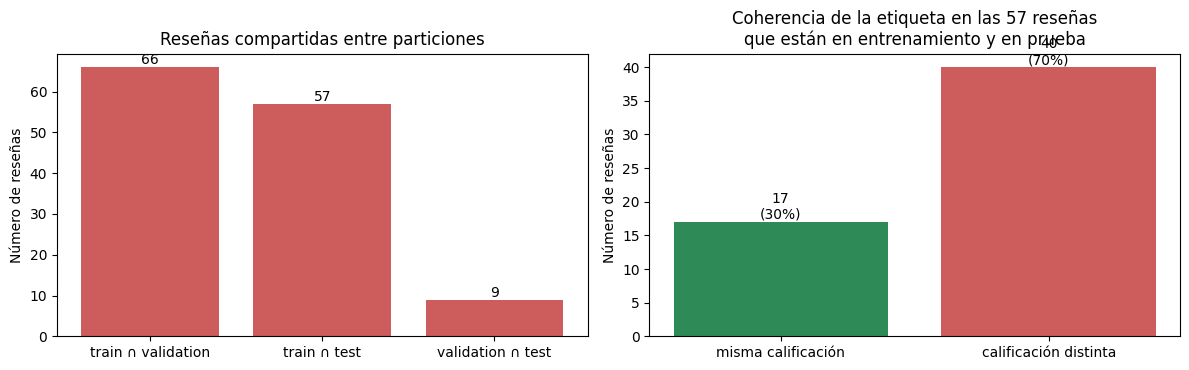

In [7]:
conjuntos = {nombre: set(df['text']) for nombre, df in CRUDOS.items()}
pares = [('train', 'validation'), ('train', 'test'), ('validation', 'test')]
solapamientos = {f'{a} ∩ {b}': len(conjuntos[a] & conjuntos[b]) for a, b in pares}

print('Reseñas que aparecen en dos particiones a la vez:')
for etiqueta, cuantas in solapamientos.items():
    print(f'  {etiqueta:24s} {cuantas}')

notas_train = CRUDOS['train'].groupby('text')['label'].agg(set)
notas_test = CRUDOS['test'].groupby('text')['label'].agg(set)
compartidos = sorted(set(notas_train.index) & set(notas_test.index))

print('\nEjemplos presentes a la vez en entrenamiento y en prueba:')
for texto in compartidos[:5]:
    en_train = sorted(int(e) + 1 for e in notas_train[texto])
    en_prueba = sorted(int(e) + 1 for e in notas_test[texto])
    print(f'  entrenamiento={en_train}  prueba={en_prueba}  |  "{texto[:55]}"')

misma_nota = sum(1 for t in compartidos if notas_train[t] == notas_test[t])
distinta_nota = len(compartidos) - misma_nota
print(f'\nDe las {len(compartidos)} reseñas compartidas entre entrenamiento y prueba, '
      f'{misma_nota} llevan la misma calificación y {distinta_nota} llevan una distinta.')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].bar(list(solapamientos), list(solapamientos.values()), color='indianred')
axes[0].set_title('Reseñas compartidas entre particiones')
axes[0].set_ylabel('Número de reseñas')
for i, valor in enumerate(solapamientos.values()):
    axes[0].text(i, valor, str(valor), ha='center', va='bottom')

axes[1].bar(['misma calificación', 'calificación distinta'], [misma_nota, distinta_nota],
            color=['seagreen', 'indianred'])
axes[1].set_title(f'Coherencia de la etiqueta en las {len(compartidos)} reseñas\n'
                  'que están en entrenamiento y en prueba')
axes[1].set_ylabel('Número de reseñas')
for i, valor in enumerate([misma_nota, distinta_nota]):
    axes[1].text(i, valor, f'{valor}\n({valor / len(compartidos):.0%})', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Qué implican estos hallazgos

Los tres problemas afectan a menos del 1% de las reseñas, pero cada uno exige una respuesta distinta.

**Reseñas repetidas: el 0,87% del entrenamiento.** *"Buena relación calidad precio"* aparece 106 veces. Basta con quedarnos con una copia de cada texto.

**Reseñas compartidas entre particiones: 66 y 57.** El modelo las habría visto con su etiqueta antes de ser evaluado con ellas. Las eliminamos del entrenamiento.

**Calificaciones ambiguas: 398 textos con más de una nota, que afectan a 1.654 reseñas.** De las 57 presentes a la vez en entrenamiento y prueba, **40 llevan notas distintas**. *"No es lo que esperaba"* aparece con una, dos o tres estrellas. Es decir, **la etiqueta no es una función del texto**: hay un techo de desempeño que no depende de la arquitectura y que no podemos corregir.

Depuramos **antes** del muestreo: si muestreáramos primero y elimináramos después, las clases dejarían de estar balanceadas.


### 5.3 Depuración y muestreo

Aplicamos las dos decisiones que se derivan de la auditoría: eliminamos los textos repetidos dentro de cada partición y descartamos del entrenamiento las reseñas que reaparecen en validación o en prueba. El muestreo balanceado de diez mil reseñas por clase se hace al final, sobre el material ya depurado.

Sobre las calificaciones ambiguas no actuamos: no podemos decidir cuál de las dos notas es la correcta.

In [8]:
N_POR_CLASE = 10_000
COLUMNAS = ['text', 'label', 'estrellas']


def limpiar(df):
    df = df.copy()
    df['text'] = df['text'].astype(str).str.strip()
    return df[df['text'] != ''].drop_duplicates(subset='text')


def preparar(df, n_por_clase=None, excluir=None):
    if excluir is not None:
        df = df[~df['text'].isin(excluir)]
    if n_por_clase is not None:
        df = (df.groupby('label', group_keys=False)
                .apply(lambda g: g.sample(n_por_clase, random_state=SEED)))
    df = df.copy()
    df['estrellas'] = df['label'] + 1
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)[COLUMNAS]


sin_repetir = {nombre: limpiar(df) for nombre, df in CRUDOS.items()}
reservados = set(sin_repetir['validation']['text']) | set(sin_repetir['test']['text'])
descartadas = int(sin_repetir['train']['text'].isin(reservados).sum())

val_df = preparar(sin_repetir['validation'])
test_df = preparar(sin_repetir['test'])
train_df = preparar(sin_repetir['train'], N_POR_CLASE, excluir=reservados)

CLASES = sorted(int(c) for c in train_df['estrellas'].unique())
NUM_CLASES = len(CLASES)

resumen_depuracion = pd.DataFrame([
    {'partición': nombre, 'original': len(CRUDOS[nombre]),
     'sin repetidas': len(sin_repetir[nombre]), 'final': len(final)}
    for nombre, final in [('train', train_df), ('validation', val_df), ('test', test_df)]
])

print(resumen_depuracion.to_string(index=False))
print(f'\nReseñas descartadas del entrenamiento por aparecer en validación o prueba: {descartadas}')
print('Calificaciones presentes:', CLASES)
train_df.head()

 partición  original  sin repetidas  final
     train    200000         198264  50000
validation      5000           4995   4995
      test      5000           4994   4994

Reseñas descartadas del entrenamiento por aparecer en validación o prueba: 117
Calificaciones presentes: [1, 2, 3, 4, 5]


,text,label,estrellas
0,ES PERFECTA PARA LAS NECESIDADES QUE YO TENGO....,3,4
1,Tenía muchas ganas de probar estos sabores ya ...,0,1
2,"No funcionaba bien, lo devolví.",0,1
3,Después de dos meses de poco uso ya se ha estr...,1,2
4,"A pesar de lo pequeño que es, muy practico y t...",3,4


### 5.4 Verificación posterior

Comprobamos que la depuración surtió efecto.

In [9]:
for nombre, df in [('train', train_df), ('validación', val_df), ('prueba', test_df)]:
    vacios = (df['text'].astype(str).str.strip() == '').sum()
    duplicados = df['text'].duplicated().sum()
    print(f'{nombre:11s} nulos={df.isna().sum().sum():4d}  vacíos={vacios:4d}  duplicados={duplicados:4d}')

fuga_val = set(train_df['text']) & set(val_df['text'])
fuga_test = set(train_df['text']) & set(test_df['text'])

print(f'\nTextos compartidos entrenamiento-validación: {len(fuga_val)}')
print(f'Textos compartidos entrenamiento-prueba:     {len(fuga_test)}')

print('\nRegistros por clase en entrenamiento:')
print(train_df['estrellas'].value_counts().sort_index().to_string())

assert train_df['text'].notna().all(), 'Hay textos nulos'
assert not fuga_val and not fuga_test, 'Queda fuga de información entre particiones'
assert train_df['estrellas'].value_counts().nunique() == 1, 'Las clases no quedaron balanceadas'

train       nulos=   0  vacíos=   0  duplicados=   0
validación  nulos=   0  vacíos=   0  duplicados=   0
prueba      nulos=   0  vacíos=   0  duplicados=   0

Textos compartidos entrenamiento-validación: 0
Textos compartidos entrenamiento-prueba:     0

Registros por clase en entrenamiento:
estrellas
1    10000
2    10000
3    10000
4    10000
5    10000


---
## 6. Análisis exploratorio

### 6.1 Distribución de las calificaciones

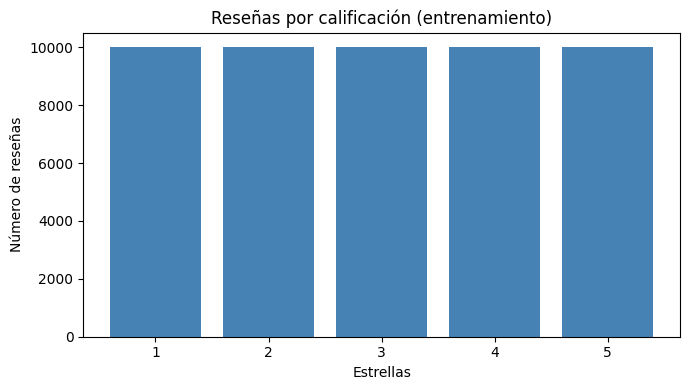

estrellas
1    10000
2    10000
3    10000
4    10000
5    10000


In [10]:
conteo = train_df['estrellas'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(conteo.index, conteo.values, color='steelblue')
ax.set_title('Reseñas por calificación (entrenamiento)')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Número de reseñas')
ax.set_xticks(CLASES)
plt.tight_layout()
plt.show()

print(conteo.to_string())

Diez mil reseñas por clase, exactamente. Un clasificador al azar acertaría en torno al 20%, que es el piso contra el que comparar. Además ninguna métrica quedará inflada por una clase mayoritaria.

### 6.2 Longitud de las reseñas

Necesitamos esta distribución para decidir dónde cortar las secuencias. La miramos también **por clase**, para ver si quien está descontento escribe más.

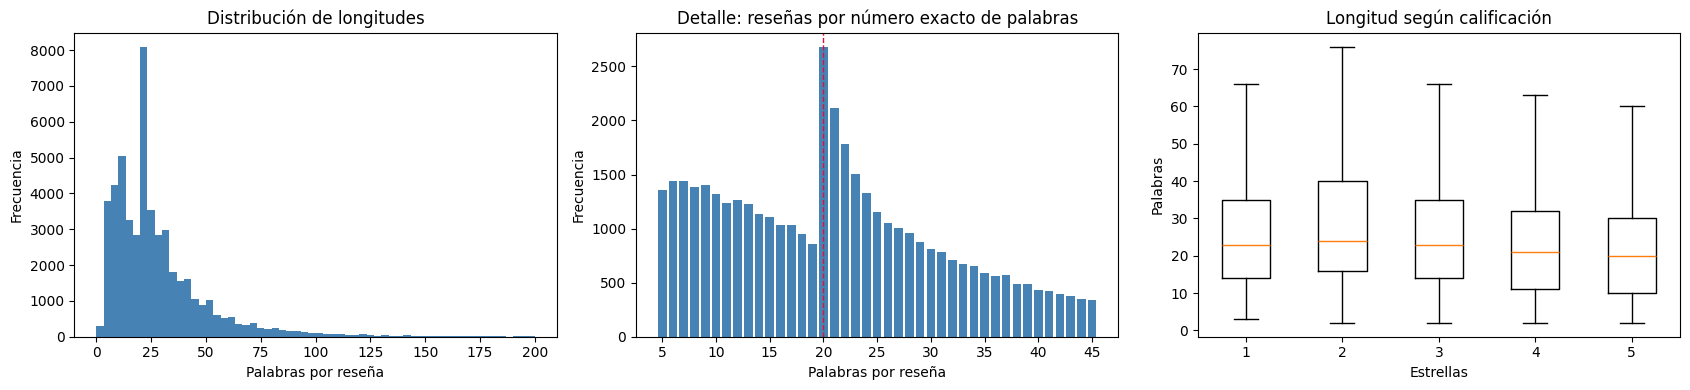

p50        22.0
p75        34.0
p90        54.0
p95        73.0
p99       123.0
media      28.1
máximo    474.0

Mediana de palabras por clase:
estrellas
1    23.0
2    24.0
3    23.0
4    21.0
5    20.0

Reseñas por número exacto de palabras alrededor del escalón:
n_palabras
17    1033
18     948
19     856
20    2677
21    2112
22    1783
23    1504

Salto entre 19 y 20 palabras: x3.13


In [11]:
train_df['n_palabras'] = train_df['text'].astype(str).str.split().str.len()

percentiles = [50, 75, 90, 95, 99]
resumen_long = pd.Series({f'p{p}': np.percentile(train_df['n_palabras'], p) for p in percentiles})
resumen_long['media'] = train_df['n_palabras'].mean()
resumen_long['máximo'] = train_df['n_palabras'].max()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(train_df['n_palabras'], bins=60, range=(0, 200), color='steelblue')
axes[0].set_title('Distribución de longitudes')
axes[0].set_xlabel('Palabras por reseña')
axes[0].set_ylabel('Frecuencia')

# Un intervalo por palabra: con intervalos más anchos el escalón de las 20 palabras se difumina.
exactas = train_df['n_palabras'].value_counts().sort_index()
tramo = exactas.loc[5:45]
axes[1].bar(tramo.index, tramo.values, color='steelblue')
axes[1].axvline(20, color='crimson', linestyle='--', linewidth=1)
axes[1].set_title('Detalle: reseñas por número exacto de palabras')
axes[1].set_xlabel('Palabras por reseña')
axes[1].set_ylabel('Frecuencia')

datos_por_clase = [train_df.loc[train_df['estrellas'] == c, 'n_palabras'] for c in CLASES]
axes[2].boxplot(datos_por_clase, tick_labels=CLASES, showfliers=False)
axes[2].set_title('Longitud según calificación')
axes[2].set_xlabel('Estrellas')
axes[2].set_ylabel('Palabras')

plt.tight_layout()
plt.show()

print(resumen_long.round(1).to_string())
print('\nMediana de palabras por clase:')
print(train_df.groupby('estrellas')['n_palabras'].median().to_string())
print('\nReseñas por número exacto de palabras alrededor del escalón:')
print(exactas.loc[17:23].to_string())
print(f'\nSalto entre 19 y 20 palabras: x{exactas.get(20, 0) / exactas.get(19, 1):.2f}')

La distribución tiene una cola larga: mediana de 22 palabras, percentil 95 en 73, percentil 99 en 123 y máximo en 474. Cortaremos por el percentil 95.

**Hay un escalón en las veinte palabras.** Contando por número exacto de palabras, la serie baja hasta 856 en las diecinueve y **salta a 2.677 en las veinte**, más del triple. Después retoma el descenso suave. Un salto así en un valor tan redondo apunta a un requisito de longitud mínima en la plataforma de origen, no a la escritura de los usuarios.

**La longitud apenas distingue clases.** Las medianas por calificación son 23, 24, 23, 21 y 20 palabras. El diagrama de cajas añade que dos estrellas es la clase más dispersa y cinco la más compacta. La diferencia es demasiado pequeña para que la longitud sirva como señal predictiva.

Estas longitudes son palabras separadas por espacios; el corte de las secuencias se fijará sobre el texto tokenizado, que produce otro recuento.

### 6.3 Vocabulario más frecuente


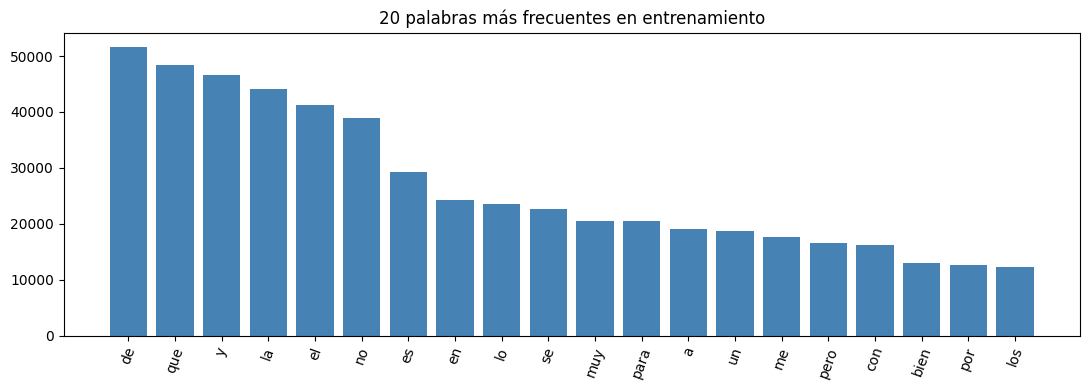

Palabras distintas en entrenamiento: 33096


In [12]:
PATRON_LIMPIEZA = re.compile(r'[^a-záéíóúüñ0-9\s]')


def tokenizar(texto):
    texto = PATRON_LIMPIEZA.sub(' ', str(texto).lower())
    return texto.split()


contador_global = Counter()
for texto in train_df['text']:
    contador_global.update(tokenizar(texto))

top_global = pd.DataFrame(contador_global.most_common(20), columns=['palabra', 'frecuencia'])

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(top_global['palabra'], top_global['frecuencia'], color='steelblue')
ax.set_title('20 palabras más frecuentes en entrenamiento')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()

print('Palabras distintas en entrenamiento:', len(contador_global))

Las 50.000 reseñas contienen 33.096 palabras distintas y el ranking lo encabezan artículos, preposiciones y conjunciones.

**La sexta palabra más frecuente es *no***, con unas 39.000 apariciones, por delante de *es*, *en*, *lo* y *se*: la única con carga semántica entre las diez primeras. En los puestos dieciséis y dieciocho aparecen *pero* y *bien*. Buena parte de lo que se dice en este corpus se construye negando o contraponiendo.

### 6.4 Palabras que distinguen cada calificación

Usamos la prueba chi cuadrado de cada palabra frente a la pertenencia a una clase. Responde a qué palabras aparecen desproporcionadamente en un nivel, no a cuáles aparecen mucho.


In [13]:
vectorizador_conteo = CountVectorizer(min_df=20, tokenizer=tokenizar, lowercase=False)
X_conteo = vectorizador_conteo.fit_transform(train_df['text'])
terminos = np.array(vectorizador_conteo.get_feature_names_out())

discriminativas = {}
for clase in CLASES:
    objetivo = (train_df['estrellas'] == clase).astype(int)
    puntajes, _ = chi2(X_conteo, objetivo)
    puntajes = np.nan_to_num(puntajes)
    # Solo interesan las palabras sobrerrepresentadas en la clase, no las ausentes.
    media_clase = np.asarray(X_conteo[objetivo.values == 1].mean(axis=0)).ravel()
    media_resto = np.asarray(X_conteo[objetivo.values == 0].mean(axis=0)).ravel()
    puntajes = np.where(media_clase > media_resto, puntajes, 0)
    discriminativas[clase] = terminos[np.argsort(puntajes)[::-1][:12]]

pd.DataFrame(discriminativas).rename(columns=lambda c: f'{c} estrellas')

,1 estrellas,2 estrellas,3 estrellas,4 estrellas,5 estrellas
0,no,no,pero,bien,perfecto
1,nada,la,bien,buena,muy
2,dinero,se,poco,buen,genial
3,ni,pero,es,precio,encantado
4,llegado,que,más,cumple,buena
5,amazon,el,está,única,buen
6,me,al,algo,relación,recomendable
7,nunca,de,demasiado,único,encanta
8,esperando,si,esperaba,perfectamente,perfecta
9,recibido,dos,demás,pega,perfectamente


**Los extremos tienen vocabulario propio.** Cinco estrellas se identifica con *perfecto*, *genial*, *encantado*, *recomendable*, *excelente*: adjetivos entusiastas y sin matices.

**Una estrella habla de logística, no de producto.** Sus términos más discriminativos son *dinero*, *llegado*, *amazon*, *nunca*, *esperando*, *recibido*, *vendedor*. La insatisfacción extrema aquí no suele ser que el artículo sea malo, sino que no llegó o hubo que reclamar.

**Las clases intermedias se apoyan en matizadores.** Tres estrellas se caracteriza por *pero*, *bien*, *poco*, *algo*, *demasiado*, *aunque*. Y los términos de dos estrellas son casi todos funcionales (*la*, *se*, *que*, *el*): **carece de vocabulario propio**, no se define por lo que dice sino por no ser ninguna de las otras.

### 6.5 Bigramas y negaciones

Medimos si el orden de las palabras deja rastro en los bigramas frecuentes y en el uso de negaciones y adversativos según la calificación.


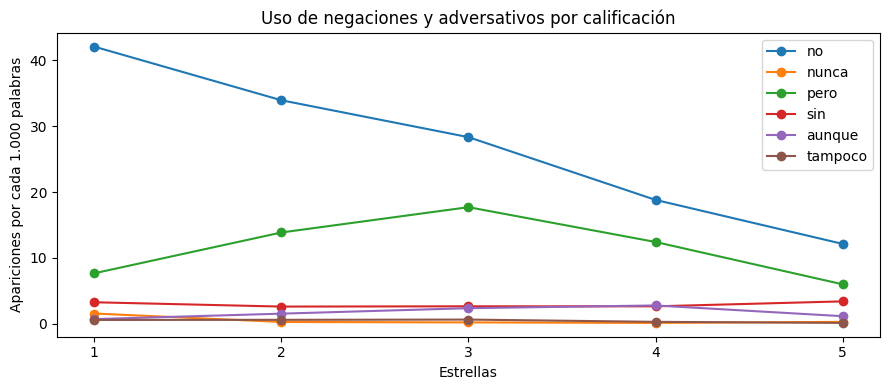

Bigramas más frecuentes:
    bigrama  frecuencia
     lo que        5368
      de la        4520
      en la        4161
      no se        4113
     que no        3907
       y no        3729
   muy bien        3585
      no me        3523
      no es        3522
     es muy        3475
    un poco        3315
      en el        3275
      me ha        3110
       a la        3073
el producto        2847

Marcadores por cada 1.000 palabras:
      no  nunca   pero   sin  aunque  tampoco
1  42.07   1.56   7.67  3.27    0.71     0.59
2  33.93   0.28  13.86  2.61    1.54     0.61
3  28.33   0.21  17.70  2.66    2.37     0.64
4  18.81   0.14  12.42  2.65    2.79     0.30
5  12.13   0.29   6.00  3.41    1.16     0.14


In [14]:
vec_bigramas = CountVectorizer(ngram_range=(2, 2), min_df=30, tokenizer=tokenizar, lowercase=False)
X_bi = vec_bigramas.fit_transform(train_df['text'])
frec_bi = np.asarray(X_bi.sum(axis=0)).ravel()
nombres_bi = np.array(vec_bigramas.get_feature_names_out())
orden = np.argsort(frec_bi)[::-1][:15]

MARCADORES = ['no', 'nunca', 'pero', 'sin', 'aunque', 'tampoco']
uso_marcadores = pd.DataFrame(index=CLASES, columns=MARCADORES, dtype=float)
for clase in CLASES:
    textos = train_df.loc[train_df['estrellas'] == clase, 'text']
    conteo_clase = Counter()
    total_tokens = 0
    for t in textos:
        tokens = tokenizar(t)
        total_tokens += len(tokens)
        conteo_clase.update(tokens)
    for m in MARCADORES:
        uso_marcadores.loc[clase, m] = 1000 * conteo_clase[m] / total_tokens

fig, ax = plt.subplots(figsize=(9, 4))
for m in MARCADORES:
    ax.plot(CLASES, uso_marcadores[m], marker='o', label=m)
ax.set_title('Uso de negaciones y adversativos por calificación')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Apariciones por cada 1.000 palabras')
ax.set_xticks(CLASES)
ax.legend()
plt.tight_layout()
plt.show()

print('Bigramas más frecuentes:')
print(pd.DataFrame({'bigrama': nombres_bi[orden], 'frecuencia': frec_bi[orden]}).to_string(index=False))
print('\nMarcadores por cada 1.000 palabras:')
print(uso_marcadores.round(2).to_string())

**Cinco de los quince bigramas más frecuentes contienen una negación**: *no se* (4.113), *que no* (3.907), *y no* (3.729), *no me* (3.523) y *no es* (3.522).

**El uso de *no* cae de forma monótona con la calificación**: 42,07 apariciones por cada mil palabras en una estrella, 33,93 en dos, 28,33 en tres, 18,81 en cuatro y 12,13 en cinco. Sin excepciones.

**El *pero* dibuja una campana centrada en las tres estrellas**: 7,67 / 13,86 / 17,70 / 12,42 / 6,00. El adversativo es la herramienta de quien tiene algo bueno y algo malo que decir.

### 6.6 Solapamiento de vocabulario entre clases

Comparamos las doscientas palabras de contenido más frecuentes de cada par de calificaciones con el índice de Jaccard.


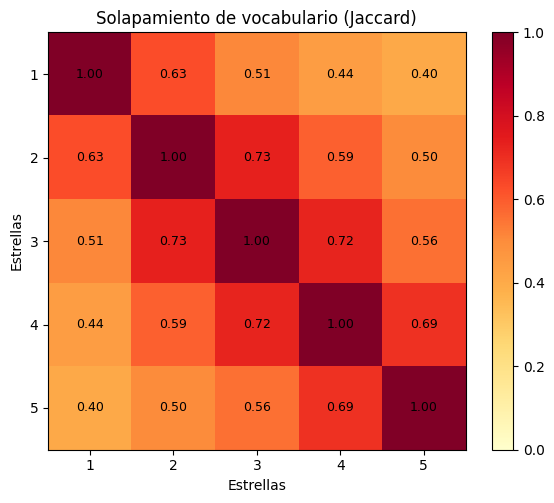

In [15]:
FUNCIONALES = {'de', 'la', 'el', 'los', 'las', 'un', 'una', 'y', 'o', 'que', 'en', 'por',
               'para', 'con', 'del', 'al', 'se', 'es', 'lo', 'a', 'me', 'mi', 'su', 'te'}

top_por_clase = {}
for clase in CLASES:
    conteo_clase = Counter()
    for t in train_df.loc[train_df['estrellas'] == clase, 'text']:
        conteo_clase.update(w for w in tokenizar(t) if w not in FUNCIONALES and len(w) > 2)
    top_por_clase[clase] = {w for w, _ in conteo_clase.most_common(200)}

jaccard = pd.DataFrame(index=CLASES, columns=CLASES, dtype=float)
for a in CLASES:
    for b in CLASES:
        interseccion = len(top_por_clase[a] & top_por_clase[b])
        union = len(top_por_clase[a] | top_por_clase[b])
        jaccard.loc[a, b] = interseccion / union

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jaccard.values.astype(float), cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASES), CLASES)
ax.set_yticks(range(NUM_CLASES), CLASES)
ax.set_title('Solapamiento de vocabulario (Jaccard)')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Estrellas')
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        ax.text(j, i, f'{jaccard.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Hay una banda caliente alrededor de la diagonal y el parecido decae al alejarse de ella.

Las calificaciones contiguas comparten casi el mismo vocabulario: los pares 2–3 y 3–4 alcanzan 0,73 y 0,72, **casi tres de cada cuatro palabras frecuentes en común**. Los pares 1–2 y 4–5 quedan en 0,63 y 0,69, y el par 1–5 es el más distinto, con 0,40.

El dato importa al elegir las métricas: si las clases vecinas son léxicamente casi indistinguibles, una métrica que trate por igual el error de una estrella y el de cuatro describirá mal lo que hace el modelo.


---
## 7. Tokenización: de palabras enteras a piezas de palabra

Un vocabulario de palabras enteras convierte en *desconocido* todo lo que no esté en él, y las reseñas están llenas de erratas, marcas y coloquialismos. Un vocabulario **subword** aprende en su lugar las secuencias de caracteres más repetidas: una palabra frecuente ocupa un identificador y una rara se descompone en piezas, así que nada queda fuera.

Entrenamos un tokenizador de este tipo **sobre la partición de entrenamiento**, con el algoritmo de byte-pair encoding de GPT-2 pero aprendiendo las fusiones desde cero. El alfabeto inicial es el de bytes, lo que garantiza cobertura total.

**Dos decisiones:**

- **16.000 entradas**, por debajo del número de palabras que aparecen al menos dos veces, para forzar la segmentación de los términos raros en lugar de memorizarlos.
- **Dos símbolos añadidos**: `[PAD]` para rellenar las secuencias cortas y `[CLS]`, un token sin contenido que anteponemos a cada reseña para usar su representación final como resumen.


In [16]:
from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer

PAD, CLS = '[PAD]', '[CLS]'
VOCAB_BPE = 16_000


def lotes_de_texto(textos, tam_lote=1_000):
    for inicio in range(0, len(textos), tam_lote):
        yield textos[inicio:inicio + tam_lote]


tokenizador_base = AutoTokenizer.from_pretrained('gpt2')

inicio = time.time()
tokenizador = tokenizador_base.train_new_from_iterator(
    lotes_de_texto(train_df['text'].tolist()),
    vocab_size=VOCAB_BPE,
    initial_alphabet=list(ByteLevel.alphabet()),
    new_special_tokens=[PAD, CLS],
    show_progress=False,
)
tokenizador.pad_token = PAD
tokenizador.cls_token = CLS

PAD_IDX = tokenizador.pad_token_id
CLS_IDX = tokenizador.cls_token_id

print(f'Tokenizador entrenado en {time.time() - inicio:.1f} s')
print('Entradas del vocabulario:', len(tokenizador))
print(f'Identificadores especiales: {PAD} -> {PAD_IDX}, {CLS} -> {CLS_IDX}')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizador entrenado en 3.1 s
Entradas del vocabulario: 16000
Identificadores especiales: [PAD] -> 1, [CLS] -> 2


In [ ]:
vocabulario_bpe = tokenizador.get_vocab()
ordenados = sorted(vocabulario_bpe.items(), key=lambda par: par[1])


def como_texto(tokens):
    return [tokenizador.convert_tokens_to_string([t]) for t in tokens]


print('Primeros 15 tokens:  ', como_texto([t for t, _ in ordenados[:15]]))
print('Tokens intermedios:  ', como_texto([t for t, _ in ordenados[3000:3015]]))
print('Últimos 15 tokens:   ', como_texto([t for t, _ in ordenados[-15:]]))

DOMINIO = ['perfecto', 'recomendable', 'decepcionante', 'devolución',
           'plasticoso', 'descambiarlo', 'rayajos', 'olgura',
           'airpods', 'amazón', 'spigen', 'dyson']

print('\nSegmentación de palabras del dominio, coloquialismos, erratas y marcas:')
for palabra in DOMINIO:
    piezas = tokenizador.tokenize(' ' + palabra)
    print(f'  {palabra:16s} -> {len(piezas)} pieza(s): {como_texto(piezas)}')

print('\nCodificación completa de una reseña breve:')
ejemplo = 'el producto parecía muy bueno y bonito pero no funciona nada bien'
print('  texto  :', ejemplo)
print('  tokens :', como_texto(tokenizador.tokenize(ejemplo)))
print('  ids    :', tokenizador(ejemplo)['input_ids'])

Primeros 15 tokens:   ['<|endoftext|>', '[PAD]', '[CLS]', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',']
Tokens intermedios:   [' vuelto', 'licar', ' ponerle', ' hice', ' libros', ' borde', 'tivamente', ' inglés', ' iPhone', ' mínimo', 'Fácil', 'cía', 'vio', ' redu', ' Pe']
Últimos 15 tokens:    [' acampada', ' ampollas', ' mostraba', ' abolladuras', ' dinosaurios', ' desprotegido', ' ADAPTA', 'Guantes', ' lienzo', ' shooter', ' parabrisas', ' ráfaga', ' Surface', ' CAMARA', ' promoción']

Segmentación de palabras del dominio, coloquialismos, erratas y marcas:
  perfecto         -> 1 pieza(s): [' perfecto']
  recomendable     -> 1 pieza(s): [' recomendable']
  decepcionante    -> 1 pieza(s): [' decepcionante']
  devolución       -> 1 pieza(s): [' devolución']
  plasticoso       -> 1 pieza(s): [' plasticoso']
  descambiarlo     -> 1 pieza(s): [' descambiarlo']
  rayajos          -> 1 pieza(s): [' rayajos']
  olgura           -> 1 pieza(s): [' olgura']
  airpods          -> 

El vocabulario tiene tres zonas: símbolos especiales y puntuación al principio; en el medio, palabras completas (*vuelto*, *libros*, *iPhone*) mezcladas con fragmentos reutilizables (*licar*, *tivamente*, *redu*); al final, palabras enteras poco frecuentes (*abolladuras*, *parabrisas*, *Surface*), las últimas fusiones que alcanzó a aprender.

**Casi nada se parte.** *Plasticoso*, *descambiarlo*, *rayajos*, *olgura*, *amazón* y *airpods* reciben **una sola pieza** cada una. Un vocabulario general los trataría como desconocidos; aquí tienen entrada propia porque el tokenizador se entrenó sobre este corpus.

Solo se descomponen dos marcas poco citadas: *spigen* en `sp` + `igen` y *dyson* en `d` + `yson`. Es la garantía buscada: una palabra fuera del vocabulario se reconstruye con piezas y nunca se pierde.


### 7.1 Subword frente a palabras enteras

Construimos el vocabulario de palabras que tendríamos con la tokenización del análisis exploratorio, quedándonos con los términos que aparecen al menos dos veces, y comparamos ambos en tres aspectos: cuántas entradas necesitan, cuántos tokens por reseña producen —que determina el coste de la atención, cuadrático en la longitud— y qué proporción de palabras de validación dejan fuera.

De ahí sale también el corte de longitud, fijado en el percentil 95 de las reseñas ya tokenizadas más una posición para el token de resumen.


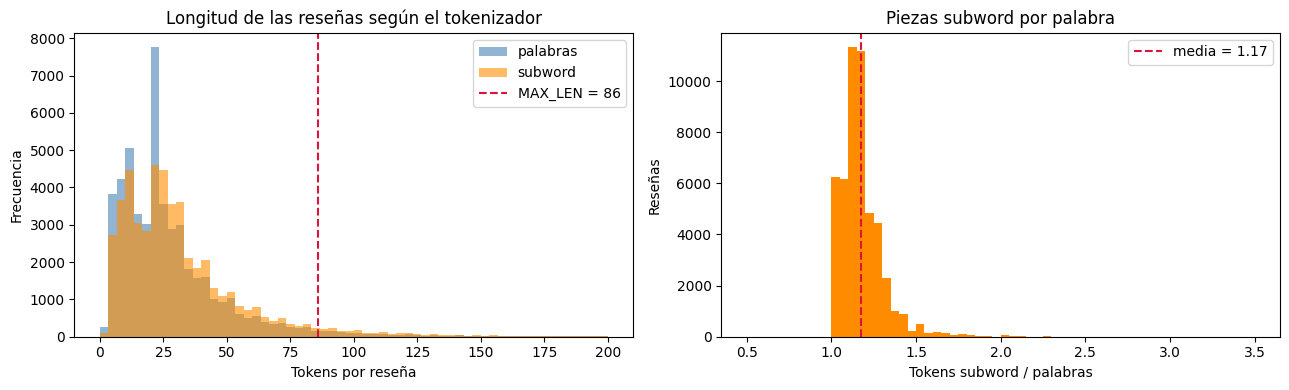

                 tokenizador  entradas  tokens por reseña (mediana)  percentil 95  fuera de vocabulario en validación
palabras (expresión regular)     19551                         22.0          73.0                               0.016
                 subword BPE     16000                         26.0          85.0                               0.000

MAX_LEN (percentil 95 del texto tokenizado + token de resumen): 86
Reseñas truncadas con ese corte: 4.9%
Fragmentación media: 1.17 piezas por palabra
Palabras del vocabulario por expresión regular sin entrada propia en el BPE: 11230 de 19549


In [18]:
FREC_MINIMA = 2

tokens_palabra_train = [tokenizar(t) for t in train_df['text']]
contador_palabras = Counter()
for tokens in tokens_palabra_train:
    contador_palabras.update(tokens)

vocabulario_palabras = {w for w, c in contador_palabras.items() if c >= FREC_MINIMA}

longitudes_palabra = np.array([len(t) for t in tokens_palabra_train])
longitudes_bpe = np.array([len(ids) for ids in tokenizador(train_df['text'].tolist())['input_ids']])

tokens_palabra_val = [tokenizar(t) for t in val_df['text']]
oov_palabras = np.mean([np.mean([w not in vocabulario_palabras for w in t]) if t else 0.0
                        for t in tokens_palabra_val])

MAX_LEN = int(np.ceil(np.percentile(longitudes_bpe, 95))) + 1  # una posición para el token de resumen

comparacion = pd.DataFrame([
    {'tokenizador': 'palabras (expresión regular)',
     'entradas': len(vocabulario_palabras) + 2,
     'tokens por reseña (mediana)': float(np.median(longitudes_palabra)),
     'percentil 95': float(np.percentile(longitudes_palabra, 95)),
     'fuera de vocabulario en validación': oov_palabras},
    {'tokenizador': 'subword BPE',
     'entradas': len(tokenizador),
     'tokens por reseña (mediana)': float(np.median(longitudes_bpe)),
     'percentil 95': float(np.percentile(longitudes_bpe, 95)),
     'fuera de vocabulario en validación': 0.0},
])

fragmentacion = longitudes_bpe / np.maximum(longitudes_palabra, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(longitudes_palabra, bins=60, range=(0, 200), alpha=0.6, color='steelblue', label='palabras')
axes[0].hist(longitudes_bpe, bins=60, range=(0, 200), alpha=0.6, color='darkorange', label='subword')
axes[0].axvline(MAX_LEN, color='crimson', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
axes[0].set_title('Longitud de las reseñas según el tokenizador')
axes[0].set_xlabel('Tokens por reseña')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(fragmentacion, bins=60, range=(0.5, 3.5), color='darkorange')
axes[1].axvline(fragmentacion.mean(), color='crimson', linestyle='--',
                label=f'media = {fragmentacion.mean():.2f}')
axes[1].set_title('Piezas subword por palabra')
axes[1].set_xlabel('Tokens subword / palabras')
axes[1].set_ylabel('Reseñas')
axes[1].legend()

plt.tight_layout()
plt.show()

print(comparacion.round(4).to_string(index=False))
print(f'\nMAX_LEN (percentil 95 del texto tokenizado + token de resumen): {MAX_LEN}')
print(f'Reseñas truncadas con ese corte: {(longitudes_bpe > MAX_LEN - 1).mean():.1%}')
print(f'Fragmentación media: {fragmentacion.mean():.2f} piezas por palabra')
print(f'Palabras del vocabulario por expresión regular sin entrada propia en el BPE: '
      f'{sum(1 for w in vocabulario_palabras if len(tokenizador.tokenize(" " + w)) > 1)} '
      f'de {len(vocabulario_palabras)}')

El intercambio queda cuantificado.

**Con un 18% menos de entradas, el subword no deja nada fuera.** El vocabulario por palabras necesita 19.551 entradas y aun así el **1,6% de las palabras de validación** no está en él; el subword usa 16.000 y su tasa de desconocidas es cero por construcción.

**El precio son secuencias más largas.** La mediana pasa de 22 a 26 tokens y el percentil 95 de 73 a 85, así que el corte queda en 86 con solo el 4,9% de reseñas truncadas. Como el coste de la atención crece con el cuadrado de la longitud, esas doce posiciones extra suponen alrededor de un 36% más de cómputo.

**La fragmentación es baja: 1,17 piezas por palabra.** Eso sí, **11.230 de las 19.549 palabras del vocabulario por expresión regular se descomponen**: más de la mitad, pero la mitad rara. Las frecuentes, que ocupan la mayor parte de los tokens, conservan su entrada.


---
## 8. Cómo medimos

Las clases contiguas comparten hasta el 73% de su vocabulario, y accuracy y F1 son ciegas a esa estructura porque tratan las cinco como categorías sin relación. Añadimos dos métricas que sí la capturan:

- **MAE en estrellas**: a cuántas estrellas de distancia se equivoca en promedio.
- **Kappa cuadrático ponderado (QWK)**: penaliza cada error en proporción al cuadrado de la distancia entre la clase real y la predicha.

**El kappa cuadrático es el criterio único de decisión.** No solo elige el modelo final: también decide en qué época se detiene cada entrenamiento y qué punto de control se conserva. Declarar que se prefiere el error cercano y seleccionar por F1 sería optimizar una cosa y juzgar otra.

Calculamos además el margen de error del acierto, para saber a partir de qué diferencia dos modelos dejan de ser distinguibles con una sola ejecución.


In [ ]:
def evaluar(nombre, y_real, y_pred, segundos=None):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_real, y_pred),
        'f1_macro': f1_score(y_real, y_pred, average='macro'),
        'mae_estrellas': mean_absolute_error(y_real, y_pred),
        'qwk': cohen_kappa_score(y_real, y_pred, weights='quadratic'),
        'segundos': segundos,
    }


resultados_val = []

# Resolución de la comparación: por debajo de este margen, dos modelos no son distinguibles.
p_esperada = 0.5
margen_val = 1.96 * math.sqrt(p_esperada * (1 - p_esperada) / len(val_df))
margen_test = 1.96 * math.sqrt(p_esperada * (1 - p_esperada) / len(test_df))

print(f'Reseñas de validación: {len(val_df)} | de prueba: {len(test_df)}')
print(f'Margen de error del acierto al 95% en validación: ±{margen_val:.4f}')
print(f'Margen de error del acierto al 95% en prueba:     ±{margen_test:.4f}')
print('\nDos modelos que difieran menos que ese margen no son distinguibles con una sola ejecución.')

Reseñas de validación: 4995 | de prueba: 4994
Margen de error del acierto al 95% en validación: ±0.0139
Margen de error del acierto al 95% en prueba:     ±0.0139

Dos modelos que difieran menos que ese margen no son distinguibles con una sola ejecución.


---
## 9. Primer escalón: un modelo que ignora el orden

Necesitamos saber hasta dónde llega un modelo que trata la reseña como un conjunto desordenado de palabras. Sin esa referencia, un F1 de 0,50 puede ser excelente o mediocre.

Usamos TF-IDF con unigramas y bigramas más regresión logística, y un clasificador trivial para fijar el piso. Es el único modelo del cuaderno que se entrena en CPU con scikit-learn.

**Una sola matriz para los dos modelos de bolsa de palabras**, de modo que la comparación entre ellos aísle la arquitectura. Eso obliga a limitar el vocabulario a 20.000 términos, porque el perceptrón necesita densificar cada lote.


In [20]:
MAX_RASGOS_TFIDF = 20_000

# Una sola matriz para el modelo lineal y para el perceptrón: así la comparación entre ambos
# aísla la arquitectura. El límite de rasgos es lo que permite densificar los lotes del perceptrón.
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=MAX_RASGOS_TFIDF,
                        sublinear_tf=True, tokenizer=tokenizar, lowercase=False)
X_train_tfidf = tfidf.fit_transform(train_df['text']).astype(np.float32)
X_val_tfidf = tfidf.transform(val_df['text']).astype(np.float32)
X_test_tfidf = tfidf.transform(test_df['text']).astype(np.float32)

print('Dimensión de la matriz TF-IDF:', X_train_tfidf.shape)

inicio = time.time()
regresion = LogisticRegression(max_iter=2000, n_jobs=-1)
regresion.fit(X_train_tfidf, train_df['estrellas'])
segundos_tfidf = time.time() - inicio

pred_val_tfidf = regresion.predict(X_val_tfidf)

trivial = DummyClassifier(strategy='stratified', random_state=SEED)
trivial.fit(X_train_tfidf, train_df['estrellas'])

resultados_val.append(evaluar('TF-IDF + LogReg', val_df['estrellas'], pred_val_tfidf, segundos_tfidf))
resultados_val[-1].update({'corpus': len(train_df), 'épocas': None, 'parámetros': None})
referencia_trivial = evaluar('Azar', val_df['estrellas'], trivial.predict(X_val_tfidf))

print('\nPiso de referencia (azar):')
print(f"  Accuracy {referencia_trivial['accuracy']:.4f}  F1-macro {referencia_trivial['f1_macro']:.4f}  "
      f"MAE {referencia_trivial['mae_estrellas']:.4f}")

print('\nTF-IDF + regresión logística:')
print(f"  Accuracy {resultados_val[-1]['accuracy']:.4f}  F1-macro {resultados_val[-1]['f1_macro']:.4f}  "
      f"MAE {resultados_val[-1]['mae_estrellas']:.4f}  QWK {resultados_val[-1]['qwk']:.4f}")
print(f"  Entrenamiento: {segundos_tfidf:.1f} s")

Dimensión de la matriz TF-IDF: (50000, 20000)

Piso de referencia (azar):
  Accuracy 0.2030  F1-macro 0.2029  MAE 1.5862

TF-IDF + regresión logística:
  Accuracy 0.5083  F1-macro 0.5061  MAE 0.6344  QWK 0.7509
  Entrenamiento: 9.4 s


La vara queda alta: **F1-macro de 0,5061, MAE de 0,6344 y QWK de 0,7509** con 20.000 rasgos y **9,4 segundos de CPU**. El azar se queda en 0,2029 de F1 y 1,5862 estrellas de error.

El MAE merece atención: un error medio de 0,63 estrellas significa que, aunque solo acierte la nota exacta en la mitad de los casos, **casi nunca se equivoca de forma grave**. Falla al afinar, no al orientarse.

Cualquier arquitectura posterior tiene que justificar su coste frente a estos números, y el listón está en diez segundos.


---
## 10. Las reseñas como secuencias de longitud fija

Cada reseña se convierte en una secuencia de 86 identificadores: el token de resumen, las piezas subword del texto y relleno hasta completar. Junto a ellos viaja una **máscara de atención** que marca qué posiciones contienen texto real; sin ella la atención repartiría parte de su peso entre posiciones vacías.

**Tokenizamos una vez al construir el conjunto, no en cada acceso.** Hacerlo dentro de `__getitem__` es más corto de escribir, pero repite el mismo cálculo en cada época y para cada modelo, dejando a la CPU como cuello de botella mientras la GPU espera. El coste son unas decenas de megabytes de memoria y, a cambio, servir un ejemplo se reduce a indexar un tensor. Por el mismo motivo prescindimos de procesos de carga en paralelo.


In [21]:
BATCH = 128


def codificar(textos, max_len=None, tam_bloque=20_000):
    max_len = max_len or MAX_LEN
    textos = list(textos)
    ids, mascaras = [], []
    # Por bloques: tokenizar de golpe el corpus completo dispararía la memoria de las listas intermedias.
    for inicio in range(0, len(textos), tam_bloque):
        salida = tokenizador(textos[inicio:inicio + tam_bloque], max_length=max_len - 1,
                             truncation=True, padding='max_length')
        ids.append(torch.tensor(salida['input_ids'], dtype=torch.long))
        mascaras.append(torch.tensor(salida['attention_mask'], dtype=torch.bool))

    ids = torch.cat(ids)
    mascara = torch.cat(mascaras)
    resumen = torch.full((ids.shape[0], 1), CLS_IDX, dtype=torch.long)
    activo = torch.ones((ids.shape[0], 1), dtype=torch.bool)
    return torch.cat([resumen, ids], dim=1), torch.cat([activo, mascara], dim=1)


class ResenasDataset(Dataset):
    # Tokenizo al construir y no en cada acceso: repetir la tokenización en cada época
    # dominaba el tiempo de entrenamiento frente al cálculo en la GPU.
    def __init__(self, df, max_len=None):
        self.input_ids, self.attention_mask = codificar(df['text'].tolist(), max_len)
        self.etiquetas = torch.tensor((df['estrellas'] - 1).to_numpy(), dtype=torch.long)

    def __len__(self):
        return len(self.etiquetas)

    def __getitem__(self, i):
        return {'input_ids': self.input_ids[i],
                'attention_mask': self.attention_mask[i],
                'label': self.etiquetas[i]}


def cargador(conjunto, barajar=False):
    # Con los datos ya en memoria, los procesos de carga solo añadirían sobrecarga.
    return DataLoader(conjunto, batch_size=BATCH, shuffle=barajar,
                      generator=GENERADOR if barajar else None,
                      num_workers=0, pin_memory=EN_GPU)


inicio = time.time()
ds_train = ResenasDataset(train_df)
ds_val = ResenasDataset(val_df)
ds_test = ResenasDataset(test_df)
print(f'Tokenización previa de las tres particiones: {time.time() - inicio:.1f} s')

train_loader = cargador(ds_train, barajar=True)
val_loader = cargador(ds_val)
test_loader = cargador(ds_test)

lote = next(iter(train_loader))
print('Forma del lote de entrada:  ', lote['input_ids'].shape)
print('Forma de la máscara:        ', lote['attention_mask'].shape)
print('Forma de las etiquetas:     ', lote['label'].shape)
print(f'Lotes por época: {len(train_loader)} (entrenamiento), {len(val_loader)} (validación)')
print(f'Memoria de las secuencias: '
      f'{ds_train.input_ids.element_size() * ds_train.input_ids.nelement() / 1e6:.0f} MB')
print(f'\nPrimera secuencia del lote (el identificador {PAD_IDX} es el relleno):')
print(lote['input_ids'][0][:24].tolist(), '...')
print('Posiciones activas en esa secuencia:', int(lote['attention_mask'][0].sum()), f'de {MAX_LEN}')

Tokenización previa de las tres particiones: 7.9 s
Forma del lote de entrada:   torch.Size([128, 86])
Forma de la máscara:         torch.Size([128, 86])
Forma de las etiquetas:      torch.Size([128])
Lotes por época: 391 (entrenamiento), 40 (validación)
Memoria de las secuencias: 34 MB

Primera secuencia del lote (el identificador 1 es el relleno):
[2, 545, 12154, 355, 1232, 16, 448, 318, 1480, 275, 580, 16, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
Posiciones activas en esa secuencia: 12 de 86


---
## 11. El codificador, pieza por pieza

La tarea es de clasificación, así que solo necesitamos la mitad izquierda de la arquitectura original: el **codificador**.

### 11.1 Codificación posicional

La atención no distingue el orden: si permutamos las palabras de la entrada, permuta la salida y nada más. Como *no me gustó nada* y *me gustó, nada que objetar* comparten casi las mismas palabras, el orden hay que inyectarlo explícitamente.

El artículo original lo suma al embedding con una función que alterna **seno en las dimensiones pares y coseno en las impares**, dando a cada dimensión una frecuencia distinta que decrece según su índice. Así dos posiciones cercanas reciben vectores parecidos y dos lejanas, vectores distintos. Su ventaja es que se precalcula y no consume parámetros ni gradientes.

Los autores indicaron que aprender las posiciones da resultados equivalentes, así que la dejamos como una de las variantes a comparar junto con la opción de no usar ninguna.

### Una trampa en el escalado de los embeddings

El artículo multiplica los embeddings por la raíz de la dimensión del modelo antes de sumar la posición. Ese factor **no es arbitrario**: presupone que los embeddings están inicializados con una desviación igual a la inversa de esa misma raíz, de modo que tras el escalado quedan en una escala comparable a la de la codificación posicional.

`nn.Embedding` de PyTorch inicializa con desviación 1, no con esa. Multiplicar por la raíz sin corregir la inicialización deja los embeddings con componentes unas once veces mayores de lo previsto, con dos consecuencias:

- La codificación posicional queda dieciséis veces por debajo del contenido en norma, así que apenas altera el vector.
- Los productos punto que entran al softmax de la atención crecen con el cuadrado de esa escala. Con un factor de ciento veintiocho sobre la varianza, el softmax **arranca ya concentrado**: reparte casi todo el peso en una posición y deja pasar un gradiente ínfimo.

Por eso inicializamos la tabla explícitamente con la desviación que el artículo presupone, y más abajo medimos las dos escalas para comprobar que la atención arranca repartida.


In [ ]:
class CodificacionSinusoidal(nn.Module):
    def __init__(self, max_len, dim_modelo):
        super().__init__()
        posicion = torch.arange(max_len).unsqueeze(1)
        dimension = torch.arange(dim_modelo).unsqueeze(0)
        divisor = 1 / torch.pow(10000, (2 * (dimension // 2)) / torch.tensor(dim_modelo, dtype=torch.float32))
        angulos = posicion * divisor

        codificacion = torch.zeros(max_len, dim_modelo)
        codificacion[:, 0::2] = torch.sin(angulos[:, 0::2])
        codificacion[:, 1::2] = torch.cos(angulos[:, 1::2])
        # No es un parámetro: se precalcula y no recibe gradiente.
        self.register_buffer('codificacion', codificacion.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.codificacion[:, :x.size(1), :]


class CodificacionAprendida(nn.Module):
    def __init__(self, max_len, dim_modelo):
        super().__init__()
        self.posiciones = nn.Embedding(max_len, dim_modelo)

    def forward(self, x):
        indices = torch.arange(x.size(1), device=x.device)
        return x + self.posiciones(indices).unsqueeze(0)


class SinCodificacion(nn.Module):
    def forward(self, x):
        return x


class EmbeddingDeTokens(nn.Module):
    def __init__(self, tam_vocabulario, dim_modelo, max_len, tipo_posicion='sinusoidal', dropout=0.1):
        super().__init__()
        self.dim_modelo = dim_modelo
        self.tokens = nn.Embedding(tam_vocabulario, dim_modelo, padding_idx=PAD_IDX)
        # El artículo escala los embeddings por la raíz de la dimensión asumiendo esta desviación.
        # Con la de PyTorch, que es 1, el escalado los deja 128 veces más grandes y la atención
        # nace saturada: los productos punto entran al softmax con una desviación de unas 40 unidades.
        nn.init.normal_(self.tokens.weight, mean=0.0, std=dim_modelo ** -0.5)
        with torch.no_grad():
            self.tokens.weight[PAD_IDX].zero_()

        if tipo_posicion == 'sinusoidal':
            self.posicion = CodificacionSinusoidal(max_len, dim_modelo)
        elif tipo_posicion == 'aprendida':
            self.posicion = CodificacionAprendida(max_len, dim_modelo)
        else:
            self.posicion = SinCodificacion()
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.tokens(input_ids) * math.sqrt(self.dim_modelo)
        return self.dropout(self.posicion(x))


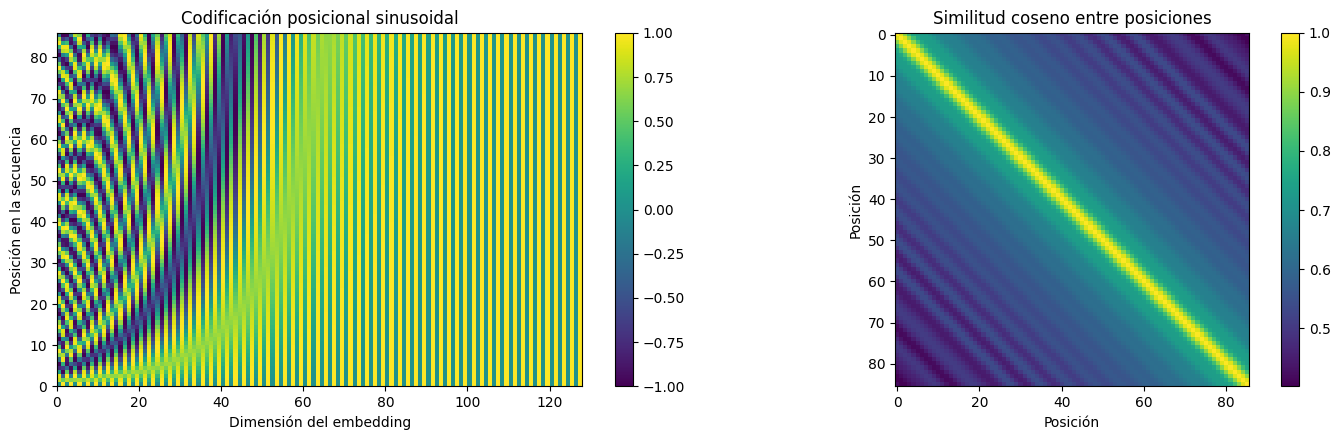

Forma de la matriz posicional: (86, 128)
Similitud entre la posición 10 y sus vecinas:
  posición 10 ~ posición  10:  1.000
  posición 10 ~ posición  11:  0.970
  posición 10 ~ posición  13:  0.815
  posición 10 ~ posición  20:  0.669
  posición 10 ~ posición  40:  0.566
  posición 10 ~ posición  85:  0.492


In [23]:
matriz_posicional = CodificacionSinusoidal(MAX_LEN, DIM_MODELO).codificacion.squeeze(0).numpy()
similitud_posiciones = matriz_posicional @ matriz_posicional.T
norma = np.linalg.norm(matriz_posicional, axis=1, keepdims=True)
similitud_posiciones = similitud_posiciones / (norma * norma.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

im0 = axes[0].pcolormesh(matriz_posicional, cmap='viridis')
axes[0].set_title('Codificación posicional sinusoidal')
axes[0].set_xlabel('Dimensión del embedding')
axes[0].set_ylabel('Posición en la secuencia')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(similitud_posiciones, cmap='viridis')
axes[1].set_title('Similitud coseno entre posiciones')
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Posición')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print('Forma de la matriz posicional:', matriz_posicional.shape)
print('Similitud entre la posición 10 y sus vecinas:')
for otra in [10, 11, 13, 20, 40, MAX_LEN - 1]:
    print(f'  posición 10 ~ posición {otra:3d}: {similitud_posiciones[10, otra]: .3f}')

**No todas las dimensiones transportan la misma información.** Las primeras treinta oscilan muy deprisa; a partir de la sesenta las columnas son casi constantes, porque su periodo es mucho mayor que las 86 posiciones que necesitamos. Con textos cortos, buena parte del vector posicional apenas varía.

**El decaimiento es ordenado.** La posición 10 tiene 0,970 de similitud con la 11, 0,815 con la 13, 0,669 con la 20, 0,566 con la 40 y 0,492 con la última. La noción de proximidad está disponible sin haberla aprendido.

Pero **la similitud nunca baja de 0,49**, ni siquiera entre los dos extremos. Los vectores posicionales no son ortogonales entre sí y, sumados a un embedding escalado, constituyen una señal débil. Por eso conviene medir cuánto aporta realmente, comparándola con una codificación aprendida y con no usar ninguna.


### 11.2 Atención multi-cabeza

El núcleo del modelo. Cada posición proyecta su vector en tres papeles: **consulta** (qué busco), **clave** (qué ofrezco) y **valor** (qué aporta si me eliges). El producto punto entre consultas y claves da los pesos con los que se promedian los valores, y esos pesos pasan por un softmax para que sumen uno.

Antes del softmax se divide por la raíz de la dimensión de las claves. Sin esa división el producto punto crece con la dimensión y deja al softmax en una región donde el gradiente es casi nulo.

**Multi-cabeza** significa repartir las dimensiones en varios grupos y ejecutar la operación por separado en cada uno. Cada cabeza trabaja sobre su propio subespacio y reparte su atención con independencia de las demás. Los resultados se concatenan y se mezclan con una proyección lineal.

**La máscara.** Las posiciones de relleno no significan nada, así que antes del softmax ponemos sus puntuaciones al valor mínimo representable; tras la exponencial reciben un peso nulo y no contaminan la media.

**Los tres modos de mezcla.** El mismo módulo implementa las dos variantes de control. Cuando los pesos no salen de la atención se sustituyen por una matriz fija —la identidad, que deja cada posición aislada, o un reparto uniforme sobre las posiciones activas— sin tocar ninguna de las cuatro proyecciones lineales, y pasando por el mismo dropout que reciben los pesos de la atención. Así las tres versiones tienen los mismos parámetros y lo único que cambia es de dónde salen los pesos.

**Dos cosas que no quedan igualadas.** La primera es que compartir el módulo de dropout no significa recibir el mismo efecto. Sobre una distribución de atención repartida entre decenas de posiciones, anular el diez por ciento de los pesos apenas mueve la media resultante; sobre la identidad, ese mismo diez por ciento deja el vector de la posición afectada en cero. El control sin mezcla recibe, en la práctica, una regularización más dura que las otras dos variantes.

La segunda es que en los dos controles las proyecciones de consulta y clave se crean pero nunca se usan, así que no reciben gradiente. El conteo de parámetros coincide, pero los parámetros que de verdad aprenden son menos. Y en el modo identidad, la proyección de valor y la de combinación quedan encadenadas sin ninguna no linealidad entre ellas, de modo que juntas equivalen a una sola transformación lineal. Conviene tenerlo presente al leer los resultados de ese peldaño.


In [ ]:
class AtencionMultiCabeza(nn.Module):
    def __init__(self, dim_modelo, num_cabezas=4, dropout=0.1, mezcla='atencion'):
        super().__init__()
        assert dim_modelo % num_cabezas == 0, 'La dimensión del modelo debe ser divisible por el número de cabezas'
        self.num_cabezas = num_cabezas
        self.dim_cabeza = dim_modelo // num_cabezas
        self.mezcla = mezcla
        self.consulta = nn.Linear(dim_modelo, dim_modelo)
        self.clave = nn.Linear(dim_modelo, dim_modelo)
        self.valor = nn.Linear(dim_modelo, dim_modelo)
        self.combinar = nn.Linear(dim_modelo, dim_modelo)
        self.dropout = nn.Dropout(dropout)

    @staticmethod
    def producto_punto_escalado(q, k, v, mascara=None, dropout=None):
        dim_clave = q.size(-1)
        puntajes = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(dim_clave)
        if mascara is not None:
            # La máscara llega como (lote, longitud) y se difunde sobre cabezas y consultas.
            puntajes = puntajes.masked_fill(
                mascara.reshape(mascara.shape[0], 1, 1, -1) == 0,
                torch.finfo(puntajes.dtype).min,
            )
        atencion = torch.softmax(puntajes, dim=-1)
        if dropout is not None:
            atencion = dropout(atencion)
        return torch.matmul(atencion, v), atencion

    @staticmethod
    def pesos_fijos(v, mascara, modo, dropout=None):
        # Controles: los pesos no dependen del contenido, solo del modo y de la máscara.
        lote, cabezas, longitud, _ = v.size()
        if modo == 'uniforme':
            activa = mascara.reshape(lote, 1, 1, longitud).to(v.dtype)
            pesos = activa / activa.sum(dim=-1, keepdim=True).clamp(min=1)
            pesos = pesos.expand(lote, cabezas, longitud, longitud)
        else:
            identidad = torch.eye(longitud, device=v.device, dtype=v.dtype)
            pesos = identidad.reshape(1, 1, longitud, longitud).expand(lote, cabezas, longitud, longitud)
        # Reciben el mismo dropout que la atención: sin él los controles entrenarían menos
        # regularizados y la escalera mediría la regularización además del mecanismo.
        if dropout is not None:
            pesos = dropout(pesos)
        return torch.matmul(pesos, v), pesos

    def separar_cabezas(self, x):
        lote, longitud, _ = x.size()
        x = x.reshape(lote, longitud, self.num_cabezas, self.dim_cabeza)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mascara=None):
        lote, longitud, dim = x.size()
        # Las tres proyecciones se crean siempre, también en los controles: así las variantes
        # tienen el mismo número de parámetros y solo cambia de dónde salen los pesos de mezcla.
        q = self.separar_cabezas(self.consulta(x))
        k = self.separar_cabezas(self.clave(x))
        v = self.separar_cabezas(self.valor(x))

        if self.mezcla == 'atencion':
            contexto, atencion = self.producto_punto_escalado(q, k, v, mascara, self.dropout)
        else:
            contexto, atencion = self.pesos_fijos(v, mascara, self.mezcla, self.dropout)

        contexto = contexto.permute(0, 2, 1, 3).reshape(lote, longitud, dim)
        return self.combinar(contexto), atencion


### 11.3 El bloque codificador

Cada bloque tiene dos subcapas: la atención multi-cabeza y una red densa que se aplica por separado a cada posición. El artículo define ambas igual: **se suma la entrada a la salida de la subcapa y el resultado se normaliza por capa**.

Esa suma es la **conexión residual**. Sin ella la información original tendría que sobrevivir intacta a cada transformación, y el gradiente tendría que atravesarlas todas en el camino de vuelta.

El bloque recibe dos interruptores para poder medir el efecto de cada pieza: uno activa o desactiva las residuales, y el otro elige de dónde salen los pesos que combinan las posiciones.

### 11.4 Resumir la secuencia en un vector

El codificador devuelve un vector por posición y el clasificador necesita uno solo. Comparamos tres formas:

- **Token de resumen**: la representación final del `[CLS]`, que no tiene contenido propio y solo puede describir la secuencia a través de la atención.
- **Promedio enmascarado**: la media de las posiciones con texto real, que trata todas las palabras por igual.
- **Aplanamiento**: concatenar todas las posiciones. Conserva toda la información, pero multiplica los parámetros de la capa de salida y ata el modelo a una longitud fija.


In [ ]:
class BloqueTransformer(nn.Module):
    def __init__(self, dim_modelo, num_cabezas=4, dim_ffn=512, dropout=DROPOUT, residual=True,
                 mezcla='atencion'):
        super().__init__()
        self.residual = residual
        self.atencion = AtencionMultiCabeza(dim_modelo, num_cabezas, dropout, mezcla)
        self.ffn = nn.Sequential(
            nn.Linear(dim_modelo, dim_ffn),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ffn, dim_modelo),
        )
        self.norma_atencion = nn.LayerNorm(dim_modelo)
        self.norma_ffn = nn.LayerNorm(dim_modelo)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mascara=None):
        salida_atencion, pesos = self.atencion(x, mascara)
        salida_atencion = self.dropout(salida_atencion)
        x = self.norma_atencion(x + salida_atencion if self.residual else salida_atencion)

        salida_ffn = self.dropout(self.ffn(x))
        x = self.norma_ffn(x + salida_ffn if self.residual else salida_ffn)
        return x, pesos


class CodificadorTransformer(nn.Module):
    # Con num_bloques=0 desaparece el bloque entero; con mezcla='ninguna' o 'uniforme' se conserva
    # el bloque completo y solo se sustituye el origen de los pesos que combinan las posiciones.
    def __init__(self, tam_vocabulario, max_len, dim_modelo=DIM_MODELO, num_cabezas=4, num_bloques=2,
                 dim_ffn=512, dropout=DROPOUT, tipo_posicion='sinusoidal', resumen='cls',
                 residual=True, mezcla='atencion'):
        super().__init__()
        self.resumen = resumen
        self.embedding = EmbeddingDeTokens(tam_vocabulario, dim_modelo, max_len, tipo_posicion, dropout)
        self.bloques = nn.ModuleList([
            BloqueTransformer(dim_modelo, num_cabezas, dim_ffn, dropout, residual, mezcla)
            for _ in range(num_bloques)
        ])
        self.dropout = nn.Dropout(dropout)
        self.dim_salida = dim_modelo * max_len if resumen == 'aplanado' else dim_modelo

    def forward(self, input_ids, attention_mask=None):
        mascara = attention_mask if attention_mask is not None else (input_ids != PAD_IDX)
        x = self.embedding(input_ids)

        pesos = []
        for bloque in self.bloques:
            x, atencion = bloque(x, mascara)
            pesos.append(atencion)

        activa = mascara.unsqueeze(-1).to(x.dtype)
        if self.resumen == 'cls':
            representacion = x[:, 0]
        elif self.resumen == 'promedio':
            representacion = (x * activa).sum(dim=1) / activa.sum(dim=1).clamp(min=1)
        else:
            # Anulo el relleno antes de concatenar: si no, ocuparía posiciones fijas con ruido.
            representacion = (x * activa).flatten(start_dim=1)

        return self.dropout(representacion), pesos


### 11.5 Comprobaciones antes de entrenar

Un error en las formas de los tensores o en la máscara no produce una excepción: produce un modelo que entrena y no aprende. Comprobamos cuatro cosas sobre un lote real antes de gastar tiempo de GPU:

1. Que la representación de salida tiene la forma que espera el clasificador.
2. Que los pesos de atención de cada posición **suman uno**, como corresponde a una distribución de probabilidad.
3. Que las posiciones de relleno reciben un peso despreciable, es decir, que la máscara está haciendo su trabajo.
4. Que los dos controles de mezcla se construyen con **el mismo número de parámetros** que la configuración con atención, de modo que ninguno compita con una tabla o unas capas más grandes.


In [26]:
# La red densa interna del bloque es cuatro veces la dimensión del modelo, como en el artículo.
CABEZAS, BLOQUES, DIM_FFN = 4, 2, 4 * DIM_MODELO

prueba = CodificadorTransformer(len(tokenizador), MAX_LEN, dim_modelo=DIM_MODELO,
                                num_cabezas=CABEZAS, num_bloques=BLOQUES,
                                dim_ffn=DIM_FFN, dropout=DROPOUT).eval()

with torch.no_grad():
    representacion, pesos = prueba(lote['input_ids'], lote['attention_mask'])

print('Entrada:       ', tuple(lote['input_ids'].shape))
print('Representación:', tuple(representacion.shape))
print('Atención por bloque:', [tuple(p.shape) for p in pesos])
assert representacion.shape == (lote['input_ids'].shape[0], prueba.dim_salida)

ultima = pesos[-1]
sumas = ultima.sum(dim=-1)
print(f'\nSuma de cada distribución de atención: mínimo {sumas.min():.4f}, máximo {sumas.max():.4f}')
assert torch.allclose(sumas, torch.ones_like(sumas), atol=1e-4)

relleno = (~lote['attention_mask']).reshape(lote['attention_mask'].shape[0], 1, 1, -1).expand_as(ultima)
peso_real = ultima.masked_select(~relleno).max()
print(f'Peso máximo sobre una posición con texto:  {peso_real:.4f}')
if relleno.any():
    peso_relleno = ultima.masked_select(relleno).max()
    print(f'Peso máximo sobre una posición de relleno: {peso_relleno:.2e}')
    assert peso_relleno < 1e-6

# La escala de los productos punto antes del softmax decide si la atención arranca repartida
# o ya concentrada; con embeddings mal escalados el softmax nace saturado y no recibe gradiente.
with torch.no_grad():
    primera = prueba.bloques[0].atencion
    vectores = prueba.embedding(lote['input_ids'])
    q = primera.separar_cabezas(primera.consulta(vectores))
    k = primera.separar_cabezas(primera.clave(vectores))
    logits = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(primera.dim_cabeza)

activas = lote['attention_mask'].sum(dim=1).float().mean()
print(f'\nDesviación de los embeddings escalados: {vectores.std():.2f}')
print(f'Desviación de los logits de atención:   {logits.std():.2f}')
print(f'Peso uniforme de referencia: {1 / activas:.4f} ({activas:.0f} posiciones activas de media)')

parametros = sum(p.numel() for p in prueba.parameters())
parametros_embedding = sum(p.numel() for p in prueba.embedding.parameters())
print(f'\nParámetros del codificador: {parametros:,}')
print(f'  de ellos en la tabla de embeddings: {parametros_embedding:,} '
      f'({parametros_embedding / parametros:.0%})')

# Los controles deben tener exactamente los mismos parámetros que la base: lo único que
# cambia es de dónde salen los pesos con que se combinan las posiciones.
for modo in ('ninguna', 'uniforme'):
    control = CodificadorTransformer(len(tokenizador), MAX_LEN, dim_modelo=DIM_MODELO,
                                     num_cabezas=CABEZAS, num_bloques=BLOQUES, dim_ffn=DIM_FFN,
                                     dropout=DROPOUT, resumen='promedio', mezcla=modo).eval()
    assert sum(p.numel() for p in control.parameters()) == parametros
    with torch.no_grad():
        _, pesos_control = control(lote['input_ids'], lote['attention_mask'])
    sumas_control = pesos_control[-1].sum(dim=-1)
    assert torch.allclose(sumas_control, torch.ones_like(sumas_control), atol=1e-4)
    print(f"Control con mezcla '{modo}': mismos {parametros:,} parámetros, pesos que suman 1")


Entrada:        (128, 86)
Representación: (128, 128)
Atención por bloque: [(128, 4, 86, 86), (128, 4, 86, 86)]

Suma de cada distribución de atención: mínimo 1.0000, máximo 1.0000
Peso máximo sobre una posición con texto:  0.4247
Peso máximo sobre una posición de relleno: 0.00e+00

Desviación de los embeddings escalados: 0.85
Desviación de los logits de atención:   0.30
Peso uniforme de referencia: 0.0338 (30 posiciones activas de media)

Parámetros del codificador: 2,444,544
  de ellos en la tabla de embeddings: 2,048,000 (84%)
Control con mezcla 'ninguna': mismos 2,444,544 parámetros, pesos que suman 1
Control con mezcla 'uniforme': mismos 2,444,544 parámetros, pesos que suman 1


Las comprobaciones pasan. Cada bloque devuelve un tensor de atención de forma `(128, 4, 86, 86)`, todas las distribuciones suman 1,0000 y **el peso máximo sobre una posición de relleno es 0,00e+00**: la máscara anula el relleno, no lo atenúa.

Las dos escalas quedan donde deben. Los embeddings ya escalados tienen una desviación de **0,85** y los productos punto que entran al softmax, de **0,30**. Con valores en ese rango el softmax reparte en lugar de elegir, que es la condición para que el gradiente fluya desde el primer paso.

Los dos controles se construyen con **los mismos 2.444.544 parámetros** que la base y sus pesos también suman uno por fila. Eso descarta que ganen o pierdan por tener más capacidad disponible, aunque no los iguala del todo: como las proyecciones de consulta y clave no se usan en ellos, la parte que realmente aprende es menor que la cifra sugiere.

Un dato que conviene tener presente al comparar arquitecturas: **el 84% de los parámetros está en la tabla de embeddings**. La atención, las redes densas y las normalizaciones suman 396.544, algo menos de una sexta parte. Los modelos sin atención que vamos a comparar tienen tablas del mismo tamaño, así que **las diferencias entre arquitecturas saldrán de esa sexta parte**.


---
## 12. El entrenamiento

Envolvemos cualquier codificador en un mismo módulo de Lightning. Vamos a entrenar diecisiete modelos, y encapsular el bucle garantiza que todos compartan optimizador, ritmo de aprendizaje, recorte de gradiente, dropout y criterio de parada.

**Un único criterio de principio a fin.** La parada temprana vigila el kappa cuadrático de validación, y el punto de control que se restaura es el de la época que lo maximiza. Seguimos registrando F1 y acierto para poder mirarlos, pero no deciden nada. El tope de épocas se fija alto para que sea la parada temprana quien decida cuándo terminar.

**Qué hay que resembrar, y cuándo.** El generador del `DataLoader` mantiene su propio estado interno, así que sin resembrarlo el segundo modelo empezaría a barajar donde lo dejó el primero. Y el modelo hay que construirlo **después** de fijar la semilla: si los codificadores se crearan fuera de la función de entrenamiento, cada variante partiría de pesos iniciales distintos. Por eso la función recibe una receta para construir el modelo y no un modelo ya construido.

Pedimos además algoritmos deterministas donde existan, en el modo que avisa en lugar de abortar: el paso hacia atrás de la red recurrente no tiene versión determinista en esta GPU y detendría el entrenamiento.

**Dos funciones de pérdida.** La entropía cruzada trata las cinco clases como categorías sin relación. La alternativa compara las distribuciones acumuladas, de modo que la penalización crece con la distancia entre la clase predicha y la verdadera.


In [27]:
def perdida_ordinal(logits, objetivo, num_clases):
    # Distancia entre las acumuladas de la predicción y de la etiqueta: crece con la distancia entre clases.
    probabilidades = torch.softmax(logits, dim=1)
    real = F.one_hot(objetivo, num_classes=num_clases).to(probabilidades.dtype)
    diferencia = torch.cumsum(probabilidades, dim=1) - torch.cumsum(real, dim=1)
    return torch.mean(torch.sum(diferencia ** 2, dim=1))


class ClasificadorResenas(pl.LightningModule):
    def __init__(self, codificador, dim_entrada, num_clases=5, lr=LR, perdida='entropia',
                 programacion='lineal'):
        super().__init__()
        self.save_hyperparameters(ignore=['codificador'])
        self.codificador = codificador
        self.salida = nn.Linear(dim_entrada, num_clases)
        self.f1_val = torchmetrics.F1Score(task='multiclass', num_classes=num_clases, average='macro')
        self.acc_val = torchmetrics.Accuracy(task='multiclass', num_classes=num_clases)
        self.qwk_val = torchmetrics.CohenKappa(task='multiclass', num_classes=num_clases,
                                              weights='quadratic')

    def forward(self, input_ids, attention_mask=None):
        representacion, pesos = self.codificador(input_ids, attention_mask)
        return self.salida(representacion), pesos

    def _paso(self, lote):
        logits, _ = self(lote['input_ids'], lote['attention_mask'])
        if self.hparams.perdida == 'ordinal':
            perdida = perdida_ordinal(logits, lote['label'], self.hparams.num_clases)
        else:
            perdida = F.cross_entropy(logits, lote['label'])
        return logits, perdida

    def training_step(self, lote, idx):
        _, perdida = self._paso(lote)
        self.log('train_loss', perdida, on_step=False, on_epoch=True, prog_bar=True)
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'],
                 on_step=False, on_epoch=True)
        return perdida

    def validation_step(self, lote, idx):
        logits, perdida = self._paso(lote)
        self.f1_val(logits, lote['label'])
        self.acc_val(logits, lote['label'])
        self.qwk_val(logits, lote['label'])
        self.log('val_loss', perdida, on_epoch=True, prog_bar=True)
        self.log('val_qwk', self.qwk_val, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.f1_val, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.acc_val, on_epoch=True, prog_bar=False)
        return perdida

    def configure_optimizers(self):
        optimizador = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-5)
        if self.hparams.programacion == 'ninguna':
            return optimizador

        total = int(self.trainer.estimated_stepping_batches)
        pasos_calentamiento = max(1, int(PROPORCION_CALENTAMIENTO * total))

        def lineal(paso):
            if paso < pasos_calentamiento:
                return (paso + 1) / pasos_calentamiento
            avance = (paso - pasos_calentamiento) / max(1, total - pasos_calentamiento)
            return max(0.0, 1.0 - avance)

        def noam(paso):
            # Decaimiento con la raíz inversa del paso, como en el artículo. Lo normalizo para que
            # el máximo valga LR: así se compara la forma de la programación y no su escala.
            n = paso + 1
            return min(math.sqrt(pasos_calentamiento / n), n / pasos_calentamiento)

        factor = noam if self.hparams.programacion == 'noam' else lineal
        planificador = torch.optim.lr_scheduler.LambdaLR(optimizador, factor)
        return {'optimizer': optimizador,
                'lr_scheduler': {'scheduler': planificador, 'interval': 'step'}}


In [28]:
# El tope se fija alto a propósito: queremos que sea la parada temprana quien decida.
MAX_EPOCAS = 30
PACIENCIA = 4
MONITOR = 'val_qwk'

modelos = {}


def entrenar(nombre, construir, lr=LR, perdida='entropia', programacion='lineal',
             cargador_train=None, cargador_val=None, max_epocas=MAX_EPOCAS):
    pl.seed_everything(SEED, workers=True)
    # El generador del DataLoader guarda su propio estado: sin resembrarlo, cada modelo
    # vería los lotes en un orden distinto y la comparación dejaría de ser controlada.
    GENERADOR.manual_seed(SEED)

    # El codificador se construye aquí, ya con la semilla fijada: de lo contrario cada variante
    # partiría de una inicialización distinta y esa diferencia se confundiría con la que medimos.
    codificador = construir()
    modelo = ClasificadorResenas(codificador, codificador.dim_salida, num_clases=NUM_CLASES,
                                 lr=lr, perdida=perdida, programacion=programacion)

    punto_control = ModelCheckpoint(monitor=MONITOR, mode='max', save_top_k=1)
    parada = EarlyStopping(monitor=MONITOR, mode='max', patience=PACIENCIA)

    registros = [CSVLogger('csv_logs', name=nombre)]
    if HAY_TENSORBOARD:
        registros.append(TensorBoardLogger('tb_logs', name=nombre))

    entrenador = pl.Trainer(
        max_epochs=max_epocas,
        accelerator='auto',
        devices=1,
        precision=PRECISION,
        # 'warn' en lugar de True: el backward de la GRU sobre cuDNN no tiene versión determinista
        # y abortaría el entrenamiento en lugar de limitarse a avisar.
        deterministic='warn',
        gradient_clip_val=RECORTE_GRADIENTE,
        logger=registros,
        callbacks=[punto_control, parada],
        enable_model_summary=False,
        log_every_n_steps=25,
    )

    inicio = time.time()
    entrenador.fit(modelo, cargador_train or train_loader, cargador_val or val_loader)
    segundos = time.time() - inicio
    epocas = entrenador.current_epoch

    # weights_only=False porque el punto de control de Lightning guarda algo más que tensores.
    estado = torch.load(punto_control.best_model_path, map_location='cpu',
                        weights_only=False)['state_dict']
    modelo.load_state_dict(estado)

    return modelo.to(DEVICE).eval(), segundos, epocas


@torch.no_grad()
def predecir(modelo, cargador):
    modelo.eval().to(DEVICE)
    reales, predichas, probabilidades = [], [], []
    for lote in cargador:
        logits, _ = modelo(lote['input_ids'].to(DEVICE), lote['attention_mask'].to(DEVICE))
        probs = torch.softmax(logits.float(), dim=1)
        reales.extend((lote['label'] + 1).tolist())
        predichas.extend((probs.argmax(dim=1).cpu() + 1).tolist())
        probabilidades.extend(probs.cpu().numpy())
    return np.array(reales), np.array(predichas), np.array(probabilidades)


def ejecutar_experimento(nombre, construir, lr=LR, perdida='entropia', programacion='lineal',
                         cargadores=None, max_epocas=MAX_EPOCAS):
    print('\n' + '=' * 70)
    print(nombre)
    print('=' * 70)

    cargador_train, cargador_val = cargadores or (train_loader, val_loader)
    modelo, segundos, epocas = entrenar(nombre, construir, lr=lr, perdida=perdida,
                                        programacion=programacion,
                                        cargador_train=cargador_train, cargador_val=cargador_val,
                                        max_epocas=max_epocas)

    reales, predichas, _ = predecir(modelo, cargador_val)
    modelos[nombre] = modelo

    fila = evaluar(nombre, reales, predichas, segundos)
    fila['parámetros'] = sum(p.numel() for p in modelo.parameters())
    fila['corpus'] = len(cargador_train.dataset)
    fila['épocas'] = epocas
    resultados_val.append(fila)

    detenido = 'parada temprana' if epocas < max_epocas else 'tope de épocas'
    print(f"F1-macro {fila['f1_macro']:.4f} | MAE {fila['mae_estrellas']:.4f} | "
          f"QWK {fila['qwk']:.4f} | {segundos:.0f} s | {epocas} épocas ({detenido}) | "
          f"{fila['parámetros']:,} parámetros")
    return modelo


---
## 13. Segundo escalón: dos perceptrones multicapa

**El primero** sustituye la regresión logística por una red densa **sobre la misma matriz TF-IDF**. Como la representación no cambia, la diferencia entre ambos mide qué aporta la no linealidad.

**El segundo** usa los mismos identificadores subword y una tabla de embeddings del tamaño de la del Transformer, pero resume la reseña con el **promedio de los vectores de sus tokens**.

Este segundo modelo **no es un control del Transformer**: además de carecer de atención, lleva dos capas densas de 256 unidades entre el promedio y el clasificador, mientras que el Transformer proyecta directamente desde sus 128 dimensiones. Difieren en dos cosas a la vez, así que su comparación mide arquitecturas completas y no piezas sueltas.


In [29]:
DIM_OCULTA_MLP = 256


class TfidfDataset(Dataset):
    # La matriz se mantiene dispersa y solo se densifica el ejemplo servido.
    def __init__(self, matriz, estrellas):
        self.matriz = matriz
        self.etiquetas = torch.tensor(np.asarray(estrellas) - 1, dtype=torch.long)

    def __len__(self):
        return len(self.etiquetas)

    def __getitem__(self, i):
        vector = torch.from_numpy(self.matriz[i].toarray().ravel())
        return {'input_ids': vector,
                'attention_mask': torch.ones(1, dtype=torch.bool),
                'label': self.etiquetas[i]}


class CodificadorMlpTfidf(nn.Module):
    def __init__(self, num_rasgos, dim_oculta=DIM_OCULTA_MLP, dropout=DROPOUT):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(num_rasgos, dim_oculta),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_oculta, dim_oculta),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.dim_salida = dim_oculta

    def forward(self, x, attention_mask=None):
        return self.red(x), None


train_loader_tfidf = cargador(TfidfDataset(X_train_tfidf, train_df['estrellas'].to_numpy()), barajar=True)
val_loader_tfidf = cargador(TfidfDataset(X_val_tfidf, val_df['estrellas'].to_numpy()))
test_loader_tfidf = cargador(TfidfDataset(X_test_tfidf, test_df['estrellas'].to_numpy()))

ejecutar_experimento('MLP sobre TF-IDF',
                     lambda: CodificadorMlpTfidf(X_train_tfidf.shape[1]),
                     cargadores=(train_loader_tfidf, val_loader_tfidf))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



MLP sobre TF-IDF


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


Output()

F1-macro 0.5075 | MAE 0.6078 | QWK 0.7805 | 91 s | 6 épocas (parada temprana) | 5,187,333 parámetros


ClasificadorResenas(
  (codificador): CodificadorMlpTfidf(
    (red): Sequential(
      (0): Linear(in_features=20000, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
    )
  )
  (salida): Linear(in_features=256, out_features=5, bias=True)
  (f1_val): MulticlassF1Score()
  (acc_val): MulticlassAccuracy()
  (qwk_val): MulticlassCohenKappa()
)

Sobre **la misma matriz**, la red densa obtiene 0,5075 de F1, 0,6078 de MAE y **0,7805 de QWK**.

El F1 es prácticamente idéntico al de la regresión logística —0,5075 frente a 0,5061, muy por debajo del margen de error— pero **las dos métricas ordinales mejoran**: 0,027 estrellas menos de MAE y 0,030 más de kappa. La no linealidad no ayuda a acertar la nota exacta, ayuda a que los fallos caigan más cerca.

El precio es alto: **5,19 millones de parámetros** y **90,6 segundos de GPU frente a 9,4 de CPU**, casi diez veces más tiempo en hardware más caro para ganar tres centésimas de kappa. La parada temprana lo detuvo a las **6 épocas**, la más temprana del cuaderno.


In [30]:
class CodificadorPromedioEmbeddings(nn.Module):
    def __init__(self, tam_vocabulario, dim_modelo=DIM_MODELO, dim_oculta=DIM_OCULTA_MLP, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(tam_vocabulario, dim_modelo, padding_idx=PAD_IDX)
        self.red = nn.Sequential(
            nn.Linear(dim_modelo, dim_oculta),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_oculta, dim_oculta),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.dim_salida = dim_oculta

    def forward(self, input_ids, attention_mask=None):
        mascara = attention_mask if attention_mask is not None else (input_ids != PAD_IDX)
        vectores = self.embedding(input_ids)
        activa = mascara.unsqueeze(-1).to(vectores.dtype)
        promedio = (vectores * activa).sum(dim=1) / activa.sum(dim=1).clamp(min=1)
        return self.red(promedio), None


ejecutar_experimento('MLP sobre promedio de embeddings',
                     lambda: CodificadorPromedioEmbeddings(len(tokenizador)))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()


MLP sobre promedio de embeddings


F1-macro 0.4652 | MAE 0.7057 | QWK 0.7166 | 218 s | 27 épocas (parada temprana) | 2,148,101 parámetros


ClasificadorResenas(
  (codificador): CodificadorPromedioEmbeddings(
    (embedding): Embedding(16000, 128, padding_idx=1)
    (red): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
    )
  )
  (salida): Linear(in_features=256, out_features=5, bias=True)
  (f1_val): MulticlassF1Score()
  (acc_val): MulticlassAccuracy()
  (qwk_val): MulticlassCohenKappa()
)

Cambiar la bolsa de palabras por embeddings aprendidos **empeora el resultado**: 0,4652 de F1, 0,7057 de MAE y 0,7166 de QWK, más de seis centésimas de kappa por debajo del perceptrón sobre TF-IDF.

Es un resultado que conviene entender antes de seguir. Los 20.000 rasgos de TF-IDF son una representación **explícita y ya ponderada**: cada término tiene su peso, y el modelo solo debe aprender a combinarlos. Los embeddings son 16.000 vectores de 128 dimensiones que hay que aprender desde cero con 50.000 reseñas, y promediarlos diluye la señal: en una reseña de veintiséis tokens, las dos o tres palabras que cargan la opinión pesan lo mismo que los artículos y preposiciones que las rodean.

Necesitó **27 épocas y 218 segundos** para quedarse el último de la tabla. Con 2,15 millones de parámetros es el punto de partida real de todo lo que viene después: las arquitecturas siguientes comparten con él la tabla de embeddings y solo cambian **cómo** combinan esos vectores.


---
## 14. Tercer escalón: leer la reseña en orden

La primera forma de aprovechar el orden no fue la atención sino la recurrencia. Una GRU recorre la secuencia paso a paso y mantiene un estado que se actualiza con cada token, decidiendo con dos puertas qué conserva y qué olvida.

La entrenamos sobre **los mismos identificadores subword**, con el mismo corte, el mismo tamaño de embedding y el mismo procedimiento. Empaquetamos las secuencias antes de pasarlas por la red para que el estado final corresponda al último token real y no al último relleno.


In [31]:
class CodificadorGRU(nn.Module):
    def __init__(self, tam_vocabulario, dim_modelo=DIM_MODELO, dim_oculta=DIM_MODELO, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(tam_vocabulario, dim_modelo, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(dim_modelo, dim_oculta, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.dim_salida = dim_oculta

    def forward(self, input_ids, attention_mask=None):
        mascara = attention_mask if attention_mask is not None else (input_ids != PAD_IDX)
        longitudes = mascara.sum(dim=1).clamp(min=1).cpu()
        vectores = self.embedding(input_ids)
        # Empaquetar evita que el estado final quede determinado por las posiciones de relleno.
        empaquetado = nn.utils.rnn.pack_padded_sequence(vectores, longitudes, batch_first=True,
                                                        enforce_sorted=False)
        _, estado = self.rnn(empaquetado)
        return self.dropout(estado[-1]), None


ejecutar_experimento('GRU', lambda: CodificadorGRU(len(tokenizador)))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()


GRU


F1-macro 0.4849 | MAE 0.6601 | QWK 0.7368 | 229 s | 21 épocas (parada temprana) | 2,147,717 parámetros


ClasificadorResenas(
  (codificador): CodificadorGRU(
    (embedding): Embedding(16000, 128, padding_idx=1)
    (rnn): GRU(128, 128, batch_first=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (salida): Linear(in_features=128, out_features=5, bias=True)
  (f1_val): MulticlassF1Score()
  (acc_val): MulticlassAccuracy()
  (qwk_val): MulticlassCohenKappa()
)

La GRU obtiene **0,4849 de F1-macro, 0,6601 de MAE y 0,7368 de QWK** en 229 segundos y 21 épocas, con los mismos 2,15 millones de parámetros que el perceptrón anterior.

Recorrer la secuencia en orden queda **0,0202 de kappa por encima** de promediar los mismos embeddings (0,7368 frente a 0,7166). Es la primera vez en el cuaderno que modelar la secuencia paga.

Conviene no sobreinterpretar la cifra: los dos modelos **no difieren en una sola cosa**, porque el perceptrón lleva dos capas densas de 256 unidades que la GRU no tiene. Los 0,0202 son la diferencia entre dos arquitecturas completas.

Con esa cautela, la GRU sigue por debajo de la bolsa de palabras —0,7368 frente a 0,7805 del perceptrón sobre TF-IDF—, aunque recorta un tercio de la brecha que dejaba el modelo que promedia.


---
## 15. Cuarto escalón: el Transformer y sus piezas

Entrenamos nueve variantes. La primera es fiel al artículo original; las demás cambian **una sola cosa** cada una.

| Variante | Bloques | Posición | Resumen | Residuales | Mezcla entre posiciones |
|---|---:|---|---|---|---|
| Transformer base | 2 | sinusoidal | token `[CLS]` | sí | atención |
| Transformer sin residuales | 2 | sinusoidal | token `[CLS]` | **no** | atención |
| Transformer con posición aprendida | 2 | **aprendida** | token `[CLS]` | sí | atención |
| Transformer sin posición | 2 | **ninguna** | token `[CLS]` | sí | atención |
| Transformer con promedio | 2 | sinusoidal | **promedio** | sí | atención |
| Transformer con aplanamiento | 2 | sinusoidal | **aplanado** | sí | atención |
| Bloques con mezcla uniforme | 2 | sinusoidal | promedio | sí | **pesos fijos** |
| Bloques sin mezcla entre posiciones | 2 | sinusoidal | promedio | sí | **ninguna** |
| Sin bloques | **0** | sinusoidal | promedio | — | — |

Las ocho que llevan bloques comparten dimensión 128, cuatro cabezas, red densa interna de 512, dropout de 0,1, vocabulario, corte de longitud y receta de optimización; la última no tiene bloque, así que de todo eso solo conserva el vocabulario, el corte y la receta. El tamaño reducido responde al del corpus.

**Dos variantes no igualan el conteo de parámetros.** La de posición aprendida añade una tabla de 86 por 128, unos once mil parámetros más que la base, y la de aplanamiento multiplica por ochenta y seis la entrada de la capa de salida. Es inevitable: son justo las piezas que estamos cambiando. Conviene recordarlo al leer sus cifras.

### Una escalera para aislar el aporte de la atención

Un bloque contiene cuatro cosas a la vez: atención, red densa por posición, dos normalizaciones y residuales. Compararlo contra **cero bloques** no mide la atención, mide el bloque entero. Por eso montamos cuatro peldaños que añaden **una capacidad cada uno**:

1. **Sin bloques.** Embeddings, promedio y clasificador. El punto de partida.
2. **Bloques sin mezcla.** Bloque completo, pero cada posición se transforma por separado sin mirar a ninguna otra. Mide **qué aporta el bloque por sí mismo**.
3. **Bloques con mezcla uniforme.** Cada posición recibe la media de todas las activas, con pesos fijos. Mide **qué aporta mezclar entre posiciones**.
4. **Transformer con promedio.** Los pesos pasan a calcularse con la atención. Mide **qué aporta que la mezcla sea aprendida**.

Los tres últimos se construyen con **el mismo número de parámetros**: las cuatro proyecciones lineales se crean siempre y los pesos de mezcla pasan por el mismo dropout salgan de donde salgan.

**Dónde falla la igualdad.** Como ya señalamos al describir los modos de mezcla, el segundo peldaño queda en desventaja por dos motivos ajenos al mecanismo: el dropout sobre la identidad le anula posiciones enteras en lugar de repartir el ruido, y sus dos proyecciones encadenadas sin no linealidad equivalen a una sola. Un bloque sin mezcla bien igualado rendiría algo más de lo que vamos a medir, así que su cifra marca un suelo y no un valor exacto. Los peldaños tercero y cuarto no sufren ninguno de los dos problemas, así que la comparación entre ellos sí es limpia.


In [32]:
BASE = {'tipo_posicion': 'sinusoidal', 'resumen': 'cls', 'residual': True,
        'num_bloques': BLOQUES, 'mezcla': 'atencion'}
PROMEDIO = {**BASE, 'resumen': 'promedio'}

CONFIGURACIONES = [
    {'nombre': 'Transformer base', **BASE},
    {'nombre': 'Transformer sin residuales', **{**BASE, 'residual': False}},
    {'nombre': 'Transformer con posición aprendida', **{**BASE, 'tipo_posicion': 'aprendida'}},
    {'nombre': 'Transformer sin posición', **{**BASE, 'tipo_posicion': 'ninguna'}},
    {'nombre': 'Transformer con promedio', **PROMEDIO},
    {'nombre': 'Transformer con aplanamiento', **{**BASE, 'resumen': 'aplanado'}},
    {'nombre': 'Bloques sin mezcla entre posiciones', **{**PROMEDIO, 'mezcla': 'ninguna'}},
    {'nombre': 'Bloques con mezcla uniforme', **{**PROMEDIO, 'mezcla': 'uniforme'}},
    {'nombre': 'Sin bloques (embeddings y promedio)', **{**PROMEDIO, 'num_bloques': 0}},
]

ESCALERA = ['Sin bloques (embeddings y promedio)', 'Bloques sin mezcla entre posiciones',
            'Bloques con mezcla uniforme', 'Transformer con promedio']


def construir_transformer(config):
    return CodificadorTransformer(
        tam_vocabulario=len(tokenizador),
        max_len=MAX_LEN,
        dim_modelo=DIM_MODELO,
        num_cabezas=CABEZAS,
        num_bloques=config['num_bloques'],
        dim_ffn=DIM_FFN,
        dropout=DROPOUT,
        tipo_posicion=config['tipo_posicion'],
        resumen=config['resumen'],
        residual=config['residual'],
        mezcla=config['mezcla'],
    )


for config in CONFIGURACIONES:
    ejecutar_experimento(config['nombre'], lambda c=config: construir_transformer(c))


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()


Transformer base


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()

...

F1-macro 0.4662 | MAE 0.7255 | QWK 0.6975 | 147 s | 12 épocas (parada temprana) | 2,445,189 parámetros

Bloques con mezcla uniforme


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()

F1-macro 0.4701 | MAE 0.6803 | QWK 0.7336 | 97 s | 8 épocas (parada temprana) | 2,445,189 parámetros

Sin bloques (embeddings y promedio)


F1-macro 0.4932 | MAE 0.6631 | QWK 0.7347 | 76 s | 10 épocas (parada temprana) | 2,048,645 parámetros


### Qué aporta cada pieza del bloque

| Variante | F1-macro | MAE | QWK | Épocas |
|---|---:|---:|---:|---:|
| Transformer base | **0,4940** | **0,6460** | **0,7503** | 8 |
| Transformer con posición aprendida | 0,4951 | 0,6456 | 0,7500 | 8 |
| Transformer con promedio | 0,4838 | 0,6547 | 0,7456 | 8 |
| Transformer sin residuales | 0,4809 | 0,6633 | 0,7424 | 8 |
| Transformer sin posición | 0,4860 | 0,6663 | 0,7365 | 8 |
| Sin bloques (embeddings y promedio) | 0,4932 | 0,6631 | 0,7347 | 10 |
| Bloques con mezcla uniforme | 0,4701 | 0,6803 | 0,7336 | 8 |
| Transformer con aplanamiento | 0,4540 | 0,7057 | 0,7194 | 8 |
| Bloques sin mezcla entre posiciones | 0,4662 | 0,7255 | 0,6975 | 12 |

Las nueve pararon por parada temprana, ninguna agotó el tope de treinta épocas.

### La escalera descompone el aporte

| Peldaño | QWK | Cambio sobre el anterior |
|---|---:|---:|
| Sin bloques | 0,7347 | — |
| Bloques sin mezcla entre posiciones | 0,6975 | **−0,0372** |
| Bloques con mezcla uniforme | 0,7336 | **+0,0361** |
| Transformer con promedio (atención) | 0,7456 | **+0,0120** |

**Un bloque que no deja mirar entre posiciones no aporta nada, y aquí además pierde.** Ese peldaño tiene red densa por posición, dos normalizaciones y residuales, y queda 0,0372 de kappa por debajo del punto de partida. Es la única de las nueve variantes que rinde peor que el modelo sin bloques.

Ahora bien, ya vimos que ese peldaño arrastra dos penalizaciones que no tienen que ver con la mezcla: el dropout le borra posiciones enteras y sus dos proyecciones encadenadas colapsan en una sola transformación lineal. **Parte de la caída es nuestra, no del mecanismo.** Lo que podemos sostener es que añadir profundidad por posición no compensó, no que valga exactamente esos 0,0372.

**Lo que rescata al bloque es mezclar entre posiciones.** Con pesos fijos, la media de toda la reseña, se recuperan 0,0361 y se vuelve al nivel del que partíamos. Como este peldaño y el anterior no son del todo comparables, tampoco leemos esa cifra como exacta.

**Que la mezcla se aprenda añade 0,0120 más**, y es lo único que deja el bloque por encima del punto de partida: 0,7456 frente a 0,7347. **Esta es la comparación limpia de la escalera**, porque ambos peldaños mezclan, ambos usan las cuatro proyecciones y ambos reciben el dropout sobre una distribución repartida. Aun así la ventaja queda por debajo del margen de error, así que lo defendible es que la atención **es al menos tan buena** como la media ciega, no que la supere.

La descomposición corrige lo que habría dicho un control de un solo peldaño. Comparar el Transformer con promedio contra cero bloques da +0,0109, una cifra pequeña que sugeriría que el bloque casi no sirve. Lo que ocurre en realidad es que **dentro del bloque hay dos efectos grandes de signo opuesto** que se cancelan: la profundidad por posición resta y la mezcla entre posiciones suma.

### El resto de las piezas

**La codificación posicional sí tiene efecto.** Sinusoidal 0,7503, aprendida 0,7500, ninguna 0,7365. Las dos formas de inyectar el orden son indistinguibles entre sí, y eso que la aprendida cuenta con once mil parámetros extra que no le sirven de nada. Ambas quedan 0,0138 por encima de no usar ninguna, justo en el límite del margen de error. Es coherente con lo anterior: si lo que aporta el bloque es mirar unas posiciones desde otras, saber cuál es cuál importa.

**Las residuales cuestan 0,0079 al quitarlas**, con los mismos parámetros y las mismas operaciones. Con solo dos bloques el camino que el gradiente debe recorrer es corto, así que el atajo ayuda menos de lo que ayudaría en una pila profunda.

**La forma de resumir importa por abajo, no por arriba.** El `[CLS]` supera al promedio en 0,0047, dentro del ruido. Lo claro es que el aplanamiento es mala idea: 0,0309 por debajo del `[CLS]` pese a tener cincuenta mil parámetros más, ata el modelo a una longitud fija y es la única variante que se sobreajusta de forma visible.


### 15.1 La receta de optimización también forma parte del modelo

El artículo no entrena con ritmo constante: lo hace crecer durante los primeros pasos y después lo reduce en proporción a la **raíz inversa** del número de paso. Los autores justifican esa fase inicial por la disposición del bloque, que normaliza después de la suma residual y produce gradientes grandes y desordenados al principio.

Comparamos tres programaciones sobre la configuración base, con todo lo demás idéntico:

- **Calentamiento lineal y decaimiento lineal hasta cero**, la receta común al resto del cuaderno.
- **Ritmo constante**, sin calentamiento ni decaimiento.
- **La del artículo**, con el mismo calentamiento y decaimiento en raíz inversa, normalizada para que su máximo coincida con el de las otras dos y comparar así la forma y no la escala.

Las dos últimas difieren en cómo tratan el final: el decaimiento lineal se calcula sobre el tope de épocas, mientras que el de raíz inversa no depende del presupuesto total.

### Qué tomamos del artículo y qué no

| Elemento | En este cuaderno | Motivo de la desviación |
|---|---|---|
| Normalización tras la suma residual | igual | — |
| Atención multi-cabeza con producto punto escalado | igual | — |
| Codificación posicional sinusoidal | igual | — |
| Red densa interna de cuatro veces la dimensión | igual (512) | — |
| Dropout de 0,1 en subcapas, atención y embeddings | igual | — |
| Escalado de los embeddings por la raíz de la dimensión | igual | — |
| Calentamiento seguido de decaimiento | comparado en tres variantes | — |
| 6 bloques, 512 dimensiones, 8 cabezas | 2 bloques, 128, 4 cabezas | corpus varios órdenes de magnitud menor |
| Decaimiento en raíz inversa | variante aparte; la base decae linealmente | permite contrastar la forma del decaimiento |
| Adam con betas del artículo | AdamW con los valores por defecto | el mismo optimizador para las diecisiete arquitecturas |
| Suavizado de etiquetas | no se usa | distorsionaría las probabilidades de salida, que queremos poder leer |
| Decodificador y atención cruzada | no se usan | la tarea es de clasificación |


In [33]:
ejecutar_experimento('Transformer base con ritmo constante',
                     lambda: construir_transformer(CONFIGURACIONES[0]),
                     programacion='ninguna')

ejecutar_experimento('Transformer base con programación de Noam',
                     lambda: construir_transformer(CONFIGURACIONES[0]),
                     programacion='noam')


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()


Transformer base con ritmo constante


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()

F1-macro 0.4778 | MAE 0.6681 | QWK 0.7408 | 95 s | 7 épocas (parada temprana) | 2,445,189 parámetros

Transformer base con programación de Noam


F1-macro 0.4966 | MAE 0.6448 | QWK 0.7494 | 107 s | 8 épocas (parada temprana) | 2,445,189 parámetros


ClasificadorResenas(
  (codificador): CodificadorTransformer(
    (embedding): EmbeddingDeTokens(
      (tokens): Embedding(16000, 128, padding_idx=1)
      (posicion): CodificacionSinusoidal()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (bloques): ModuleList(
      (0-1): 2 x BloqueTransformer(
        (atencion): AtencionMultiCabeza(
          (consulta): Linear(in_features=128, out_features=128, bias=True)
          (clave): Linear(in_features=128, out_features=128, bias=True)
          (valor): Linear(in_features=128, out_features=128, bias=True)
          (combinar): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
        )
        (norma_atencion): LayerNorm((128,), eps=1e-05,

| Programación | F1-macro | MAE | QWK | Épocas |
|---|---:|---:|---:|---:|
| Calentamiento y decaimiento lineal | **0,4940** | 0,6460 | **0,7503** | 8 |
| Raíz inversa (la del artículo) | 0,4966 | **0,6448** | 0,7494 | 8 |
| Ritmo constante | 0,4778 | 0,6681 | 0,7408 | 7 |

**Las dos que calientan son indistinguibles entre sí**, nueve diezmilésimas de kappa, y las dos quedan por encima de la constante. La diferencia con esta última, 0,0095, tampoco llega al margen de error, así que la lectura prudente es que **la fase de calentamiento ayuda algo y la forma del decaimiento no se nota**.

La curva del ritmo de aprendizaje explica por qué. Las tres programaciones paran alrededor de la octava época, y en ese punto la lineal apenas ha bajado de su máximo mientras la de raíz inversa ha caído algo más. **El entrenamiento termina antes de que las dos curvas de decaimiento lleguen a separarse**, así que lo único que llegan a diferenciar es el arranque.

En esta escala la programación del ritmo no es una variable decisiva, pero sí aparece en el mismo orden que describe el artículo. Mantenemos la receta con calentamiento y decaimiento lineal como base.


---
## 16. Enseñarle al modelo que las clases tienen orden

Hasta aquí todos los modelos se entrenaron con entropía cruzada, que solo mira la probabilidad asignada a la clase correcta. Para ella, una reseña de cinco estrellas clasificada como cuatro y otra clasificada como una son el mismo error. Eso contradice nuestras métricas, que sí penalizan la distancia.

La alternativa compara las **distribuciones acumuladas** de la predicción y de la etiqueta. Si la etiqueta real es 5 estrellas, su acumulada vale cero hasta la cuarta clase y salta a uno en la quinta: una predicción concentrada en 4 discrepa en una sola posición, y una concentrada en 1 discrepa en cuatro. Sumando el cuadrado de esas discrepancias, el coste crece con la distancia entre lo predicho y lo real.

Entrenamos la configuración base con esta pérdida, sin cambiar nada más.


In [34]:
ejecutar_experimento('Transformer base + pérdida ordinal',
                     lambda: construir_transformer(CONFIGURACIONES[0]),
                     perdida='ordinal')

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()


Transformer base + pérdida ordinal


F1-macro 0.4930 | MAE 0.6450 | QWK 0.7517 | 108 s | 8 épocas (parada temprana) | 2,445,189 parámetros


ClasificadorResenas(
  (codificador): CodificadorTransformer(
    (embedding): EmbeddingDeTokens(
      (tokens): Embedding(16000, 128, padding_idx=1)
      (posicion): CodificacionSinusoidal()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (bloques): ModuleList(
      (0-1): 2 x BloqueTransformer(
        (atencion): AtencionMultiCabeza(
          (consulta): Linear(in_features=128, out_features=128, bias=True)
          (clave): Linear(in_features=128, out_features=128, bias=True)
          (valor): Linear(in_features=128, out_features=128, bias=True)
          (combinar): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
        )
        (norma_atencion): LayerNorm((128,), eps=1e-05,

| Pérdida | F1-macro | MAE | QWK | Épocas |
|---|---:|---:|---:|---:|
| Entropía cruzada | **0,4940** | 0,6460 | 0,7503 | 8 |
| Sensible al orden | 0,4930 | **0,6450** | **0,7517** | 8 |

Las tres métricas se mueven **menos de dos milésimas** en cualquier dirección. Cambiar la función objetivo por una que penaliza la distancia entre clases **no produjo un efecto medible**.

La comparación es limpia: las dos variantes pararon en la misma época, comparten arquitectura, semilla, orden de los lotes y receta de optimización, y lo único que cambia es la función objetivo. Que no se mueva nada es, por tanto, un resultado y no una ambigüedad del montaje.

Una explicación plausible es que los errores ya estaban casi todos pegados a la diagonal antes de introducirla. Si el modelo entrenado con entropía cruzada apenas comete fallos lejanos, una pérdida que los castiga con más dureza no tiene mucho que corregir.

Su curva de validación sí muestra un desfase entre las dos métricas: el kappa pasa de 0,55 a 0,71 en la primera época mientras el F1 sube de 0,35 a 0,43. El modelo se sitúa primero en la escala y afina la clase exacta después, que es el orden que la pérdida le impone, aunque el punto de llegada sea el mismo.


---
## 17. Comparación de todos los modelos

Reunimos los resultados de validación y los miramos también frente al tiempo de entrenamiento. Tres cautelas al leer la tabla:

- **Los tiempos no son comparables entre familias.** El modelo lineal se entrena en CPU con scikit-learn y las redes en GPU.
- **Las columnas de corpus y épocas describen el régimen de entrenamiento**, y hay que mirarlas antes de comparar dos filas cualesquiera.
- **Hay un suelo de resolución.** Dos modelos que difieran menos que el margen de error calculado al fijar las métricas no son distinguibles con una única ejecución.


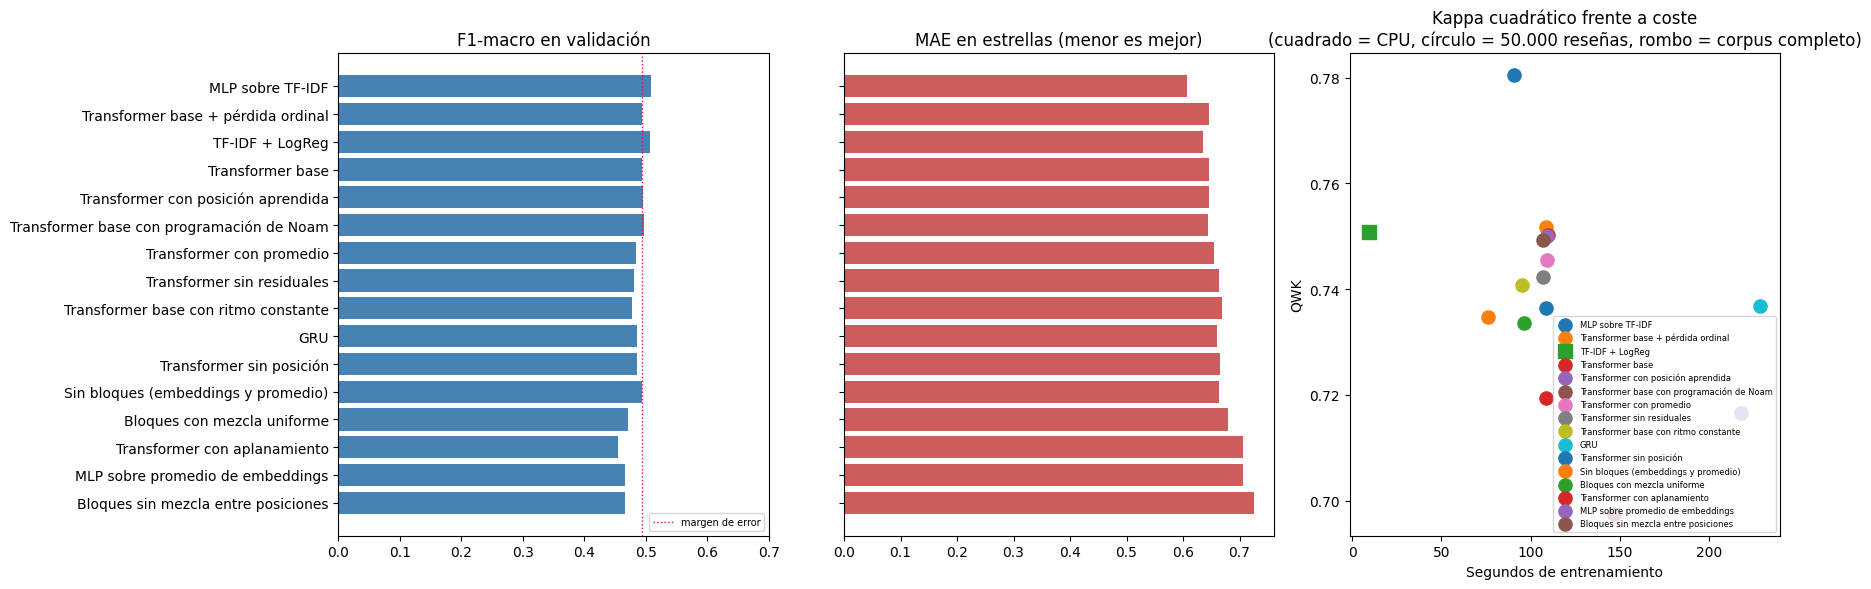

,modelo,accuracy,f1_macro,mae_estrellas,qwk,corpus,épocas,segundos,parámetros
0,MLP sobre TF-IDF,0.5175,0.5075,0.6078,0.7805,50000,6.0,90.6192,5187333.0
1,Transformer base + pérdida ordinal,0.4923,0.4930,0.6450,0.7517,50000,8.0,108.4789,2445189.0
2,TF-IDF + LogReg,0.5083,0.5061,0.6344,0.7509,50000,NaN,9.3791,NaN
3,Transformer base,0.4947,0.4940,0.6460,0.7503,50000,8.0,109.5953,2445189.0
4,Transformer con posición aprendida,0.4983,0.4951,0.6456,0.7500,50000,8.0,109.2912,2456197.0
5,Transformer base con programación de Noam,0.4967,0.4966,0.6448,0.7494,50000,8.0,106.8563,2445189.0
6,Transformer con promedio,0.4931,0.4838,0.6547,0.7456,50000,8.0,109.3040,2445189.0
7,Transformer sin residuales,0.4917,0.4809,0.6633,0.7424,50000,8.0,107.0692,2445189.0
8,Transformer base con ritmo constante,0.4881,0.4778,0.6681,0.7408,50000,7.0,95.4004,2445189.0
9,GRU,0.4817,0.4849,0.6601,0.7368,50000,21.0,229.0191,2147717.0


In [35]:
COLUMNAS_TABLA = ['modelo', 'accuracy', 'f1_macro', 'mae_estrellas', 'qwk',
                  'corpus', 'épocas', 'segundos', 'parámetros']

tabla = pd.DataFrame(resultados_val).sort_values('qwk', ascending=False).reset_index(drop=True)
orden = tabla.sort_values('qwk')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(orden['modelo'], orden['f1_macro'], color='steelblue')
axes[0].axvline(orden['f1_macro'].max() - margen_val, color='crimson', linestyle=':', linewidth=1,
                label='margen de error')
axes[0].set_title('F1-macro en validación')
axes[0].set_xlim(0, max(0.7, orden['f1_macro'].max() * 1.15))
axes[0].legend(fontsize=7, loc='lower right')

axes[1].barh(orden['modelo'], orden['mae_estrellas'], color='indianred')
axes[1].set_title('MAE en estrellas (menor es mejor)')
axes[1].set_yticklabels([])

for _, fila in tabla.iterrows():
    if pd.isna(fila['segundos']):
        continue
    # Distingo el régimen: el lineal corre en CPU y dos modelos vieron el corpus completo.
    if fila['modelo'] == 'TF-IDF + LogReg':
        marca = 's'
    elif fila['corpus'] > len(train_df):
        marca = 'D'
    else:
        marca = 'o'
    axes[2].scatter(fila['segundos'], fila['qwk'], s=90, marker=marca, label=fila['modelo'])
axes[2].set_title('Kappa cuadrático frente a coste\n'
                  '(cuadrado = CPU, círculo = 50.000 reseñas, rombo = corpus completo)')
axes[2].set_xlabel('Segundos de entrenamiento')
axes[2].set_ylabel('QWK')
axes[2].legend(fontsize=6, loc='lower right')

plt.tight_layout()
plt.show()

tabla[COLUMNAS_TABLA].round(4)

### La bolsa de palabras sigue arriba

Con 50.000 reseñas el orden por kappa cuadrático es:

| Modelo | F1-macro | MAE | QWK | Segundos |
|---|---:|---:|---:|---:|
| MLP sobre TF-IDF | **0,5075** | **0,6078** | **0,7805** | 90,6 |
| Transformer base + pérdida ordinal | 0,4930 | 0,6450 | 0,7517 | 108,5 |
| TF-IDF + LogReg | 0,5061 | 0,6344 | 0,7509 | **9,4** |
| Transformer base | 0,4940 | 0,6460 | 0,7503 | 109,6 |
| Transformer con posición aprendida | 0,4951 | 0,6456 | 0,7500 | 109,3 |
| GRU | 0,4849 | 0,6601 | 0,7368 | 229,0 |
| *(resto de variantes)* | 0,4540-0,4966 | 0,6448-0,7255 | 0,6975-0,7494 | 76,1-218,4 |

**El perceptrón sobre TF-IDF encabeza la tabla** y la mejor variante con atención queda a 0,029 de kappa. La diferencia en F1, 0,014, coincide con el margen de error; la de kappa lo supera con holgura.

Las variantes del Transformer, en cambio, **empatan con la regresión logística**: 0,7503 frente a 0,7509, seis diezmilésimas. Con 2,4 millones de parámetros y 110 segundos de GPU igualan a un modelo lineal que se entrena en 9,4 segundos de CPU. Ese es el dato incómodo, más que la distancia con el primer puesto.

Otro detalle: **el Transformer base queda por encima de la GRU**, 0,7503 frente a 0,7368, con el mismo corpus y el mismo tokenizador. En este régimen la atención rinde más que la recurrencia.

Dos matices sobre el primer puesto. Este corpus **premia la memorización léxica**: 20.000 rasgos ya ponderados capturan casi todo, y el perceptrón que los usa se satura en seis épocas. Y los modelos con embeddings aprendidos resuelven un problema más difícil, porque tienen que construir la representación antes de usarla.


### 17.1 Evolución del entrenamiento

Dibujamos las curvas a partir del CSV que registra Lightning, porque TensorBoard depende de un servidor que no siempre se restaura al reabrir el cuaderno.

Miramos las tres métricas de validación: pérdida, F1-macro y kappa, que es el que decide la parada. Separamos en dos filas los modelos sin mezcla aprendida y las variantes que sí atienden, porque con catorce curvas en un mismo panel no se distingue ninguna.

La variante con pérdida ordinal va aparte, junto a las programaciones del ritmo de aprendizaje: su pérdida no es comparable con la entropía cruzada y aplastaría la escala del eje.


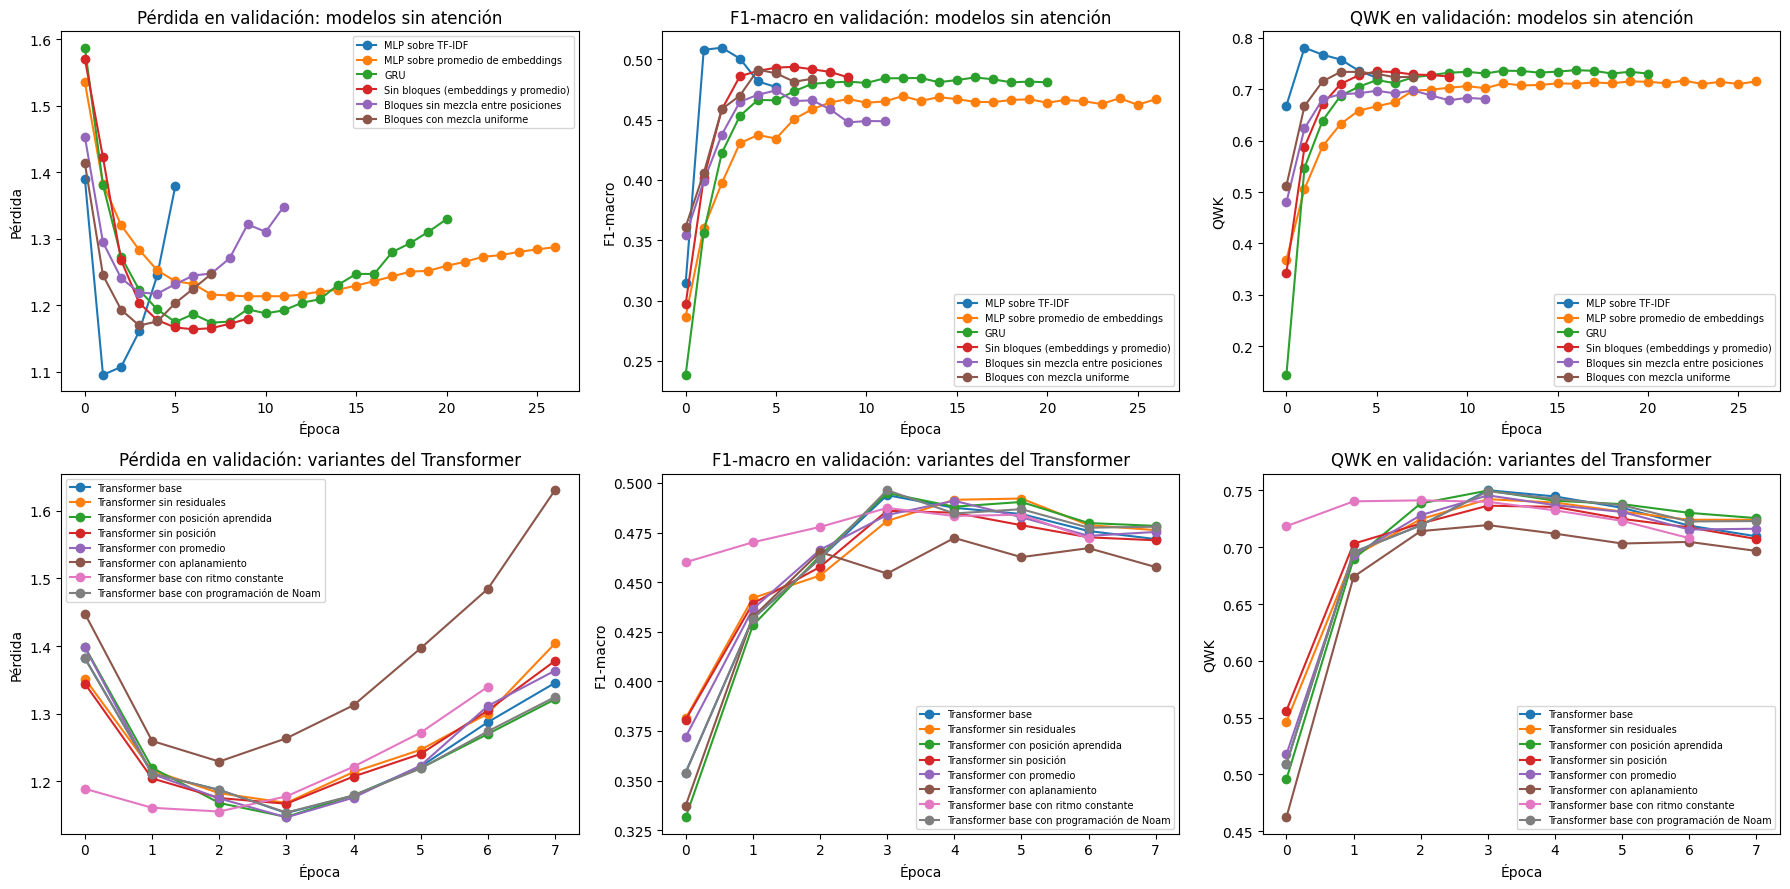

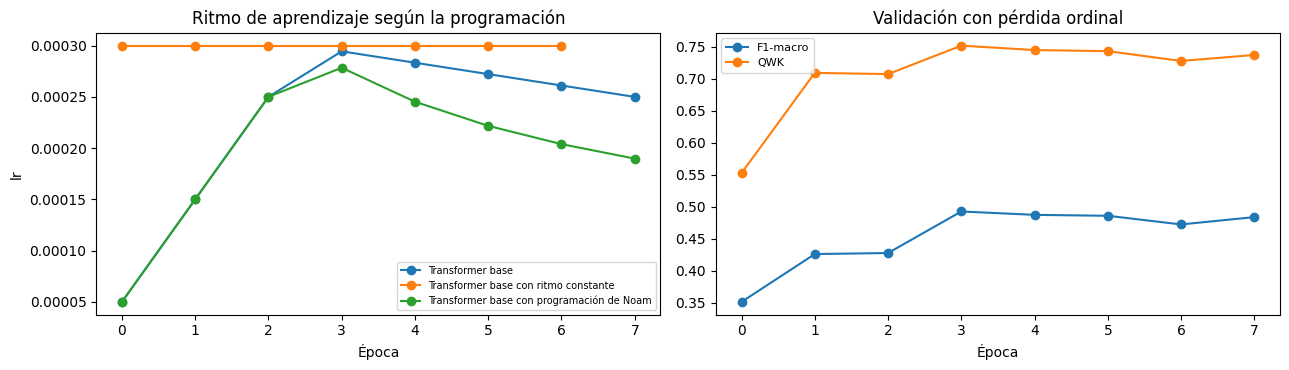

In [36]:
def leer_metricas(nombre):
    directorio = Path('csv_logs') / nombre
    if not directorio.exists():
        return None
    versiones = sorted(directorio.glob('version_*'))
    if not versiones:
        return None
    csv = versiones[-1] / 'metrics.csv'
    return pd.read_csv(csv) if csv.exists() else None


PROGRAMACIONES = ['Transformer base', 'Transformer base con ritmo constante',
                  'Transformer base con programación de Noam']

SIN_MEZCLA_APRENDIDA = ['MLP sobre TF-IDF', 'MLP sobre promedio de embeddings', 'GRU'] + ESCALERA[:-1]
CON_ATENCION = [c['nombre'] for c in CONFIGURACIONES
                if c['mezcla'] == 'atencion' and c['num_bloques'] > 0] + PROGRAMACIONES[1:]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for fila, (titulo, grupo) in enumerate([('modelos sin atención', SIN_MEZCLA_APRENDIDA),
                                        ('variantes del Transformer', CON_ATENCION)]):
    for nombre in grupo:
        metricas = leer_metricas(nombre)
        if metricas is None or 'val_loss' not in metricas.columns:
            continue
        for columna, clave in enumerate(['val_loss', 'val_f1', 'val_qwk']):
            serie = metricas.dropna(subset=[clave])
            axes[fila][columna].plot(serie['epoch'], serie[clave], marker='o', label=nombre)

    for columna, (clave, etiqueta) in enumerate([('val_loss', 'Pérdida'), ('val_f1', 'F1-macro'),
                                                 ('val_qwk', 'QWK')]):
        axes[fila][columna].set_title(f'{etiqueta} en validación: {titulo}')
        axes[fila][columna].set_xlabel('Época')
        axes[fila][columna].set_ylabel(etiqueta)
        axes[fila][columna].legend(fontsize=7)

plt.tight_layout()
plt.show()

# El ritmo de aprendizaje y la pérdida ordinal viven en otra escala: van aparte.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

for nombre in PROGRAMACIONES:
    metricas = leer_metricas(nombre)
    if metricas is None or 'lr' not in metricas.columns:
        continue
    ritmo = metricas.dropna(subset=['lr'])
    axes[0].plot(ritmo['epoch'], ritmo['lr'], marker='o', label=nombre)
axes[0].set_title('Ritmo de aprendizaje según la programación')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('lr')
axes[0].legend(fontsize=7)

ordinal = leer_metricas('Transformer base + pérdida ordinal')
if ordinal is not None:
    for clave, etiqueta in [('val_f1', 'F1-macro'), ('val_qwk', 'QWK')]:
        serie = ordinal.dropna(subset=[clave])
        axes[1].plot(serie['epoch'], serie[clave], marker='o', label=etiqueta)
axes[1].set_title('Validación con pérdida ordinal')
axes[1].set_xlabel('Época')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Las curvas explican la tabla mejor que la tabla misma.

**El perceptrón sobre TF-IDF aprende y se sobreajusta en una época.** Su pérdida toca el mínimo del cuaderno, 1,10, en la primera, y sube hasta 1,38 en la quinta. Su kappa alcanza 0,78 en esa misma primera época y ya no mejora: con 5,19 millones de pesos sobre 20.000 rasgos, memoriza el conjunto de entrenamiento.

**Todos los modelos con embeddings tocan techo entre la tercera y la sexta época.** A partir de ahí la pérdida de validación sube en todos los casos. La parada temprana los corta entre la séptima y la vigésimo séptima, pero el punto de control que se conserva es siempre muy anterior. **Con 50.000 reseñas y dos millones y medio de parámetros, el cuello de botella no es el tiempo de entrenamiento sino el sobreajuste.**

**Las ocho variantes del Transformer trazan casi la misma curva.** Bajan a un mínimo común alrededor de 1,15 en la tercera época y suben a partir de ahí. Su kappa hace lo mismo en espejo: pico cerca de 0,75 en la tercera y descenso lento. Ese apelotonamiento es en sí mismo un resultado: cambiar la posición, el resumen o la programación mueve las curvas menos que el ruido entre épocas.

Dos se separan del grupo. **Aplanamiento** es la que peor se comporta, con la pérdida subiendo hasta 1,63 porque sus parámetros extra se ajustan a posiciones concretas. **Ritmo constante** arranca por debajo de todas —empieza a aprender antes, sin la rampa del calentamiento— pero es también la primera en detenerse.

**En el grupo sin mezcla aprendida la separación es mucho mayor.** El control sin bloques y la mezcla uniforme se mantienen juntos alrededor de 1,17, mientras el peldaño sin mezcla entre posiciones se despega hacia arriba desde la cuarta época y su F1 llega a caer de 0,47 a 0,45. Ese peldaño no solo rinde menos: se deteriora con el entrenamiento. Encaja con las dos desventajas que ya le habíamos encontrado, porque un modelo al que el dropout le borra posiciones enteras y cuyo bloque colapsa en una transformación lineal tiene poco margen para seguir mejorando.


---
## 18. El efecto del volumen de datos

Toda la comparación anterior se hizo con 50.000 reseñas, diez mil por clase. El corpus depurado completo tiene casi cuatro veces más material, así que podemos medir cuánto depende cada arquitectura de la cantidad de datos en lugar de discutirlo en abstracto.

Reentrenamos sobre él las dos arquitecturas que modelan el orden —el Transformer base y la GRU— manteniendo todo lo demás idéntico: mismo tokenizador, mismo corte, mismos hiperparámetros y la misma partición de validación, de modo que las cifras sigan siendo comparables con las anteriores.

**Una asimetría que conviene anotar.** El tokenizador y el corte de longitud se aprendieron sobre el muestreo de cincuenta mil, no sobre el corpus completo, y aquí los reutilizamos tal cual. Lo hacemos así para que lo único que cambie entre los dos regímenes sea la cantidad de datos, pero significa que los modelos grandes trabajan con un vocabulario estimado sobre una cuarta parte del material que ven. Un tokenizador entrenado sobre el corpus entero probablemente fragmentaría algo menos.

El tope de épocas es menor que en el régimen pequeño porque cada una recorre cuatro veces más ejemplos, pero sigue siendo lo bastante alto como para que sea la parada temprana quien decida cuándo terminar.


In [37]:
# Menos épocas que el régimen pequeño porque cada una recorre cuatro veces más ejemplos, pero
# con la misma paciencia y un tope alto: si un modelo parase por agotar el presupuesto, la
# comparación mediría velocidad de convergencia y no calidad de la arquitectura.
MAX_EPOCAS_COMPLETO = 20

train_completo_df = preparar(sin_repetir['train'], excluir=reservados)
ds_train_completo = ResenasDataset(train_completo_df)
train_loader_completo = cargador(ds_train_completo, barajar=True)

print('Reseñas de entrenamiento:', len(train_completo_df),
      f'({len(train_completo_df) / len(train_df):.1f} veces el muestreo balanceado)')
print('Distribución por clase:')
print(train_completo_df['estrellas'].value_counts().sort_index().to_string())
print(f'Lotes por época: {len(train_loader_completo)}')

ejecutar_experimento('Transformer base (corpus completo)',
                     lambda: construir_transformer(CONFIGURACIONES[0]),
                     cargadores=(train_loader_completo, val_loader),
                     max_epocas=MAX_EPOCAS_COMPLETO)

ejecutar_experimento('GRU (corpus completo)',
                     lambda: CodificadorGRU(len(tokenizador)),
                     cargadores=(train_loader_completo, val_loader),
                     max_epocas=MAX_EPOCAS_COMPLETO)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - C

Output()

F1-macro 0.5152 | MAE 0.5968 | QWK 0.7803 | 409 s | 8 épocas (parada temprana) | 2,445,189 parámetros

GRU (corpus completo)


F1-macro 0.5237 | MAE 0.5758 | QWK 0.7955 | 481 s | 12 épocas (parada temprana) | 2,147,717 parámetros


ClasificadorResenas(
  (codificador): CodificadorGRU(
    (embedding): Embedding(16000, 128, padding_idx=1)
    (rnn): GRU(128, 128, batch_first=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (salida): Linear(in_features=128, out_features=5, bias=True)
  (f1_val): MulticlassF1Score()
  (acc_val): MulticlassAccuracy()
  (qwk_val): MulticlassCohenKappa()
)

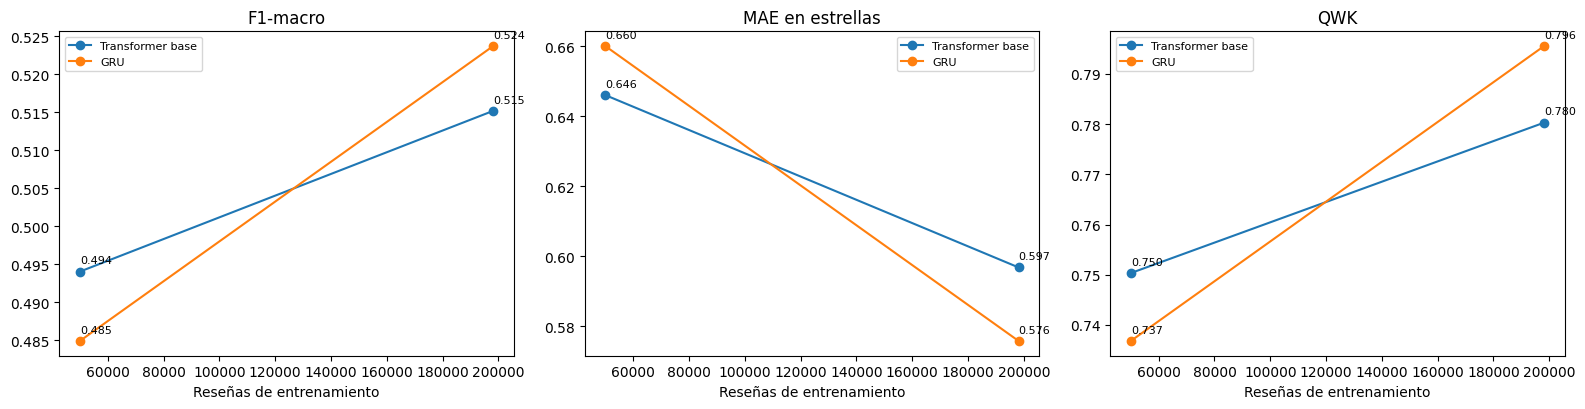

    arquitectura       métrica  con 50.000  con corpus completo  cambio
Transformer base      f1_macro      0.4940               0.5152  0.0212
Transformer base mae_estrellas      0.6460               0.5968 -0.0492
Transformer base           qwk      0.7503               0.7803  0.0299
             GRU      f1_macro      0.4849               0.5237  0.0388
             GRU mae_estrellas      0.6601               0.5758 -0.0843
             GRU           qwk      0.7368               0.7955  0.0587


In [38]:
resultados = pd.DataFrame(resultados_val).set_index('modelo')
PAREJAS = [('Transformer base', 'Transformer base (corpus completo)'),
           ('GRU', 'GRU (corpus completo)')]
TAMANOS = [len(train_df), len(train_completo_df)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for metrica, eje, titulo in zip(['f1_macro', 'mae_estrellas', 'qwk'], axes,
                                ['F1-macro', 'MAE en estrellas', 'QWK']):
    for pequeno, grande in PAREJAS:
        valores = [resultados.loc[pequeno, metrica], resultados.loc[grande, metrica]]
        eje.plot(TAMANOS, valores, marker='o', label=pequeno)
        for x, y in zip(TAMANOS, valores):
            eje.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 6), fontsize=8)
    eje.set_title(titulo)
    eje.set_xlabel('Reseñas de entrenamiento')
    eje.legend(fontsize=8)

plt.tight_layout()
plt.show()

curva = pd.DataFrame([
    {'arquitectura': pequeno,
     'métrica': metrica,
     'con 50.000': resultados.loc[pequeno, metrica],
     'con corpus completo': resultados.loc[grande, metrica],
     'cambio': resultados.loc[grande, metrica] - resultados.loc[pequeno, metrica]}
    for pequeno, grande in PAREJAS
    for metrica in ['f1_macro', 'mae_estrellas', 'qwk']
])
print(curva.round(4).to_string(index=False))

### Más datos ayudan, y ayudan más a la recurrencia

El corpus completo son **198.147 reseñas**, cuatro veces el muestreo balanceado, y viene casi equilibrado de origen.

| Arquitectura | QWK con 50.000 | QWK completo | Cambio | MAE completo |
|---|---:|---:|---:|---:|
| Transformer base | 0,7503 | 0,7803 | **+0,0300** | 0,5968 |
| GRU | 0,7368 | 0,7955 | **+0,0587** | 0,5758 |

La mejora es sustancial en los dos casos, pero desigual: la GRU gana casi el doble. **El orden entre ambas se invierte.** Con 50.000 reseñas el Transformer iba 0,0135 por delante; con el corpus completo queda 0,0152 por detrás.

El salto vale tanto como cualquier decisión de arquitectura del cuaderno. Los 0,0300 que gana el Transformer solo por ver más datos equivalen a toda la distancia que separa a la mejor de sus ocho variantes de la peor, que son 0,0309. **La cantidad de datos pesa lo mismo que todo el diseño del bloque junto.**

Con el corpus completo el Transformer (0,7803) **alcanza al perceptrón sobre TF-IDF** (0,7805), que hasta aquí había encabezado la tabla. La distancia es de dos diezmilésimas, es decir, ninguna.

Ambos pararon por parada temprana, así que ninguno se quedó a medias por falta de presupuesto. El Transformer paró antes, a las 8 épocas frente a las 12 de la GRU, recorriendo cada una cuatro veces más ejemplos que en el régimen pequeño.


---
## 19. Selección del modelo final

Seleccionamos por el mismo kappa cuadrático que ha guiado la parada temprana y el punto de control de cada entrenamiento, así que el criterio es uno solo de principio a fin.

**Seleccionamos dos modelos.** El mejor por kappa, que será el que se despliegue, y el mejor de los que llevan atención, que es el protagonista del cuaderno y el único cuyos mapas podremos inspeccionar. Ambos se eligen **mirando solo la validación**; la partición de prueba no ha intervenido en ninguna decisión.

La tabla mezcla dos regímenes de entrenamiento, así que la comparación **entre arquitecturas** solo es limpia dentro de cada uno. Para elegir qué desplegar, en cambio, lo razonable es quedarse con el mejor disponible.

**Por qué el perceptrón no pasa a prueba.** Es el mejor del régimen pequeño y entra en la selección en igualdad de condiciones, pero el criterio lo deja fuera porque dos modelos entrenados con el corpus completo lo superan en validación. Llevar a prueba un modelo que el criterio no eligió sería seleccionar dos veces, una por kappa y otra por conveniencia. Su comparación con las arquitecturas neuronales ya está hecha donde tiene sentido hacerla: sobre las mismas 50.000 reseñas y la misma partición de validación, que es el único terreno en el que los tres regímenes son comparables entre sí.


In [39]:
tabla = pd.DataFrame(resultados_val).sort_values('qwk', ascending=False).reset_index(drop=True)

candidatos = tabla[tabla['modelo'].isin(modelos)]
MEJOR_MODELO = candidatos.iloc[0]['modelo']
modelo_final = modelos[MEJOR_MODELO]

# Los nombres de las variantes con atención empiezan por 'Transformer'; los controles sin
# mezcla aprendida, no. La partición de prueba no interviene en esta elección.
con_atencion = candidatos[candidatos['modelo'].str.startswith('Transformer')]
MEJOR_TRANSFORMER = con_atencion.iloc[0]['modelo']


def cargador_de_prueba(nombre):
    # El perceptrón sobre TF-IDF consume vectores dispersos y no identificadores subword.
    return test_loader_tfidf if nombre == 'MLP sobre TF-IDF' else test_loader


print(tabla[['modelo', 'f1_macro', 'mae_estrellas', 'qwk', 'corpus', 'épocas']]
      .round(4).to_string(index=False))

for etiqueta, nombre in [('Modelo seleccionado', MEJOR_MODELO),
                         ('Mejor Transformer', MEJOR_TRANSFORMER)]:
    fila = candidatos[candidatos['modelo'] == nombre].iloc[0]
    print(f'\n{etiqueta}: {nombre}')
    print(f'  entrenado con {int(fila["corpus"])} reseñas durante {int(fila["épocas"])} épocas')


                                   modelo  f1_macro  mae_estrellas    qwk  corpus  épocas
                    GRU (corpus completo)    0.5237         0.5758 0.7955  198147    12.0
                         MLP sobre TF-IDF    0.5075         0.6078 0.7805   50000     6.0
       Transformer base (corpus completo)    0.5152         0.5968 0.7803  198147     8.0
       Transformer base + pérdida ordinal    0.4930         0.6450 0.7517   50000     8.0
                          TF-IDF + LogReg    0.5061         0.6344 0.7509   50000     NaN
                         Transformer base    0.4940         0.6460 0.7503   50000     8.0
       Transformer con posición aprendida    0.4951         0.6456 0.7500   50000     8.0
Transformer base con programación de Noam    0.4966         0.6448 0.7494   50000     8.0
                 Transformer con promedio    0.4838         0.6547 0.7456   50000     8.0
               Transformer sin residuales    0.4809         0.6633 0.7424   50000     8.0
     Trans

El criterio elige la **GRU entrenada con el corpus completo**: 0,7955 de kappa, 0,5237 de F1 y 0,5758 de MAE, con 2,15 millones de parámetros, el modelo neuronal más pequeño de los comparados. Gana también en F1, así que el criterio ordinal no entra en conflicto con el acierto exacto.

El mejor modelo con atención es el **Transformer base con el corpus completo**, con 0,7803 de kappa: tercer puesto de la tabla general y primero de su familia. Es el que llevaremos también a prueba y el que inspeccionaremos al mirar los mapas de atención.

Los separan **0,0152 de kappa**, una diferencia que el margen de error no permite declarar real. La regla nos obliga a elegir uno, pero conviene dejar constancia de que **los dos primeros puestos están empatados dentro del ruido**. Queda por ver qué ocurre con esa distancia al medirla sobre datos que ningún modelo ha visto.


---
## 20. Evaluación final sobre la partición de prueba

In [40]:
def evaluar_en_prueba(nombre):
    reales, predichas, probabilidades = predecir(modelos[nombre], cargador_de_prueba(nombre))
    return evaluar(nombre, reales, predichas), reales, predichas, probabilidades


metricas_test, y_real, y_pred, y_probs = evaluar_en_prueba(MEJOR_MODELO)
metricas_test_transformer, _, y_pred_transformer, _ = evaluar_en_prueba(MEJOR_TRANSFORMER)

COLUMNAS_PRUEBA = ['modelo', 'accuracy', 'f1_macro', 'mae_estrellas', 'qwk']
comparacion_prueba = pd.DataFrame([metricas_test, metricas_test_transformer])[COLUMNAS_PRUEBA]

print('RESULTADO EN PRUEBA')
print('-' * 78)
print(comparacion_prueba.round(4).to_string(index=False))

print(f'\nDetalle por calificación del modelo final ({MEJOR_MODELO}):\n')
print(classification_report(y_real, y_pred, labels=CLASES,
                            target_names=[f'{c} estrellas' for c in CLASES],
                            digits=4, zero_division=0))

print(f'Detalle por calificación del mejor Transformer ({MEJOR_TRANSFORMER}):\n')
print(classification_report(y_real, y_pred_transformer, labels=CLASES,
                            target_names=[f'{c} estrellas' for c in CLASES],
                            digits=4, zero_division=0))


RESULTADO EN PRUEBA
------------------------------------------------------------------------------
                            modelo  accuracy  f1_macro  mae_estrellas    qwk
             GRU (corpus completo)    0.5360    0.5347         0.5643 0.7986
Transformer base (corpus completo)    0.5471    0.5459         0.5529 0.8008

Detalle por calificación del modelo final (GRU (corpus completo)):

              precision    recall  f1-score   support

 1 estrellas     0.6689    0.6950    0.6817      1000
 2 estrellas     0.4570    0.4845    0.4704       999
 3 estrellas     0.4483    0.4250    0.4363      1000
 4 estrellas     0.4664    0.4374    0.4514       999
 5 estrellas     0.6291    0.6386    0.6338       996

    accuracy                         0.5360      4994
   macro avg     0.5339    0.5361    0.5347      4994
weighted avg     0.5339    0.5360    0.5347      4994

Detalle por calificación del mejor Transformer (Transformer base (corpus completo)):

              precision   

### Lectura del resultado final

| Modelo | Accuracy | F1-macro | MAE | QWK |
|---|---:|---:|---:|---:|
| GRU (corpus completo) | 0,5360 | 0,5347 | 0,5643 | 0,7986 |
| Transformer base (corpus completo) | **0,5471** | **0,5459** | **0,5529** | **0,8008** |

**En prueba el orden se invierte: el Transformer queda por delante en las cuatro métricas.** Gana 0,0111 de acierto, 0,0112 de F1, 0,0114 estrellas de MAE y 0,0022 de kappa.

Conviene decir con claridad qué significa y qué no. **Todas esas diferencias son menores que el margen de error**, igual que lo eran las de validación. Lo que muestra el conjunto de las dos particiones no es que una arquitectura supere a la otra, sino que **con este corpus las dos rinden lo mismo** y cuál queda arriba depende de sobre qué 5.000 reseñas se mida.

Mantenemos la GRU como modelo final. Cambiar la elección ahora significaría seleccionar con la partición de prueba, que es justo lo que la separación de particiones existe para impedir. La conclusión defendible es que **la selección por validación no perdió nada**: el modelo elegido y el descartado son equivalentes.

El otro dato es la estabilidad. La GRU pasa de 0,7955 a 0,7986 y el Transformer de 0,7803 a 0,8008. Los dos suben, así que **la validación no quedó sobreajustada por haberse usado en la selección**; el Transformer sube más, lo que sugiere que su cifra de validación era la más pesimista de las dos.

Desglose por clase de las dos arquitecturas, en F1:

| Calificación | GRU | Transformer |
|---|---:|---:|
| 1 estrella | 0,6817 | **0,6868** |
| 2 estrellas | 0,4704 | **0,4930** |
| 3 estrellas | 0,4363 | **0,4470** |
| 4 estrellas | **0,4514** | 0,4460 |
| 5 estrellas | 0,6338 | **0,6567** |

**Los extremos se resuelven unos veinte puntos mejor que el centro** en los dos modelos, igual que anticipaba el índice de Jaccard. La clase de tres estrellas es la peor de las cinco: su vocabulario está hecho de matizadores en lugar de palabras de valoración.

El Transformer gana en cuatro de las cinco clases y la única donde pierde, cuatro estrellas, revela una diferencia de estilo. Ahí tiene bastante más precisión que la GRU (0,5130 frente a 0,4664) y bastante menos recall (0,3944 frente a 0,4374): **reparte menos cuatros, pero acierta más cuando los da**. En dos estrellas ocurre lo contrario.


### 20.1 Por qué el Transformer no encabeza la tabla

**Lo primero es acotar de cuánto hablamos.** El Transformer no queda descolgado: con el corpus completo llega a 0,7803 de kappa en validación frente a los 0,7805 del perceptrón sobre TF-IDF, y en prueba queda por delante de la GRU en las cuatro métricas. Lo que hay que explicar no es una derrota, sino que **una arquitectura de 2,4 millones de parámetros empate con una bolsa de palabras que se entrena en nueve segundos de CPU**.

**1. El techo lo pone la tarea.** Los dieciocho modelos comparados en validación caben entre 0,6975 y 0,7955 de kappa, menos de diez centésimas. La auditoría inicial ya explicaba parte de ese techo: hay 398 textos que aparecen con más de una calificación, así que la etiqueta no es una función del texto. Cuando el margen disponible es tan estrecho, las diferencias de diseño se comprimen contra él.

**2. Este corpus se resuelve sobre todo con vocabulario.** La mediana de las reseñas es de veintiséis tokens y las palabras que cargan la opinión suelen estar a la vista. La escalera lo cuantifica en su tramo comparable: que la mezcla se aprenda del contenido en lugar de repartirse por igual vale 0,0120 de kappa. La atención funciona, pero el margen que le deja el problema es pequeño.

**3. Los embeddings hay que aprenderlos desde cero.** El 84% de los parámetros del Transformer está en la tabla de embeddings, y esos vectores se construyen solo con las reseñas del entrenamiento. Los 20.000 rasgos de TF-IDF llegan ya ponderados por su frecuencia en el corpus. **No es una comparación entre dos arquitecturas, sino entre una que recibe la representación hecha y otra que debe fabricarla.**

**4. Con 50.000 reseñas se sobreajusta en tres épocas.** La pérdida de validación de todas las variantes toca el mínimo en la tercera época y sube a partir de ahí. El modelo tiene capacidad de sobra y datos de menos, y el punto de control que se conserva es siempre muy temprano.

**5. Los datos importan tanto como el diseño.** Cuadruplicar el corpus le da al Transformer 0,0300 de kappa, tanto como toda la distancia que separa a la mejor de sus ocho variantes de la peor. **La palanca más fuerte del cuaderno no fue ninguna decisión de arquitectura.**

**6. Nuestro modelo es mucho más pequeño que el del artículo.** Usamos dos bloques, 128 dimensiones y cuatro cabezas, frente a los seis bloques, 512 dimensiones y ocho cabezas del original, y entrenamos con un corpus varios órdenes de magnitud menor. La arquitectura está completa, pero a una escala en la que sus ventajas no se manifiestan.

En resumen, el Transformer hace aquí lo que puede hacer: **necesita datos para construir su representación, y este problema no le pide casi nada de lo que sabe hacer mejor**.


---
## 21. Dónde se equivoca el modelo

Las métricas agregadas dicen cuánto falla, no dónde. La matriz de confusión normalizada por fila reparte los errores de cada calificación real entre las cinco posibles, que es lo que permite contrastarlos con el solapamiento de vocabulario medido en el análisis exploratorio.

Añadimos la distribución del error con signo, para ver si el modelo es sistemáticamente optimista o pesimista.


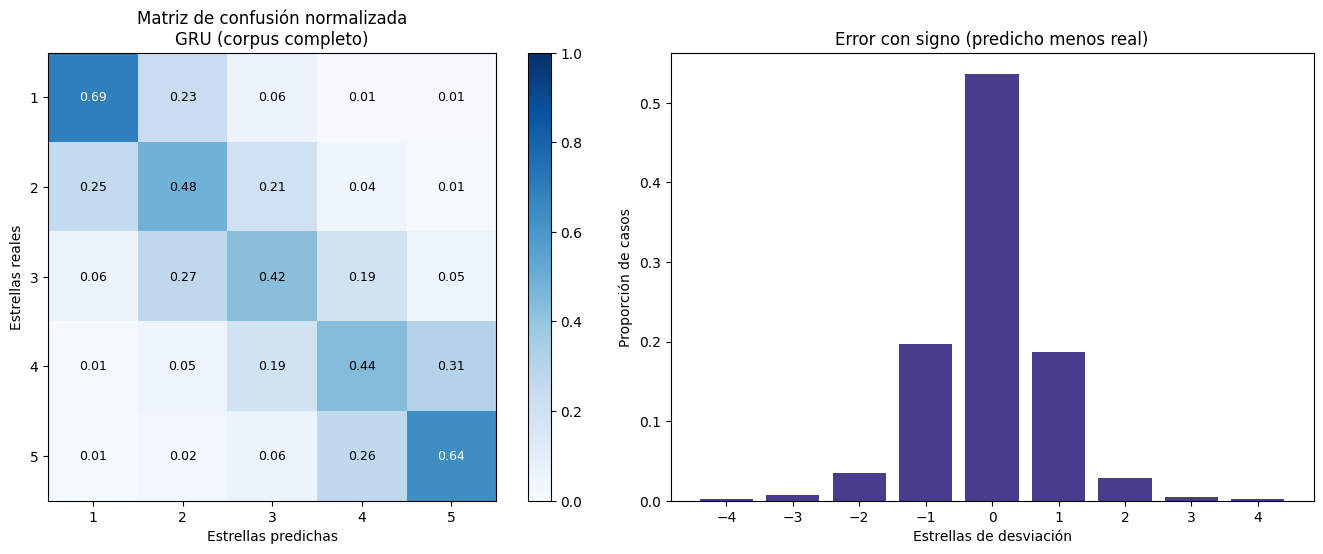

Aciertos exactos:                   53.6%
Dentro de una estrella de margen:   92.0%
Errores graves (2 o más estrellas): 8.0%
Sesgo medio del modelo:             -0.034 estrellas


In [41]:
matriz = confusion_matrix(y_real, y_pred, labels=CLASES)
matriz_norm = matriz / matriz.sum(axis=1, keepdims=True)
error_con_signo = y_pred - y_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

im = axes[0].imshow(matriz_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(NUM_CLASES), CLASES)
axes[0].set_yticks(range(NUM_CLASES), CLASES)
axes[0].set_xlabel('Estrellas predichas')
axes[0].set_ylabel('Estrellas reales')
axes[0].set_title(f'Matriz de confusión normalizada\n{MEJOR_MODELO}')
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        axes[0].text(j, i, f'{matriz_norm[i, j]:.2f}', ha='center', va='center',
                     color='white' if matriz_norm[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=axes[0])

valores, cuentas = np.unique(error_con_signo, return_counts=True)
axes[1].bar(valores, cuentas / cuentas.sum(), color='darkslateblue')
axes[1].set_title('Error con signo (predicho menos real)')
axes[1].set_xlabel('Estrellas de desviación')
axes[1].set_ylabel('Proporción de casos')
axes[1].set_xticks(valores)

plt.tight_layout()
plt.show()

exactos = (error_con_signo == 0).mean()
vecinos = (np.abs(error_con_signo) <= 1).mean()
graves = (np.abs(error_con_signo) >= 2).mean()

print(f'Aciertos exactos:                   {exactos:.1%}')
print(f'Dentro de una estrella de margen:   {vecinos:.1%}')
print(f'Errores graves (2 o más estrellas): {graves:.1%}')
print(f'Sesgo medio del modelo:             {error_con_signo.mean():+.3f} estrellas')

La matriz reproduce el mismo patrón que el índice de Jaccard del análisis exploratorio.

**Casi toda la masa de error está pegada a la diagonal**, que recorre 0,69 / 0,48 / 0,42 / 0,44 / 0,64. La confusión más frecuente es cuatro clasificadas como cinco (31%), seguida de tres como dos (27%) y cinco como cuatro (26%). Las parejas que más se confunden son justo las que compartían más vocabulario: 2–3 y 3–4.

**Las confusiones entre extremos opuestos son del 1%.** El modelo distingue de qué lado está la opinión; lo que no consigue es calibrar la intensidad.

Tres números resumen el comportamiento: **acierto exacto 53,6%**, **dentro de una estrella 92,0%**, **desviación de dos o más 8,0%**. Ese 92,0% no aparece en ninguna métrica estándar y es la cifra más útil para juzgar si el sistema serviría para ordenar opiniones o priorizar revisiones.

El histograma de error con signo es **casi simétrico**: un 19,7% en −1 frente a un 18,7% en +1, con un sesgo medio de **−0,034 estrellas**. Importa porque un sesgo sistemático distorsionaría cualquier promedio por producto; tres centésimas de estrella en contra son despreciables a efectos prácticos.


### 21.1 Los errores en detalle

Miramos tres cosas: los errores graves cometidos con más confianza, la relación entre confianza y acierto, y el desempeño por longitud de la reseña.

Lo último sirve para evaluar el corte de secuencias en 86 tokens: el cuarto tramo es el único que contiene reseñas truncadas, así que comparar su acierto con el de los demás indica si el corte está costando algo.


In [42]:
analisis = test_df.copy()

# El cargador de prueba no baraja, así que las predicciones deben venir en el orden del dataframe.
assert (y_real == analisis['estrellas'].to_numpy()).all(), 'Las predicciones no están alineadas'

analisis['prediccion'] = y_pred
analisis['confianza'] = y_probs.max(axis=1)
analisis['desviacion'] = y_pred - analisis['estrellas']
analisis['acierto'] = analisis['desviacion'] == 0
analisis['n_tokens'] = [len(ids) for ids in tokenizador(test_df['text'].tolist())['input_ids']]

graves_df = analisis[analisis['desviacion'].abs() >= 2].sort_values('confianza', ascending=False)

print(f'Errores graves: {len(graves_df)} de {len(analisis)}\n')
for _, fila in graves_df.head(4).iterrows():
    print(f"Real {fila['estrellas']} -> predicho {fila['prediccion']} "
          f"(confianza {fila['confianza']:.1%})")
    print('  ', fila['text'][:260].replace('\n', ' '))
    print()

Errores graves: 400 de 4994

Real 3 -> predicho 1 (confianza 94.2%)
   Son corrientes. Varios rotos, con agujero, y casi todos se desinchan al cabo de 2 horas. El brillo del anuncio no es real. Muy descontento con el producto. Asegura vendedor que incrementará su control de calidad. Efectúa reembolso total.

Real 3 -> predicho 1 (confianza 91.4%)
   El producto no llegó en el tiempo indicado, exactamente 24 días después, es lamentable que pasen estas cosas, ya no me sirve el producto para la fecha en la que ha llegado.

Real 3 -> predicho 5 (confianza 91.0%)
   Me ha encantado, es súper comoda Mi bebe tiene 9 meses, y es perfecta para ella, y muy segura. Va contenta cuando la paseo.

Real 3 -> predicho 5 (confianza 87.0%)
   Buena botella de agua, tal y como se ve en las fotos. Amplia capacidad, 2,2 litros. Con su asa de plástico para cogerla, su tapón ajustable y su correa arriba para que no se le pierda el tapón. La compré para mi padre, quería una botella que fuera de buen mate



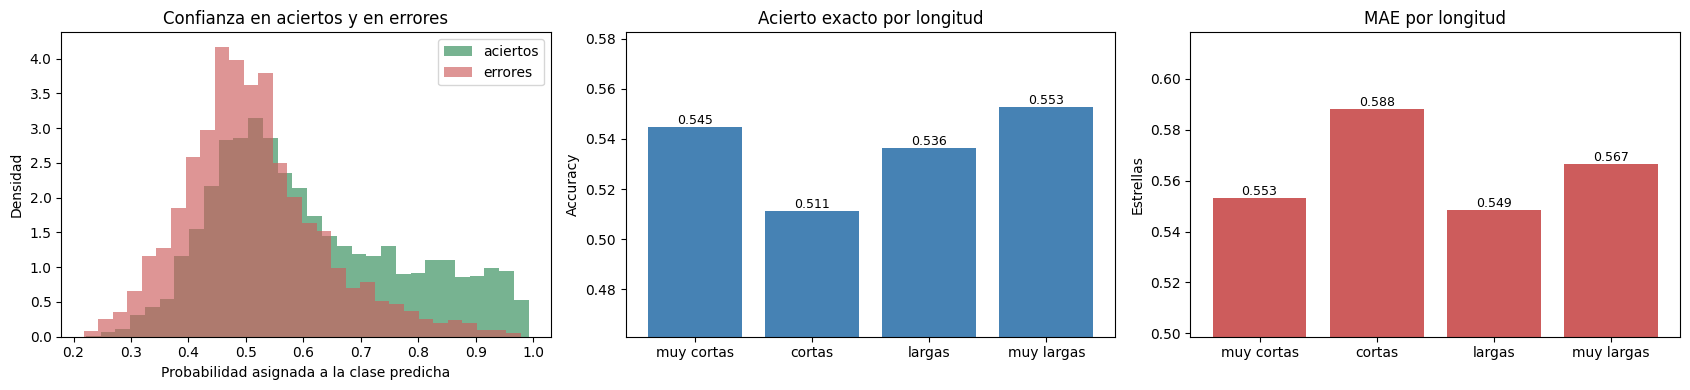

Confianza media en aciertos: 0.61
Confianza media en errores:  0.514

            casos  accuracy    mae  truncadas
tramo                                        
muy cortas   1296     0.545  0.553      0.000
cortas       1268     0.511  0.588      0.000
largas       1212     0.536  0.549      0.000
muy largas   1218     0.553  0.567      0.185


In [43]:
analisis['tramo'] = pd.qcut(analisis['n_tokens'], 4,
                            labels=['muy cortas', 'cortas', 'largas', 'muy largas'])

resumen_tramo = analisis.groupby('tramo', observed=True).agg(
    casos=('acierto', 'size'),
    accuracy=('acierto', 'mean'),
    mae=('desviacion', lambda s: s.abs().mean()),
    truncadas=('n_tokens', lambda s: (s > MAX_LEN - 1).mean()),
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(analisis.loc[analisis['acierto'], 'confianza'], bins=30, alpha=0.65,
             label='aciertos', color='seagreen', density=True)
axes[0].hist(analisis.loc[~analisis['acierto'], 'confianza'], bins=30, alpha=0.65,
             label='errores', color='indianred', density=True)
axes[0].set_title('Confianza en aciertos y en errores')
axes[0].set_xlabel('Probabilidad asignada a la clase predicha')
axes[0].set_ylabel('Densidad')
axes[0].legend()

etiquetas = resumen_tramo.index.astype(str)

# Acoto los ejes: con origen en cero las diferencias entre tramos serían invisibles.
axes[1].bar(etiquetas, resumen_tramo['accuracy'], color='steelblue')
axes[1].set_ylim(resumen_tramo['accuracy'].min() - 0.05, resumen_tramo['accuracy'].max() + 0.03)
axes[1].set_title('Acierto exacto por longitud')
axes[1].set_ylabel('Accuracy')

axes[2].bar(etiquetas, resumen_tramo['mae'], color='indianred')
axes[2].set_ylim(resumen_tramo['mae'].min() - 0.05, resumen_tramo['mae'].max() + 0.03)
axes[2].set_title('MAE por longitud')
axes[2].set_ylabel('Estrellas')

for eje, columna in zip(axes[1:], ['accuracy', 'mae']):
    for i, valor in enumerate(resumen_tramo[columna]):
        eje.text(i, valor, f'{valor:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Confianza media en aciertos:', round(analisis.loc[analisis['acierto'], 'confianza'].mean(), 3))
print('Confianza media en errores: ', round(analisis.loc[~analisis['acierto'], 'confianza'].mean(), 3))
print()
print(resumen_tramo.round(3).to_string())

### Los errores graves más confiados están todos en la misma clase

De las 4.994 reseñas de prueba, **400 se desvían dos o más estrellas**. Los cuatro que falla con mayor confianza tienen algo en común: **los cuatro están calificados con tres estrellas**, y dos apuntan a cada extremo.

Hacia abajo: *"Varios rotos, con agujero… Muy descontento con el producto"*, clasificada como 1 con un 94,2%, y *"El producto no llegó en el tiempo indicado, exactamente 24 días después, es lamentable"*, también como 1 con un 91,4%. Hacia arriba: *"Me ha encantado, es súper cómoda… Va contenta cuando la paseo"*, clasificada como 5 con un 91,0%, y *"Buena botella de agua, tal y como se ve en las fotos"*, como 5 con un 87,0%.

**El modelo lee bien los cuatro textos.** Lo que no puede recuperar es por qué quien los escribió puso tres estrellas. En el primero la propia reseña da una pista —menciona que el vendedor reembolsó—, pero esa información no está en el vocabulario de valoración y exige razonar sobre la resolución del incidente, no sobre el producto.

Parte de ese 8,0% de errores graves no mide un fallo del modelo sino **ruido en la etiqueta**, y se concentra en la clase central que ya era la peor de las cinco. La auditoría inicial lo había adelantado al encontrar textos idénticos con calificaciones distintas. Ninguna arquitectura resuelve eso.

**La confianza es informativa**: 0,610 de media en los aciertos frente a 0,514 en los errores. Por debajo de 0,6 las dos densidades se superponen, pero a partir de 0,7 domina la de los aciertos, así que un umbral ahí separaría un subconjunto casi limpio. Los cuatro casos anteriores son la excepción: fallos con más del 87% de confianza que ningún umbral filtraría.

### La longitud no perjudica

El acierto por tramos es 0,545 / 0,511 / 0,536 / **0,553** y el MAE 0,553 / **0,588** / 0,549 / 0,567. El mejor tramo y el peor se separan cuatro puntos, y el peor no es el de las reseñas largas sino el segundo.

El dato relevante es que el cuarto tramo es el único con truncamiento —**el 18,5% de sus reseñas supera los 86 tokens**— y aun así obtiene el mejor acierto de los cuatro. El corte en 86 no cuesta desempeño medible en el agregado.


---
## 22. Qué mira el modelo: los mapas de atención

Los pesos de atención son probabilidades y se pueden leer: dicen cuánto contribuyó cada token a la representación de cada otro.

La escalera de controles midió **cuánto** aporta que los pesos se aprendan, pero no **en qué** se traduce. Los mapas permiten mirar directamente dónde acaba poniendo el peso un modelo que solo ha recibido identificadores numéricos y una nota de una a cinco estrellas.

Trabajamos sobre el **Transformer base** entrenado con 50.000 reseñas, que es la configuración de la que salen todas las ablaciones, y sobre la **partición de validación**, porque los ejemplos se eligen mirando resultados. Miramos tres cosas: el mapa completo de una reseña corta cabeza por cabeza, la fila del token de resumen —que es la que determina la clasificación— y si alguna cabeza se especializa en negaciones y adversativos.


In [ ]:
modelo_atencion = modelos['Transformer base']


def tokens_legibles(ids):
    piezas = tokenizador.convert_ids_to_tokens(list(ids))
    return [tokenizador.convert_tokens_to_string([p]).strip() or p for p in piezas]


@torch.no_grad()
def analizar_atencion(texto, modelo=None):
    modelo = modelo or modelo_atencion
    modelo.eval().to(DEVICE)
    ids, mascara = codificar([texto])
    logits, pesos = modelo(ids.to(DEVICE), mascara.to(DEVICE))

    largo = int(mascara[0].sum())
    tokens = tokens_legibles(ids[0, :largo].tolist())
    tokens[0] = '[CLS]'
    mapas = [p[0, :, :largo, :largo].float().cpu().numpy() for p in pesos]
    probs = torch.softmax(logits.float(), dim=1)[0].cpu().numpy()
    return tokens, mapas, probs


def dibujar_mapas(texto, bloque=-1, modelo=None):
    tokens, mapas, probs = analizar_atencion(texto, modelo)
    mapa = mapas[bloque]
    num_cabezas = mapa.shape[0]

    fig, axes = plt.subplots(1, num_cabezas, figsize=(4.2 * num_cabezas, 4.6))
    for cabeza, eje in enumerate(axes):
        eje.imshow(mapa[cabeza], cmap='viridis', vmin=0)
        eje.set_xticks(range(len(tokens)), tokens, rotation=90, fontsize=6)
        eje.set_yticks(range(len(tokens)), tokens, fontsize=6)
        eje.set_title(f'Cabeza {cabeza + 1}', fontsize=10)
    fig.suptitle(f'Atención del bloque {bloque if bloque >= 0 else len(mapas)} | '
                 f'predicción: {int(np.argmax(probs)) + 1} estrellas ({probs.max():.0%})')
    plt.tight_layout()
    plt.show()
    return tokens, mapa, probs


def dibujar_atencion_resumen(texto, estrellas_reales=None, bloque=-1, modelo=None):
    tokens, mapas, probs = analizar_atencion(texto, modelo)
    fila_resumen = mapas[bloque][:, 0, :]
    num_cabezas = fila_resumen.shape[0]

    fig, ax = plt.subplots(figsize=(min(15, 0.55 * len(tokens) + 3), 4))
    ancho = 0.8 / num_cabezas
    posiciones = np.arange(len(tokens))
    for cabeza in range(num_cabezas):
        ax.bar(posiciones + cabeza * ancho, fila_resumen[cabeza], width=ancho,
               label=f'cabeza {cabeza + 1}')
    ax.set_xticks(posiciones + 0.4 - ancho / 2, tokens, rotation=75, ha='right', fontsize=8)
    encabezado = f'Predicción: {int(np.argmax(probs)) + 1} estrellas (confianza {probs.max():.1%})'
    if estrellas_reales is not None:
        encabezado += f' | Real: {estrellas_reales}'
    ax.set_title(f'Atención del token de resumen hacia cada palabra\n{encabezado}')
    ax.set_ylabel('Peso de atención')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    promedio = fila_resumen.mean(axis=0)
    relevantes = sorted(zip(tokens, promedio), key=lambda par: par[1], reverse=True)[:8]
    print('Palabras más atendidas (promedio de las cabezas):')
    print('  ' + ', '.join(f'{t} ({p:.1%})' for t, p in relevantes))
    return tokens, fila_resumen, probs

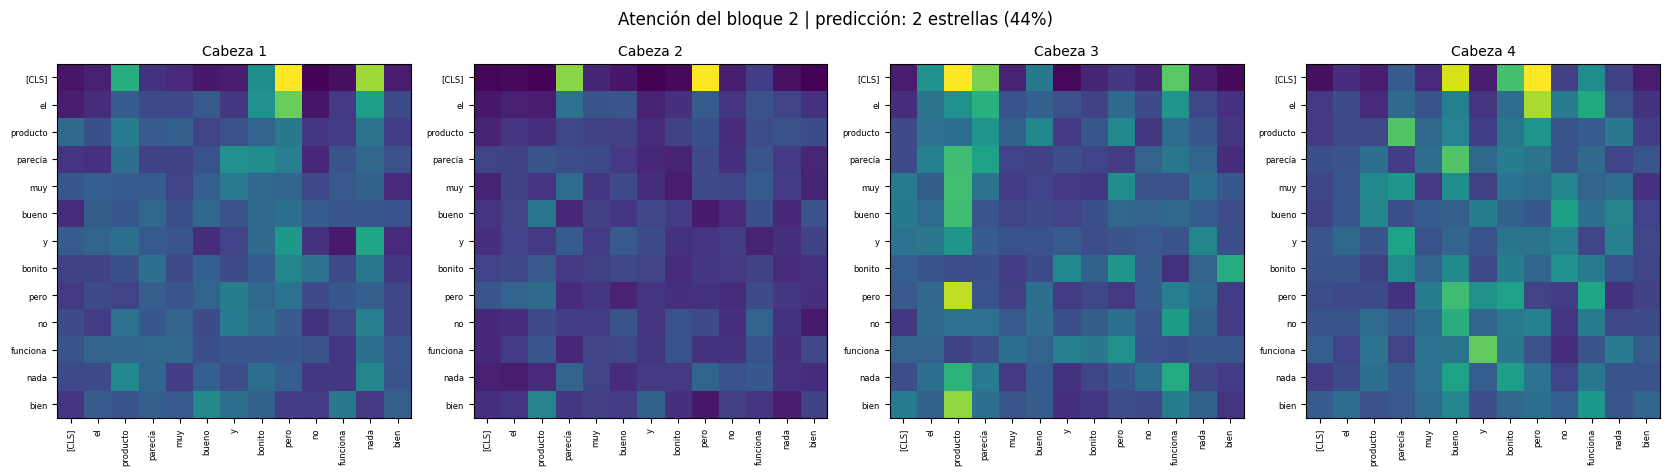

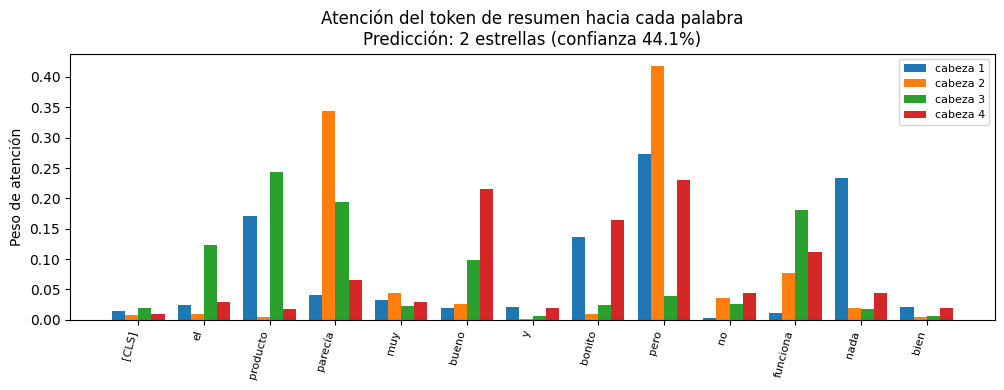

Palabras más atendidas (promedio de las cabezas):
  pero (24.0%), parecía (16.1%), producto (10.9%), funciona (9.5%), bueno (9.0%), bonito (8.4%), nada (7.9%), el (4.6%)


(['[CLS]',
  'el',
  'producto',
  'parecía',
  'muy',
  'bueno',
  'y',
  'bonito',
  'pero',
  'no',
  'funciona',
  'nada',
  'bien'],
 array([[0.01438795, 0.02369254, 0.17142329, 0.04022039, 0.03265187,
         0.01901644, 0.0205036 , 0.13605395, 0.2732899 , 0.00295964,
         0.01113648, 0.2340922 , 0.02057177],
        [0.00749058, 0.01017417, 0.00439323, 0.3431076 , 0.04375046,
         0.02516325, 0.00200715, 0.00985655, 0.41755474, 0.03558876,
         0.07668053, 0.01945136, 0.00478161],
        [0.01884337, 0.12275118, 0.24315937, 0.19399944, 0.02324657,
         0.09840247, 0.00568202, 0.02513186, 0.03848195, 0.02548801,
         0.18061927, 0.01846279, 0.00573175],
        [0.00956222, 0.02931266, 0.01851641, 0.06618758, 0.02871951,
         0.21611789, 0.01880775, 0.16362517, 0.23019317, 0.04390267,
         0.11194512, 0.0445572 , 0.01855262]], dtype=float32),
 array([0.137315  , 0.44053087, 0.33829176, 0.07153311, 0.0123293 ],
       dtype=float32))

In [45]:
# La negación al final invierte el sentido de todo lo anterior.
FRASE_NEGACION = 'el producto parecía muy bueno y bonito pero no funciona nada bien'

dibujar_mapas(FRASE_NEGACION)
dibujar_atencion_resumen(FRASE_NEGACION)

### El token de resumen se lleva el foco

**La fila superior, la del `[CLS]`, es la que concentra el contraste.** El resto forman un mosaico difuso, mientras que la del token de resumen tiene celdas bien localizadas. Tiene sentido: solo esa fila llega al clasificador, así que es la única que recibe presión directa del gradiente.

**El modelo resuelve la frase difícil, aunque sin seguridad.** Para *"el producto parecía muy bueno y bonito pero no funciona nada bien"* predice **2 estrellas con un 44,1%**, con un 33,8% en tres y un 13,7% en una: **el 58% de la probabilidad cae en el lado negativo** pese a que las palabras positivas son mayoría.

**La atención se concentra en la palabra que marca el giro.** El promedio de las cuatro cabezas pone el **24,0% en `pero`**, la más atendida con diferencia, seguida de `parecía` con el 16,1%. Las dos señalan la bisagra de la frase, no su contenido evaluativo.

| Cabeza | Dónde pone el peso |
|---|---|
| 1 | **`pero` 27,3%**, `nada` 23,4%, `producto` 17,1% |
| 2 | **`pero` 41,8%**, `parecía` 34,3% |
| 3 | `producto` 24,3%, `parecía` 19,4%, `funciona` 18,1% |
| 4 | **`pero` 23,0%**, `bueno` 21,6%, `bonito` 16,4% |

Tres de las cuatro cabezas ponen `pero` en primer o segundo lugar. La cabeza 4 es la única que atiende con fuerza a las palabras positivas, `bueno` y `bonito`, y la 3 se reparte entre el sujeto y el verbo. **Entre las cuatro tienen delante las dos mitades de la contraposición y el punto donde se separan.**

Un detalle del mapa completo: en la cabeza 3 la columna de `producto` está iluminada en casi todas las filas, no solo en la del `[CLS]`. Esa cabeza no reparte según quién pregunta, sino que lleva casi todas las posiciones hacia el mismo sitio.


CASO BIEN RESUELTO POR EL TRANSFORMER
  No compréis este producto que es de mala calidad es gastar dinero para nada deberían prohibir vender este tipos de productos de mala calidad


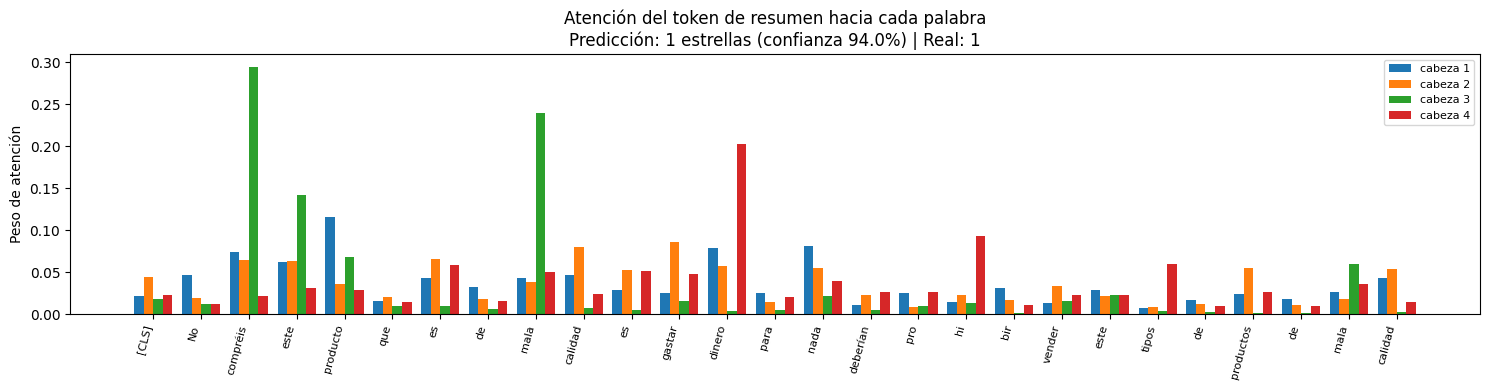

Palabras más atendidas (promedio de las cabezas):
  compréis (11.4%), mala (9.3%), dinero (8.6%), este (7.5%), producto (6.2%), nada (4.9%), es (4.4%), gastar (4.4%)

CASO MAL RESUELTO POR EL TRANSFORMER
  No lleva conexión para el mando de la ps4 hay que conectarlo a la consola .


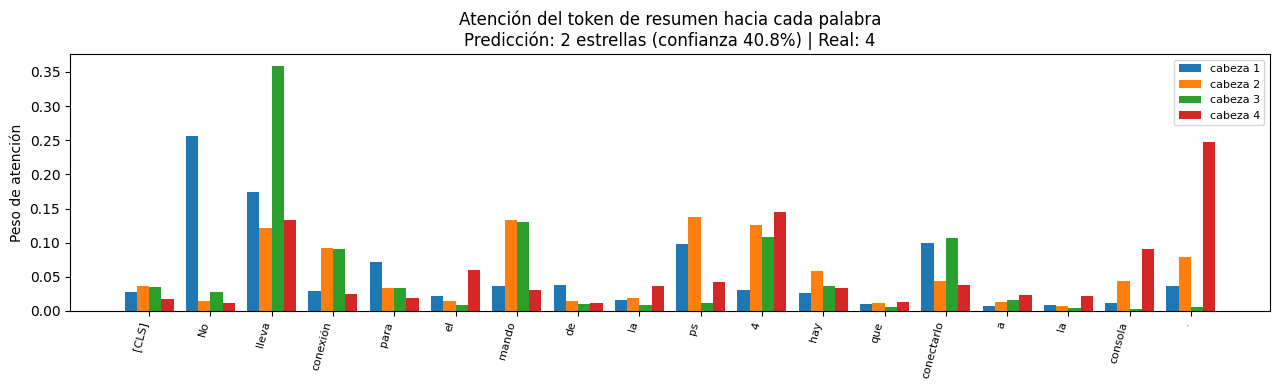

Palabras más atendidas (promedio de las cabezas):
  lleva (19.7%), 4 (10.3%), . (9.2%), mando (8.2%), No (7.8%), ps (7.2%), conectarlo (7.2%), conexión (5.9%)


(['[CLS]',
  'No',
  'lleva',
  'conexión',
  'para',
  'el',
  'mando',
  'de',
  'la',
  'ps',
  '4',
  'hay',
  'que',
  'conectarlo',
  'a',
  'la',
  'consola',
  '.'],
 array([[0.02701679, 0.25566933, 0.17450237, 0.02971892, 0.07118281,
         0.02235593, 0.03580592, 0.03767943, 0.01582601, 0.09846859,
         0.03072871, 0.02692542, 0.00960756, 0.09958878, 0.0072469 ,
         0.00897815, 0.01199181, 0.03670656],
        [0.03720963, 0.01521192, 0.12112013, 0.0914807 , 0.03293296,
         0.01516027, 0.13337731, 0.01458983, 0.01848939, 0.1381892 ,
         0.12534024, 0.05870973, 0.0121626 , 0.04363452, 0.01287024,
         0.00673967, 0.04426375, 0.07851798],
        [0.03557919, 0.02784214, 0.35801587, 0.09137507, 0.03352093,
         0.00833847, 0.12984478, 0.0096739 , 0.00800437, 0.01113889,
         0.10869931, 0.03654044, 0.00520155, 0.10685595, 0.01564577,
         0.00446886, 0.00339965, 0.00585484],
        [0.01754769, 0.01179152, 0.13318643, 0.02499478, 0.01894614

In [46]:
# Los ejemplos se eligen por los aciertos del propio Transformer y sobre validación:
# usar los del modelo final mostraría la atención de un modelo distinto al que decide.
reales_val, predichas_val, _ = predecir(modelo_atencion, val_loader)

atencion_val = val_df.copy()
atencion_val['prediccion'] = predichas_val
atencion_val['desviacion'] = predichas_val - atencion_val['estrellas']
atencion_val['n_tokens'] = [len(ids) for ids in tokenizador(val_df['text'].tolist())['input_ids']]

breves = atencion_val[atencion_val['n_tokens'].between(10, 30)]
ejemplo_acierto = breves[breves['desviacion'] == 0].iloc[0]
ejemplo_error = breves[breves['desviacion'].abs() >= 2].iloc[0]

print('CASO BIEN RESUELTO POR EL TRANSFORMER')
print(' ', ejemplo_acierto['text'])
dibujar_atencion_resumen(ejemplo_acierto['text'], ejemplo_acierto['estrellas'])

print('\nCASO MAL RESUELTO POR EL TRANSFORMER')
print(' ', ejemplo_error['text'])
dibujar_atencion_resumen(ejemplo_error['text'], ejemplo_error['estrellas'])

### Cuando la negación basta y cuando engaña

**El caso bien resuelto es el escenario favorable.** En *"No compréis este producto que es de mala calidad es gastar dinero para nada…"* acierta la única estrella real con un **94,0% de confianza**, repartiendo la atención entre `compréis` (11,4%), `mala` (9,3%), `dinero` (8,6%) y `nada` (4,9%).

Cada cabeza aporta algo distinto: la 3 vuelca el **29,5%** sobre `compréis` y otro **24,0%** sobre la primera aparición de `mala`; la 4 pone el **20,3%** sobre `dinero`; la 1 se queda en `producto`; y la 2 reparte de forma bastante plana. Aquí la negación, el adjetivo y el verbo apuntan en la misma dirección, así que detectar su presencia basta.

**El caso mal resuelto muestra el límite exacto del mecanismo.** *"No lleva conexión para el mando de la ps4 hay que conectarlo a la consola"* está calificada con **cuatro estrellas** y el modelo predice **dos**, con el 73,6% de la probabilidad repartido entre una y dos. Es un fallo grave y bastante seguro.

La atención explica el fallo. El peso se concentra en `lleva` (19,7% de promedio, y un **35,8% en la cabeza 3**) y en `No`, que la **cabeza 1 atiende al 25,6%**. Entre las dos palabras se llevan el 27,5% del total: **el modelo está mirando la construcción negada completa**, no una palabra suelta.

El problema es lo que hace con ella. Aquí *no lleva* no expresa insatisfacción: es una **aclaración técnica** sobre lo que trae la caja, y quien la escribió puso cuatro estrellas. El modelo aprendió que una negación en la apertura predice una calificación baja —cierto en promedio, como mostraba el análisis exploratorio— y aplica la regla sin evaluar sobre qué recae. **Localiza el marcador, no su alcance semántico.**


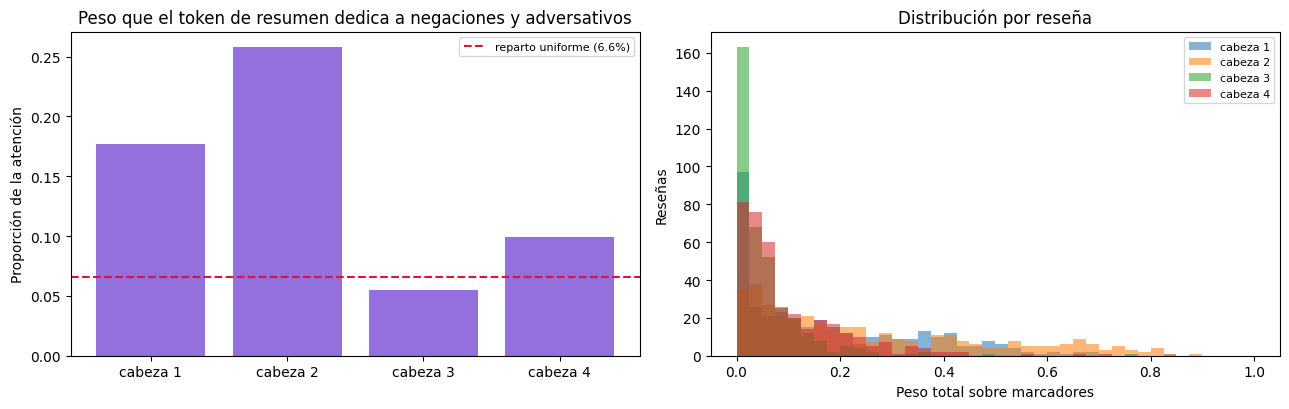

Reseñas analizadas con al menos un marcador: 367 de 600
Proporción media de tokens que son marcadores: 6.58%

Peso medio sobre marcadores por cabeza:
  cabeza 1: 17.69%  (x2.69 respecto al reparto uniforme)
  cabeza 2: 25.78%  (x3.92 respecto al reparto uniforme)
  cabeza 3: 5.52%  (x0.84 respecto al reparto uniforme)
  cabeza 4: 9.91%  (x1.51 respecto al reparto uniforme)


In [47]:
MUESTRA_ATENCION = 600
MARCADORES_ATENCION = {'no', 'nunca', 'pero', 'sin', 'aunque', 'tampoco', 'nada', 'ni'}
MARCA_INICIO = 'Ġ'  # el tokenizador señala el comienzo de palabra con este símbolo


def es_marcador(pieza):
    # Exijo que la pieza empiece palabra: de lo contrario contaría el 'no' interior de 'bono'.
    return pieza.startswith(MARCA_INICIO) and pieza[1:].lower() in MARCADORES_ATENCION


@torch.no_grad()
def peso_sobre_marcadores(textos, modelo=None, bloque=-1):
    modelo = modelo or modelo_atencion
    modelo.eval().to(DEVICE)
    ids, mascara = codificar(textos)

    pesos_marcadores, proporciones = [], []
    for inicio in range(0, len(textos), BATCH):
        lote_ids = ids[inicio:inicio + BATCH]
        lote_mascara = mascara[inicio:inicio + BATCH]
        _, pesos = modelo(lote_ids.to(DEVICE), lote_mascara.to(DEVICE))
        # Fila del token de resumen: de dónde toma la información el vector que clasifica.
        fila_resumen = pesos[bloque][:, :, 0, :].float().cpu().numpy()

        for j in range(lote_ids.shape[0]):
            largo = int(lote_mascara[j].sum())
            piezas = tokenizador.convert_ids_to_tokens(lote_ids[j, :largo].tolist())
            marcadores = np.array([es_marcador(p) for p in piezas])
            marcadores[0] = False
            if not marcadores.any():
                continue
            pesos_marcadores.append(fila_resumen[j, :, :largo][:, marcadores].sum(axis=1))
            # El token de resumen no cuenta como palabra del texto.
            proporciones.append(marcadores.sum() / (largo - 1))

    return np.array(pesos_marcadores), np.array(proporciones)


muestra = val_df['text'].head(MUESTRA_ATENCION).tolist()
pesos_marcadores, proporcion_marcadores = peso_sobre_marcadores(muestra)

media_por_cabeza = pesos_marcadores.mean(axis=0)
esperado = proporcion_marcadores.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

posiciones = np.arange(len(media_por_cabeza))
axes[0].bar(posiciones, media_por_cabeza, color='mediumpurple')
axes[0].axhline(esperado, color='crimson', linestyle='--',
                label=f'reparto uniforme ({esperado:.1%})')
axes[0].set_xticks(posiciones, [f'cabeza {i + 1}' for i in posiciones])
axes[0].set_title('Peso que el token de resumen dedica a negaciones y adversativos')
axes[0].set_ylabel('Proporción de la atención')
axes[0].legend(fontsize=8)

for cabeza in posiciones:
    axes[1].hist(pesos_marcadores[:, cabeza], bins=40, range=(0, 1), alpha=0.55,
                 label=f'cabeza {cabeza + 1}')
axes[1].set_title('Distribución por reseña')
axes[1].set_xlabel('Peso total sobre marcadores')
axes[1].set_ylabel('Reseñas')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Reseñas analizadas con al menos un marcador: {len(pesos_marcadores)} de {len(muestra)}')
print(f'Proporción media de tokens que son marcadores: {esperado:.2%}')
print('\nPeso medio sobre marcadores por cabeza:')
for cabeza, valor in enumerate(media_por_cabeza):
    print(f'  cabeza {cabeza + 1}: {valor:.2%}  (x{valor / esperado:.2f} respecto al reparto uniforme)')

### Tres cabezas de cuatro se especializan en los marcadores

Los dos ejemplos anteriores podrían ser casualidad, así que lo medimos sobre **367 reseñas de validación** que contienen algún marcador a comienzo de palabra.

Las negaciones y adversativos son el **6,58% de los tokens**, que es la proporción que les correspondería con un reparto uniforme. Lo que reciben es:

| Cabeza | Peso sobre marcadores | Respecto al reparto uniforme |
|---|---:|---:|
| 1 | 17,69% | x2,69 |
| 2 | **25,78%** | **x3,92** |
| 3 | 5,52% | x0,84 |
| 4 | 9,91% | x1,51 |

**Tres de las cuatro cabezas los sobreponderan**, con factores entre 1,5 y 3,9. La segunda les dedica casi cuatro veces el peso que les tocaría, más de la cuarta parte de toda su atención. La tercera se queda ligeramente por debajo del reparto uniforme, lo que coincide con lo visto en los ejemplos: es la que atiende al sujeto y al verbo.

Nadie indicó al modelo que esas palabras fueran importantes: recibió identificadores numéricos sin significado y una etiqueta de una a cinco estrellas, y **tres de sus cuatro cabezas acabaron apoyándose en la negación y el adversativo**. Son las mismas palabras que el análisis exploratorio había señalado como estructurales en este corpus.

El histograma matiza el promedio: la distribución está **muy sesgada hacia la izquierda**, con la mayoría de reseñas por debajo del 20% y una cola que llega al 80%. El peso alto no es constante, **se concentra en las reseñas donde esas palabras deciden el sentido**.

Esta especialización es el mecanismo detrás de los 0,0120 de kappa que la escalera atribuye a que la mezcla se aprenda. Es una ganancia pequeña, y la razón se ve en los dos ejemplos anteriores: encontrar el marcador resuelve el caso en que la negación y el adjetivo apuntan al mismo lado, y no resuelve el caso en que la negación es descriptiva.


---
## 23. Predicción sobre reseñas nuevas

Probamos el modelo con textos escritos por nosotros, incluyendo tres casos difíciles: una reseña mixta, una irónica y una donde la impresión inicial se invierte al final.

Miramos la distribución completa de probabilidad y no solo la clase predicha: no es lo mismo predecir cuatro estrellas con el 90% que repartir entre tres y cuatro.

In [48]:
@torch.no_grad()
def predecir_resena(texto, modelo=None, nombre=None):
    modelo = modelo or modelo_final
    nombre = nombre or MEJOR_MODELO
    modelo.eval().to(DEVICE)

    if nombre == 'MLP sobre TF-IDF':
        vector = tfidf.transform([texto]).astype(np.float32).toarray()
        logits, _ = modelo(torch.from_numpy(vector).to(DEVICE))
    else:
        ids, mascara = codificar([texto])
        logits, _ = modelo(ids.to(DEVICE), mascara.to(DEVICE))

    probs = torch.softmax(logits.float(), dim=1)[0].cpu().numpy()
    return {
        'estrellas': int(np.argmax(probs)) + 1,
        'confianza': float(probs.max()),
        'distribucion': {int(c): float(p) for c, p in zip(CLASES, probs)},
    }


PRUEBAS = [
    'Excelente calidad, llegó antes de lo previsto y funciona perfectamente.',
    'Se rompió a los tres días y el servicio de atención no responde. Una estafa.',
    'Cumple su función, nada del otro mundo pero por el precio está bien.',
    'El diseño es precioso y los materiales parecen buenos, pero no funciona.',
    'Maravilloso, si te gusta que te cobren cuarenta euros por un trozo de plástico.',
    'Lo compré con dudas y al final me ha sorprendido para bien.',
]

for texto in PRUEBAS:
    r = predecir_resena(texto)
    barra = ' '.join(f'{c}:{p:.0%}' for c, p in r['distribucion'].items())
    print(f"{r['estrellas']} estrellas (conf. {r['confianza']:.0%})  [{barra}]")
    print(f'   {texto}\n')

5 estrellas (conf. 82%)  [1:0% 2:0% 3:0% 4:17% 5:82%]
   Excelente calidad, llegó antes de lo previsto y funciona perfectamente.

1 estrellas (conf. 95%)  [1:95% 2:4% 3:0% 4:0% 5:0%]
   Se rompió a los tres días y el servicio de atención no responde. Una estafa.

4 estrellas (conf. 47%)  [1:0% 2:3% 3:46% 4:47% 5:4%]
   Cumple su función, nada del otro mundo pero por el precio está bien.

2 estrellas (conf. 39%)  [1:23% 2:39% 3:25% 4:9% 5:4%]
   El diseño es precioso y los materiales parecen buenos, pero no funciona.

3 estrellas (conf. 39%)  [1:9% 2:28% 3:39% 4:19% 5:6%]
   Maravilloso, si te gusta que te cobren cuarenta euros por un trozo de plástico.

5 estrellas (conf. 46%)  [1:0% 2:1% 3:10% 4:43% 5:46%]
   Lo compré con dudas y al final me ha sorprendido para bien.



### Comportamiento ante textos nuevos

La **distribución de probabilidad resulta más informativa que la predicción**.

Los dos casos claros se resuelven con seguridad: la reseña entusiasta obtiene 5 estrellas con un 82% y la indignada 1 estrella con un 95%, sin repartir nada fuera de su lado de la escala. El caso tibio queda en 4 estrellas con un 47%, pero con un 46% en 3: **el modelo no elige, empata**, y la salida comunica esa duda mejor que la etiqueta.

Los tres casos difíciles marcan el límite:

- *"El diseño es precioso y los materiales parecen buenos, pero no funciona"* se clasifica como **2 estrellas con un 39%**, con un 62% de la probabilidad en una o dos. **Resuelve la contradicción hacia el lado correcto**, y es el caso que mejor ilustra el valor de leer la reseña como secuencia: las palabras positivas son mayoría y la predicción es negativa.
- La reseña irónica cae en 3 estrellas con un 39%, aunque deja un 37% repartido entre una y dos. **La ironía no se detecta**, pero el reparto se inclina hacia abajo: algo en *"que te cobren cuarenta euros por un trozo de plástico"* se registra, aunque no baste para invertir la lectura de *"maravilloso"*.
- *"Lo compré con dudas y al final me ha sorprendido para bien"* obtiene 5 estrellas con un 46%, seguido de cerca por 4 con un 43%. Acierta, pero la mención inicial de las dudas le resta seguridad.

El patrón de calibración es consistente con lo visto en prueba: **los casos que resuelve con claridad llevan entre el 82% y el 95% de confianza, y los que le cuestan se quedan entre el 39% y el 47%**. La probabilidad de salida es utilizable como filtro para derivar a revisión humana.


---
## 24. Guardado de los artefactos

Para reutilizar un modelo sin reentrenarlo hacen falta, además de los pesos, el tokenizador entrenado, la longitud de corte y la configuración de **ese** modelo en concreto. Guardar los pesos de la red recurrente junto a la configuración del Transformer produciría un fichero imposible de cargar, así que la descripción se deriva del propio codificador que se escribe.

Guardamos dos modelos: el final, que responde en la demo, y el Transformer base, que aporta los mapas de atención.


In [49]:
DIRECTORIO = Path('artefactos_transformer')
DIRECTORIO.mkdir(exist_ok=True)


def describir(nombre):
    # La configuración guardada debe ser la del modelo cuyos pesos se escriben, no la de la
    # arquitectura de referencia: sin esto los pesos no se pueden volver a cargar.
    codificador = modelos[nombre].codificador
    descripcion = {'modelo': nombre,
                   'codificador': type(codificador).__name__,
                   'dim_salida': codificador.dim_salida,
                   'dim_modelo': DIM_MODELO}
    if isinstance(codificador, CodificadorTransformer):
        descripcion.update({'num_cabezas': CABEZAS, 'num_bloques': len(codificador.bloques),
                            'dim_ffn': DIM_FFN, 'resumen': codificador.resumen,
                            'tipo_posicion': type(codificador.embedding.posicion).__name__})
        if len(codificador.bloques) > 0:
            descripcion['mezcla'] = codificador.bloques[0].atencion.mezcla
    elif isinstance(codificador, CodificadorGRU):
        descripcion.update({'dim_oculta': codificador.rnn.hidden_size,
                            'bidireccional': codificador.rnn.bidirectional})
    return descripcion


ARTEFACTOS = [('modelo_final.pt', MEJOR_MODELO, metricas_test),
              ('transformer_atencion.pt', 'Transformer base', None)]

componentes = []
for archivo, nombre, metricas in ARTEFACTOS:
    torch.save(modelos[nombre].state_dict(), DIRECTORIO / archivo)
    componente = {'archivo': archivo, **describir(nombre)}
    if metricas is not None:
        componente['metricas_prueba'] = {k: float(v) for k, v in metricas.items()
                                         if isinstance(v, (int, float))}
    componentes.append(componente)

tokenizador.save_pretrained(DIRECTORIO / 'tokenizador')

metadatos = {
    'max_len': MAX_LEN,
    'pad_idx': PAD_IDX,
    'cls_idx': CLS_IDX,
    'clases': [int(c) for c in CLASES],
    'tam_vocabulario': len(tokenizador),
    'modelo_final': MEJOR_MODELO,
    'mejor_transformer': MEJOR_TRANSFORMER,
    'metricas_prueba_transformer': {k: float(v) for k, v in metricas_test_transformer.items()
                                    if isinstance(v, (int, float))},
    'componentes': componentes,
}

with open(DIRECTORIO / 'metadatos.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print('Artefactos guardados en:', DIRECTORIO.resolve())
for archivo in sorted(DIRECTORIO.rglob('*')):
    if archivo.is_file():
        print(f'  {archivo.relative_to(DIRECTORIO)}  ({archivo.stat().st_size / 1e6:.1f} MB)')


Artefactos guardados en: /content/artefactos_transformer
  metadatos.json  (0.0 MB)
  modelo_final.pt  (8.6 MB)
  tokenizador/tokenizer.json  (1.1 MB)
  tokenizador/tokenizer_config.json  (0.0 MB)
  transformer_atencion.pt  (9.8 MB)


---
## 25. Demo interactiva

Una interfaz donde escribir una reseña y ver la calificación estimada, el reparto de probabilidad entre las cinco clases y las palabras en las que se apoyó la atención para decidir.

En Colab el servidor corre en la máquina virtual, que no es accesible desde el navegador, así que se genera además un enlace público temporal. La celda siguiente cierra el servidor.

In [53]:
import gradio as gr


def analizar(texto):
    if not texto or not texto.strip():
        return {}, 'Escribe una reseña para analizarla.'

    resultado = predecir_resena(texto)
    distribucion = {f'{c} estrellas': p for c, p in resultado['distribucion'].items()}

    # La atención pertenece al Transformer base, no al modelo que produce la distribución:
    # muestro también su predicción para no atribuirle a uno las razones del otro.
    tokens, mapas, probs = analizar_atencion(texto)
    promedio = mapas[-1][:, 0, :].mean(axis=0)
    relevantes = sorted(zip(tokens[1:], promedio[1:]), key=lambda par: par[1], reverse=True)[:6]

    detalle = (f'El Transformer base predice {int(np.argmax(probs)) + 1} estrellas '
               f'({probs.max():.0%}) y su atención se apoya en: '
               + ', '.join(f'{t} ({p:.0%})' for t, p in relevantes))

    return distribucion, detalle


demo = gr.Interface(
    fn=analizar,
    inputs=gr.Textbox(lines=4, label='Reseña', placeholder='Escribe aquí una reseña en español...'),
    outputs=[gr.Label(num_top_classes=5, label=f'Calificación estimada por el modelo final ({MEJOR_MODELO})'),
             gr.Textbox(label='Lectura del Transformer base')],
    title='Estimador de calificación de reseñas en español',
    description='El modelo final estima las estrellas; el Transformer base, que sí tiene atención, '
                'muestra en qué palabras se apoya para decidir.',
    examples=[[t] for t in PRUEBAS[:4]],
    flagging_mode='never',
)

# En Colab el servidor local no es accesible desde el navegador: share genera un enlace público.
demo.launch(share=IN_COLAB, inline=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ae41a0b013ce28e42d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [54]:
demo.close()

Closing server running on port: 7860


---
## 26. Resultados y conclusiones

In [52]:
print('=' * 78)
print('BALANCE DEL EXPERIMENTO')
print('=' * 78)

print(f'\nCorpus: {len(train_df)} reseñas de entrenamiento, {len(val_df)} de validación, '
      f'{len(test_df)} de prueba')
print(f'Corpus completo para la curva de datos: {len(train_completo_df)} reseñas')
print(f'Vocabulario subword: {len(tokenizador)} entradas | Longitud de corte: {MAX_LEN} tokens')
print(f'Transformer de referencia: {DIM_MODELO} dimensiones, {CABEZAS} cabezas, '
      f'{BLOQUES} bloques, red densa interna de {DIM_FFN}')
print(f'Receta común: lr {LR} con calentamiento del {PROPORCION_CALENTAMIENTO:.0%}, '
      f'dropout {DROPOUT}, recorte {RECORTE_GRADIENTE}, tope de {MAX_EPOCAS} épocas')
print(f'Criterio de parada y de punto de control: {MONITOR} con paciencia de {PACIENCIA}')
print(f'Margen de error del acierto en validación: ±{margen_val:.4f}')

print('\nDesempeño en validación:')
print(tabla[['modelo', 'f1_macro', 'mae_estrellas', 'qwk', 'corpus', 'épocas']]
      .round(4).to_string(index=False))

print('\nAporte de cada pieza del bloque (todos con resumen por promedio):')
print(tabla[tabla['modelo'].isin(ESCALERA)][['modelo', 'f1_macro', 'mae_estrellas', 'qwk', 'épocas']]
      .round(4).to_string(index=False))

print('\nResultado en prueba:')
print(comparacion_prueba.round(4).to_string(index=False))

print(f'\nDistribución del error en prueba del modelo final ({MEJOR_MODELO}):')
print(f'   acierto exacto           {exactos:.1%}')
print(f'   dentro de una estrella   {vecinos:.1%}')
print(f'   desviación de 2 o más    {graves:.1%}')
print(f'   sesgo medio              {error_con_signo.mean():+.3f} estrellas')


BALANCE DEL EXPERIMENTO

Corpus: 50000 reseñas de entrenamiento, 4995 de validación, 4994 de prueba
Corpus completo para la curva de datos: 198147 reseñas
Vocabulario subword: 16000 entradas | Longitud de corte: 86 tokens
Transformer de referencia: 128 dimensiones, 4 cabezas, 2 bloques, red densa interna de 512
Receta común: lr 0.0003 con calentamiento del 10%, dropout 0.1, recorte 1.0, tope de 30 épocas
Criterio de parada y de punto de control: val_qwk con paciencia de 4
Margen de error del acierto en validación: ±0.0139

Desempeño en validación:
                                   modelo  f1_macro  mae_estrellas    qwk  corpus  épocas
                    GRU (corpus completo)    0.5237         0.5758 0.7955  198147    12.0
                         MLP sobre TF-IDF    0.5075         0.6078 0.7805   50000     6.0
       Transformer base (corpus completo)    0.5152         0.5968 0.7803  198147     8.0
       Transformer base + pérdida ordinal    0.4930         0.6450 0.7517   50000     

### Conclusiones

**1. Lo que hace útil al bloque codificador es que las posiciones se miren entre sí.**

| Peldaño | QWK | Cambio |
|---|---:|---:|
| Sin bloques | 0,7347 | — |
| Bloque sin mezcla entre posiciones | 0,6975 | **−0,0372** |
| Bloque con mezcla uniforme | 0,7336 | **+0,0361** |
| Bloque con atención | 0,7456 | **+0,0120** |

Un bloque que transforma cada posición por separado, con red densa, normalizaciones y residuales, **rinde peor que no tener bloque**. En cuanto se permite mezclar entre posiciones se recupera lo perdido, y que esa mezcla se aprenda añade otros 0,0120. Comparar solo contra cero bloques habría dado +0,0109 y escondido dos efectos grandes de signo opuesto.

Con una salvedad que ya señalamos: el segundo peldaño carga con un dropout que le borra posiciones enteras y con dos proyecciones que colapsan en una sola transformación lineal. Su caída es como mucho la que medimos y probablemente menor, y por tanto la recuperación del tercer peldaño tampoco es exacta. El único tramo que podemos leer al pie de la letra es el último.

**2. La ventaja de la atención sobre una media ciega es pequeña.**

Esos 0,0120 de kappa quedan por debajo del margen de error, así que lo defendible es que la atención **es al menos tan buena** como repartir el peso por igual, no que la supere. Los mapas muestran que la diferencia existe y en qué consiste, pero también por qué es modesta.

**3. La codificación posicional sí tiene efecto, y las residuales menos del esperado.**

Sinusoidal y aprendida son indistinguibles entre sí y las dos superan en 0,0138 a no usar ninguna, coherente con que lo que aporta el bloque sea mirar unas posiciones desde otras. Quitar las residuales cuesta 0,0079: con solo dos bloques el camino del gradiente es corto y el atajo importa menos. El aplanamiento es la única decisión claramente mala, 0,0309 por debajo del token de resumen.

**4. La bolsa de palabras aguanta el régimen pequeño.**

Con 50.000 reseñas el perceptrón sobre TF-IDF llega a 0,7805 y la regresión logística a 0,7509 en **9,4 segundos de CPU**, mientras el Transformer base se queda en 0,7503 con 110 segundos de GPU. Empatar con un modelo lineal que cuesta diez veces menos es el resultado más incómodo del cuaderno.

**5. La pérdida sensible al orden no cambió nada.**

Las tres métricas se mueven menos de dos milésimas. La comparación es limpia —misma semilla, misma arquitectura, mismas épocas— así que el resultado es un no-efecto y no una ambigüedad. Con los errores ya casi todos pegados a la diagonal, una pérdida que castiga los lejanos tiene poco que corregir.

**6. La programación del ritmo apenas se nota a esta escala.**

Las dos variantes con calentamiento quedan empatadas entre sí y por encima del ritmo constante, pero las tres caben en 0,0095. Los entrenamientos terminan antes de que las dos formas de decaimiento lleguen a separarse.

**7. Más datos valen tanto como todo el diseño del bloque junto.**

Cuadruplicar el corpus da +0,0300 de kappa al Transformer y +0,0587 a la GRU, y **el orden entre ambas se invierte**. Esos 0,0300 equivalen a la distancia entera que separa a la mejor de las ocho variantes del Transformer de la peor, que son 0,0309. Con el corpus completo el Transformer alcanza al perceptrón sobre TF-IDF, 0,7803 frente a 0,7805.

**8. En prueba las dos arquitecturas empatan.**

La GRU obtiene 0,7986 de kappa y el Transformer 0,8008, con el Transformer por delante también en acierto, F1 y MAE. Como todas las diferencias son menores que el margen de error, la conclusión no es que una gane, sino que **cuál queda arriba depende de sobre qué reseñas se mida**. Mantuvimos la GRU como modelo final porque cambiarla habría significado seleccionar con la partición de prueba.

**9. La atención mira donde debe, y eso explica su ganancia modesta.**

Sin recibir indicación alguna, tres de las cuatro cabezas sobreponderan negaciones y adversativos entre **1,5 y 3,9 veces**. Ante *"parecía muy bueno y bonito pero no funciona nada bien"*, el adversativo `pero` es la palabra más atendida con un 24% y el modelo acierta el lado. Ante *"No lleva conexión para el mando de la ps4"* —cuatro estrellas reales— localiza igual de bien la construcción negada y predice dos. **Encuentra el marcador; no evalúa sobre qué recae.**

**10. El tokenizador subword resolvió el vocabulario con un coste medible.**

Con 16.000 entradas frente a 19.551 no deja fuera **ninguna** palabra, frente al 1,6% que pierde el vocabulario por palabras. El precio es que el percentil 95 de longitud sube de 73 a 85 tokens, un 16% más, y en un mecanismo cuadrático eso son un 36% más de operaciones.

**11. Parte del techo viene de los datos.**

Los cuatro errores graves más confiados están **todos calificados con tres estrellas**, y dos apuntan a cada extremo de la escala. La auditoría había encontrado cientos de textos idénticos con más de una calificación. Ningún clasificador puede acertar en ambos.

**12. El modelo final es más útil de lo que sugiere su acierto exacto.**

Un 53,6% suena mediocre, pero el **92,0% de las predicciones cae a menos de una estrella del valor real**, las confusiones entre extremos son del 1% y el sesgo medio es de −0,034 estrellas. La confianza discrimina —0,610 en aciertos frente a 0,514 en errores— y se queda entre el 39% y el 47% en los casos difíciles, lo que permite usarla como filtro de revisión humana.

**13. Lo que este experimento no puede afirmar.**

Cada cifra proviene de **una sola semilla**, con un margen de error del acierto de ±0,0139. Las diferencias por debajo de ese umbral —entre el Transformer y la GRU, entre la atención y la mezcla uniforme, entre las dos codificaciones posicionales, entre las programaciones del ritmo, entre las dos pérdidas— **no deben leerse como reales**. Buena parte de lo que ordena nuestra tabla cae en ese rango.

A eso se suman cuatro detalles del montaje que fuimos anotando sobre la marcha: el dropout no afecta igual a los pesos de atención que a los pesos fijos de los controles; en los controles las proyecciones de consulta y clave no aprenden; la variante con posición aprendida lleva once mil parámetros que las demás no tienen; y el tokenizador se estimó sobre el muestreo pequeño aunque también se use en el régimen completo.

**14. Qué haríamos distinto con más tiempo.**

Repetir cada experimento con **varias semillas**, que es lo que más falta hace. Rehacer el peldaño sin mezcla con el dropout desactivado sobre los pesos fijos, para separar el efecto del mecanismo del efecto de la regularización. Entrenar todas las variantes también con el **corpus completo**, ya que ahí es donde las diferencias tuvieron ocasión de aparecer. Y añadir un peldaño más a la escalera, un bloque con atención pero **sin red densa por posición**, que cerraría la descomposición por el otro extremo.


### Las hipótesis de partida

De las tres que planteamos al principio, **se cumplió una**.

| Hipótesis | Resultado |
|---|---|
| La atención será la pieza que más aporte dentro del bloque | **No.** Mezclar entre posiciones vale 0,0361 de kappa; que la mezcla se aprenda, 0,0120 |
| El Transformer será el que más gane al aumentar el corpus | **No.** Ganó 0,0300 frente a los 0,0587 de la GRU |
| Las clases intermedias serán más difíciles que los extremos | **Sí.** Unos veinte puntos de F1 separan los extremos del centro |

Las dos primeras nos parecen la parte más instructiva del trabajo. Dábamos por hecho que la atención era el motor del bloque y que su falta de sesgos inductivos la haría escalar mejor con los datos, y en ninguno de los dos casos los números nos acompañaron. Lo que los hizo visibles fue el diseño de controles: sin la escalera habríamos atribuido a la atención todo lo que aporta el bloque, y sin el segundo régimen de entrenamiento no habríamos visto que el orden entre arquitecturas depende del volumen de datos.

De la primera conviene no sacar más de lo que da. Los 0,0361 salen de comparar con un peldaño que arrastra dos penalizaciones nuestras, así que lo que podemos afirmar con seguridad es que **la atención no fue la pieza decisiva**, no la cifra exacta de cuánto la superó mezclar por igual. Habría hecho falta un control mejor igualado para cuantificarlo.
